## Batch 0: Setup, inventory snapshot, helper import

This batch initializes Notebook 21 for Stable Diffusion restoration.

It validates:

- project root discovery
- refreshed inventory availability
- Stable Diffusion helper import
- prompt-aware helper API availability
- Notebook 21 output folder structure

It writes:

- inventory snapshot
- Batch 0 validation table
- initial stage manifest

No Stable Diffusion model is loaded in this batch.

In [1]:
from __future__ import annotations

import json
import os
import sys
from dataclasses import asdict
from datetime import datetime, timezone
from pathlib import Path

import numpy as np
import pandas as pd

pd.set_option("display.max_columns", 160)
pd.set_option("display.max_colwidth", 180)

NOTEBOOK_ID = "21_stable_diffusion_restoration"
NOTEBOOK_NAME = "21_stable_diffusion_restoration.ipynb"

def find_project_root(start: Path | None = None) -> Path:
    current = (start or Path.cwd()).resolve()
    for candidate in [current, *current.parents]:
        if (candidate / "tools" / "build_project_inventory.py").is_file() and (candidate / "src").is_dir():
            return candidate
    raise RuntimeError("Could not find project root containing tools/build_project_inventory.py and src/.")

PROJECT_ROOT = find_project_root()
if str(PROJECT_ROOT / "src") not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT / "src"))

os.chdir(PROJECT_ROOT)

OUTPUT_ROOT = PROJECT_ROOT / "outputs" / NOTEBOOK_ID
INVENTORY_DIR = OUTPUT_ROOT / "inventory"
TABLES_DIR = OUTPUT_ROOT / "tables"
VALIDATION_DIR = OUTPUT_ROOT / "validation"
MANIFESTS_DIR = OUTPUT_ROOT / "manifests"
FIGURES_DIR = OUTPUT_ROOT / "figures"
REPORTS_DIR = OUTPUT_ROOT / "reports"
RESTORED_ROOT_DIR = OUTPUT_ROOT / "restored"

for directory in [
    OUTPUT_ROOT,
    INVENTORY_DIR,
    TABLES_DIR,
    VALIDATION_DIR,
    MANIFESTS_DIR,
    FIGURES_DIR,
    REPORTS_DIR,
    RESTORED_ROOT_DIR,
]:
    directory.mkdir(parents=True, exist_ok=True)

PROJECT_INVENTORY_PATH = PROJECT_ROOT / "outputs" / "inventory" / "project_file_inventory.csv"
PROJECT_INVENTORY_MANIFEST_PATH = PROJECT_ROOT / "outputs" / "inventory" / "project_file_inventory_manifest.json"

BATCH0_INVENTORY_SNAPSHOT_OUTPUT_PATH = INVENTORY_DIR / "batch0_project_inventory_snapshot.csv"
BATCH0_VALIDATION_OUTPUT_PATH = VALIDATION_DIR / "batch0_validation.csv"
STAGE_MANIFEST_JSON_PATH = MANIFESTS_DIR / "stable_diffusion_stage_manifest.json"

print("Project root:", PROJECT_ROOT)
print("Notebook output root:", OUTPUT_ROOT.relative_to(PROJECT_ROOT))
print("Project inventory:", PROJECT_INVENTORY_PATH.relative_to(PROJECT_ROOT))

Project root: D:\Masters\FH\Thesis\painting-restoration-eval
Notebook output root: outputs\21_stable_diffusion_restoration
Project inventory: outputs\inventory\project_file_inventory.csv


In [2]:
import importlib

import restoration_eval.restoration_stable_diffusion as sd_helper

sd_helper = importlib.reload(sd_helper)

from restoration_eval.restoration_stable_diffusion import (
    DEFAULT_GENERIC_PROMPT,
    DEFAULT_NEGATIVE_PROMPT,
    DEFAULT_PROMPT_POLICY_ID,
    DEFAULT_PROMPT_VARIANT_SPECS,
    DEFAULT_MASK_BINARY_THRESHOLD,
    RESTORATION_GENERATOR_VERSION,
    StableDiffusionInpaintConfig,
    build_stable_diffusion_candidate_manifest,
    build_stable_diffusion_prompt_policy_df,
    run_stable_diffusion_candidates,
    select_prompt_ablation_subset,
    standardize_stable_diffusion_source_cases,
    summarize_stable_diffusion_restoration_metadata,
    validate_stable_diffusion_restoration_outputs,
)

SD_CONFIG = StableDiffusionInpaintConfig(
    model_revision="main",
    base_seed=2026,
    scheduler_name="pipeline_default",
    num_inference_steps=30,
    guidance_scale=7.5,
    strength=1.0,
    inference_size=512,
    precision="float16",
    prefer_cuda=True,
    max_retries=1,
    retry_delay_seconds=2.0,
    zero_control_behavior="copy_without_inference",
    mask_binary_threshold=128,
    preserve_unmasked_pixels=True,
    restored_filename_hash_length=10,
    restored_filename_max_stem_length=120,
)

GENERIC_PROMPT_VARIANT_ID = getattr(sd_helper, "GENERIC_PROMPT_VARIANT_ID", "p00_generic")
EXPECTED_SD_HELPER_VERSION = "4.2_soft_mask_nonzero_fallback"

if RESTORATION_GENERATOR_VERSION != EXPECTED_SD_HELPER_VERSION:
    raise RuntimeError(
        f"Wrong Stable Diffusion helper loaded: {RESTORATION_GENERATOR_VERSION}. "
        f"Expected {EXPECTED_SD_HELPER_VERSION}. Restart the kernel and make sure "
        "src/restoration_eval/restoration_stable_diffusion.py is the v4.2 helper."
    )

prompt_policy_preview_df = build_stable_diffusion_prompt_policy_df(config=SD_CONFIG)
GENERIC_PROMPT_VARIANT_ID = getattr(sd_helper, "GENERIC_PROMPT_VARIANT_ID", "p00_generic")

PROMPT_ABLATION_TARGET_SOURCE_CASES = 120
PROMPT_ABLATION_MIN_SOURCE_CASES = 100
PROMPT_ABLATION_RANDOM_STATE = 2026

prompt_policy_preview_df = build_stable_diffusion_prompt_policy_df(config=SD_CONFIG)

print("Prompt policy:", DEFAULT_PROMPT_POLICY_ID)
print("Generic prompt variant:", GENERIC_PROMPT_VARIANT_ID)
print("Prompt-ablation target source cases:", PROMPT_ABLATION_TARGET_SOURCE_CASES)
print("Prompt-ablation minimum source cases:", PROMPT_ABLATION_MIN_SOURCE_CASES)
print("Prompt-ablation random state:", PROMPT_ABLATION_RANDOM_STATE)

display(prompt_policy_preview_df[
    [
        "prompt_policy_id",
        "prompt_variant_id",
        "variant_order",
        "prompt_template_name",
        "applies_to_all_cases",
        "requires_metadata",
    ]
])

print("Helper version:", RESTORATION_GENERATOR_VERSION)
print("Prompt policy:", DEFAULT_PROMPT_POLICY_ID)
print("Prompt variants:", len(prompt_policy_preview_df))
print("Generic prompt variant:", "p00_generic")
print("Mask binary threshold:", SD_CONFIG.mask_binary_threshold)
print("Preserve unmasked pixels:", SD_CONFIG.preserve_unmasked_pixels)

Prompt policy: sd_inpaint_prompt_ablation_v1
Generic prompt variant: p00_generic
Prompt-ablation target source cases: 120
Prompt-ablation minimum source cases: 100
Prompt-ablation random state: 2026


,prompt_policy_id,prompt_variant_id,variant_order,prompt_template_name,applies_to_all_cases,requires_metadata
0,sd_inpaint_prompt_ablation_v1,p00_generic,0,generic_restoration,True,False
1,sd_inpaint_prompt_ablation_v1,p01_style_period,1,style_period_context,False,True
2,sd_inpaint_prompt_ablation_v1,p02_artist,2,artist_context,False,True
3,sd_inpaint_prompt_ablation_v1,p03_artist_style_period,3,artist_style_period_context,False,True
4,sd_inpaint_prompt_ablation_v1,p04_full_context,4,artwork_full_context,False,True


Helper version: 4.2_soft_mask_nonzero_fallback
Prompt policy: sd_inpaint_prompt_ablation_v1
Prompt variants: 5
Generic prompt variant: p00_generic
Mask binary threshold: 128
Preserve unmasked pixels: True


In [3]:
def utc_now_iso() -> str:
    return datetime.now(timezone.utc).isoformat()


def project_relative_path(path: str | Path | None) -> str:
    if path is None:
        return ""
    path = Path(path)
    try:
        return path.resolve().relative_to(PROJECT_ROOT.resolve()).as_posix()
    except ValueError:
        return path.as_posix()


def read_json(path: str | Path) -> dict:
    path = Path(path)
    with path.open("r", encoding="utf-8") as handle:
        return json.load(handle)


def save_json(path: str | Path, payload: dict) -> None:
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    with path.open("w", encoding="utf-8") as handle:
        json.dump(payload, handle, indent=2, ensure_ascii=False)


def json_for_csv(value):
    if isinstance(value, (dict, list, tuple)):
        return json.dumps(value, ensure_ascii=False, sort_keys=True)
    if isinstance(value, Path):
        return project_relative_path(value)
    if pd.isna(value) if isinstance(value, float) else False:
        return ""
    return value


def build_check(
    check_name: str,
    observed,
    expected,
    passed: bool,
    failure_message: str = "",
) -> dict:
    return {
        "check_name": check_name,
        "observed": observed,
        "expected": expected,
        "passed": bool(passed),
        "failure_message": "" if passed else failure_message,
    }


def file_sha256(path: str | Path, chunk_size: int = 1024 * 1024) -> str:
    import hashlib

    path = Path(path)
    digest = hashlib.sha256()
    with path.open("rb") as handle:
        while True:
            block = handle.read(chunk_size)
            if not block:
                break
            digest.update(block)
    return digest.hexdigest()


def dataframe_has_columns(df: pd.DataFrame, columns: list[str]) -> bool:
    return all(column in df.columns for column in columns)

In [4]:
if not PROJECT_INVENTORY_PATH.is_file():
    raise FileNotFoundError(
        "Project inventory not found. Run first from the project root:\n"
        "python ./tools/build_project_inventory.py --root . --out-dir ./outputs/inventory"
    )

project_inventory_df = pd.read_csv(PROJECT_INVENTORY_PATH)

required_inventory_columns = [
    "relative_path",
    "file_type",
    "size_bytes",
    "modified_at_utc",
]

batch0_inventory_checks = [
    build_check(
        "batch0_inventory_file_exists",
        project_relative_path(PROJECT_INVENTORY_PATH),
        "existing CSV",
        PROJECT_INVENTORY_PATH.is_file(),
        "Project inventory CSV is missing.",
    ),
    build_check(
        "batch0_inventory_has_rows",
        len(project_inventory_df),
        "> 0",
        len(project_inventory_df) > 0,
        "Project inventory is empty.",
    ),
    build_check(
        "batch0_inventory_has_required_columns",
        list(project_inventory_df.columns),
        required_inventory_columns,
        dataframe_has_columns(project_inventory_df, required_inventory_columns),
        "Project inventory is missing required columns.",
    ),
    build_check(
        "batch0_helper_file_present_in_inventory",
        "src/restoration_eval/restoration_stable_diffusion.py",
        "present",
        (
            "relative_path" in project_inventory_df.columns
            and project_inventory_df["relative_path"].astype(str).eq(
                "src/restoration_eval/restoration_stable_diffusion.py"
            ).any()
        ),
        "Stable Diffusion helper is not present in the current inventory. Refresh inventory.",
    ),
]

inventory_snapshot_columns = [
    column
    for column in [
        "relative_path",
        "file_type",
        "notebook_id",
        "model",
        "metric_family",
        "rows",
        "columns",
        "size_bytes",
        "modified_at_utc",
        "sha256",
    ]
    if column in project_inventory_df.columns
]

batch0_inventory_snapshot_df = project_inventory_df[inventory_snapshot_columns].copy()
batch0_inventory_snapshot_df.to_csv(BATCH0_INVENTORY_SNAPSHOT_OUTPUT_PATH, index=False)

display(batch0_inventory_snapshot_df.head(30))
print("Inventory snapshot rows:", len(batch0_inventory_snapshot_df))
print("Saved:", project_relative_path(BATCH0_INVENTORY_SNAPSHOT_OUTPUT_PATH))

,relative_path,size_bytes
0,.gitattributes,60
1,.gitignore,643
2,config/experiment_50_config.yaml,7111
3,config/pilot_config.yaml,677
4,data/model_audit/model_candidates.csv,5383
5,data/processed/clean/p001_clean.png,723881
6,data/processed/clean/p002_clean.png,339472
7,data/processed/clean/p003_clean.png,648764
8,data/processed/clean/p004_clean.png,709746
9,data/processed/clean/p005_clean.png,745221


Inventory snapshot rows: 3099
Saved: outputs/21_stable_diffusion_restoration/inventory/batch0_project_inventory_snapshot.csv


In [5]:
# Batch 0 validation checks
# Normalizes project inventory schema before checking helper/API readiness.

project_inventory_validation_df = project_inventory_df.copy()

if "file_type" not in project_inventory_validation_df.columns and "file_kind" in project_inventory_validation_df.columns:
    project_inventory_validation_df["file_type"] = project_inventory_validation_df["file_kind"]

if "modified_at_utc" not in project_inventory_validation_df.columns and "last_modified_iso" in project_inventory_validation_df.columns:
    project_inventory_validation_df["modified_at_utc"] = project_inventory_validation_df["last_modified_iso"]

# Keep the normalized version available for later cells too.
project_inventory_df = project_inventory_validation_df.copy()

required_inventory_columns = [
    "relative_path",
    "file_type",
    "size_bytes",
    "modified_at_utc",
]

batch0_inventory_checks = [
    build_check(
        "batch0_inventory_has_required_columns",
        list(project_inventory_df.columns),
        required_inventory_columns,
        set(required_inventory_columns).issubset(project_inventory_df.columns),
        "Project inventory is missing required columns.",
    ),
    build_check(
        "batch0_inventory_has_rows",
        len(project_inventory_df),
        "> 0",
        len(project_inventory_df) > 0,
        "Project inventory is empty.",
    ),
    build_check(
        "batch0_inventory_has_csv_entries",
        int((project_inventory_df["file_type"].astype(str).str.lower() == "csv").sum()),
        "> 0",
        int((project_inventory_df["file_type"].astype(str).str.lower() == "csv").sum()) > 0,
        "Project inventory has no CSV entries.",
    ),
]

# Backfill prompt-policy columns if an older helper version is still cached in the kernel.
prompt_policy_preview_df = prompt_policy_preview_df.copy()

if "applies_to_all_cases" not in prompt_policy_preview_df.columns:
    prompt_policy_preview_df["applies_to_all_cases"] = (
        prompt_policy_preview_df.get("is_generic_baseline", False).astype(bool)
    )

if "requires_metadata" not in prompt_policy_preview_df.columns:
    metadata_flag_columns = [
        "uses_artist",
        "uses_style_period",
        "uses_title",
        "uses_category",
    ]
    available_metadata_flag_columns = [
        column for column in metadata_flag_columns
        if column in prompt_policy_preview_df.columns
    ]
    if available_metadata_flag_columns:
        prompt_policy_preview_df["requires_metadata"] = (
            prompt_policy_preview_df[available_metadata_flag_columns]
            .fillna(False)
            .astype(bool)
            .any(axis=1)
        )
    else:
        prompt_policy_preview_df["requires_metadata"] = (
            ~prompt_policy_preview_df["applies_to_all_cases"].astype(bool)
        )

helper_api_checks = [
    build_check(
        "batch0_helper_config_available",
        StableDiffusionInpaintConfig.__name__,
        "StableDiffusionInpaintConfig",
        StableDiffusionInpaintConfig.__name__ == "StableDiffusionInpaintConfig",
        "Stable Diffusion config dataclass could not be imported.",
    ),
    build_check(
        "batch0_prompt_policy_variants_available",
        len(prompt_policy_preview_df),
        ">= 5",
        len(prompt_policy_preview_df) >= 5,
        "Prompt policy has fewer variants than expected.",
    ),
    build_check(
        "batch0_generic_prompt_variant_available",
        prompt_policy_preview_df["prompt_variant_id"].astype(str).tolist(),
        GENERIC_PROMPT_VARIANT_ID,
        GENERIC_PROMPT_VARIANT_ID in set(prompt_policy_preview_df["prompt_variant_id"].astype(str)),
        "Generic prompt variant is missing from prompt policy.",
    ),
    build_check(
        "batch0_contextual_prompt_variants_available",
        int((~prompt_policy_preview_df["applies_to_all_cases"].astype(bool)).sum()),
        ">= 4",
        int((~prompt_policy_preview_df["applies_to_all_cases"].astype(bool)).sum()) >= 4,
        "Contextual prompt-ablation variants are missing.",
    ),
    build_check(
        "batch0_source_standardizer_available",
        callable(standardize_stable_diffusion_source_cases),
        True,
        callable(standardize_stable_diffusion_source_cases),
        "Source-case standardizer is unavailable.",
    ),
    build_check(
        "batch0_prompt_subset_selector_available",
        callable(select_prompt_ablation_subset),
        True,
        callable(select_prompt_ablation_subset),
        "Prompt-ablation subset selector is unavailable.",
    ),
    build_check(
        "batch0_candidate_manifest_builder_available",
        callable(build_stable_diffusion_candidate_manifest),
        True,
        callable(build_stable_diffusion_candidate_manifest),
        "Candidate manifest builder is unavailable.",
    ),
    build_check(
        "batch0_restoration_runner_available",
        callable(run_stable_diffusion_candidates),
        True,
        callable(run_stable_diffusion_candidates),
        "Stable Diffusion candidate runner is unavailable.",
    ),
    build_check(
        "batch0_output_validator_available",
        callable(validate_stable_diffusion_restoration_outputs),
        True,
        callable(validate_stable_diffusion_restoration_outputs),
        "Stable Diffusion output validator is unavailable.",
    ),
]

batch0_validation_df = pd.DataFrame([*batch0_inventory_checks, *helper_api_checks])
display(batch0_validation_df)

batch0_validation_export_df = batch0_validation_df.copy()
for column in ["observed", "expected"]:
    batch0_validation_export_df[column] = batch0_validation_export_df[column].map(json_for_csv)

batch0_validation_export_df.to_csv(BATCH0_VALIDATION_OUTPUT_PATH, index=False)

print("Batch 0 checks passed:", int(batch0_validation_df["passed"].sum()), "/", len(batch0_validation_df))
print("Saved:", project_relative_path(BATCH0_VALIDATION_OUTPUT_PATH))

,check_name,observed,expected,passed,failure_message
0,batch0_inventory_has_required_columns,"[relative_path, file_name, parent_dir, extension, file_kind, size_bytes, last_modified_iso, depth, csv_row_count, csv_column_count, csv_columns, csv_error, image_width, image_h...","[relative_path, file_type, size_bytes, modified_at_utc]",True,
1,batch0_inventory_has_rows,3099,> 0,True,
2,batch0_inventory_has_csv_entries,43,> 0,True,
3,batch0_helper_config_available,StableDiffusionInpaintConfig,StableDiffusionInpaintConfig,True,
4,batch0_prompt_policy_variants_available,5,>= 5,True,
5,batch0_generic_prompt_variant_available,"[p00_generic, p01_style_period, p02_artist, p03_artist_style_period, p04_full_context]",p00_generic,True,
6,batch0_contextual_prompt_variants_available,4,>= 4,True,
7,batch0_source_standardizer_available,True,True,True,
8,batch0_prompt_subset_selector_available,True,True,True,
9,batch0_candidate_manifest_builder_available,True,True,True,


Batch 0 checks passed: 12 / 12
Saved: outputs/21_stable_diffusion_restoration/validation/batch0_validation.csv


In [6]:
stage_manifest = {
    "notebook_id": NOTEBOOK_ID,
    "notebook_name": NOTEBOOK_NAME,
    "stage": "stable_diffusion_restoration",
    "origin_notebook": "18_stable_diffusion_restoration",
    "status": "batch_0_complete",
    "created_at_utc": utc_now_iso(),
    "updated_at_utc": utc_now_iso(),
    "project_root": str(PROJECT_ROOT),
    "output_root": project_relative_path(OUTPUT_ROOT),
    "truth_source_requirements": {
        "process_canonical_cases": True,
        "process_damage_size_cases": True,
        "process_mask_robustness_cases": True,
        "process_suitable_synthetic_degradation_cases": True,
        "fixed_prompt_policy": True,
        "multi_prompt_ablation_on_controlled_subset": True,
        "generic_prompt_on_all_cases": True,
        "record_prompts_and_negative_prompts": True,
        "record_seeds": True,
        "record_scheduler": True,
        "record_guidance_scale": True,
        "record_inference_steps": True,
        "record_strength": True,
        "record_model_revision": True,
        "record_precision_and_device": True,
        "record_runtime_and_memory": True,
        "log_failures_and_retries": True,
        "validate_outputs": True,
        "generate_candidate_aware_manifests": True,
    },
    "stable_diffusion_config": asdict(SD_CONFIG),
    "prompt_ablation": {
        "generic_prompt_variant_id": GENERIC_PROMPT_VARIANT_ID,
        "target_source_cases": PROMPT_ABLATION_TARGET_SOURCE_CASES,
        "minimum_source_cases": PROMPT_ABLATION_MIN_SOURCE_CASES,
        "random_state": PROMPT_ABLATION_RANDOM_STATE,
        "policy_variant_count": int(len(prompt_policy_preview_df)),
        "expected_design": "generic prompt for all source cases; contextual prompt variants only for controlled subset",
    },
    "inputs": {
        "project_inventory": project_relative_path(PROJECT_INVENTORY_PATH),
        "project_inventory_manifest": project_relative_path(PROJECT_INVENTORY_MANIFEST_PATH)
        if PROJECT_INVENTORY_MANIFEST_PATH.is_file()
        else "",
        "stable_diffusion_helper": "src/restoration_eval/restoration_stable_diffusion.py",
    },
    "outputs": {
        "batch0_inventory_snapshot": project_relative_path(BATCH0_INVENTORY_SNAPSHOT_OUTPUT_PATH),
        "batch0_validation": project_relative_path(BATCH0_VALIDATION_OUTPUT_PATH),
        "stage_manifest": project_relative_path(STAGE_MANIFEST_JSON_PATH),
    },
    "row_counts": {
        "inventory_snapshot_rows": int(len(batch0_inventory_snapshot_df)),
        "batch0_validation_checks": int(len(batch0_validation_df)),
        "batch0_validation_failed_checks": int((~batch0_validation_df["passed"].astype(bool)).sum()),
        "prompt_policy_rows": int(len(prompt_policy_preview_df)),
    },
    "next_batch": "Batch 1: discover and standardize source cases across canonical, damage-size, mask-robustness, and suitable synthetic-degradation metadata.",
}

save_json(STAGE_MANIFEST_JSON_PATH, stage_manifest)

if not bool(batch0_validation_df["passed"].astype(bool).all()):
    failed_checks_df = batch0_validation_df[~batch0_validation_df["passed"].astype(bool)].copy()
    display(failed_checks_df)
    raise RuntimeError("Batch 0 validation failed. Fix the failed checks before continuing to Batch 1.")

print("Batch 0 complete.")
print("Saved stage manifest:", project_relative_path(STAGE_MANIFEST_JSON_PATH))
print("Next:", stage_manifest["next_batch"])

Batch 0 complete.
Saved stage manifest: outputs/21_stable_diffusion_restoration/manifests/stable_diffusion_stage_manifest.json
Next: Batch 1: discover and standardize source cases across canonical, damage-size, mask-robustness, and suitable synthetic-degradation metadata.


In [7]:
# Batch 1: standardize all Stable Diffusion source cases.

from pathlib import Path

import numpy as np
import pandas as pd

from restoration_eval.restoration_stable_diffusion import (
    SOURCE_REQUIRED_COLUMNS,
    standardize_stable_diffusion_source_cases,
)

BATCH1_SOURCE_CASES_OUTPUT_PATH = OUTPUT_ROOT / "stable_diffusion_source_cases.csv"
BATCH1_SOURCE_SUMMARY_OUTPUT_PATH = VALIDATION_DIR / "stable_diffusion_source_case_summary.csv"
BATCH1_SOURCE_VALIDATION_OUTPUT_PATH = VALIDATION_DIR / "stable_diffusion_source_validation.csv"

SOURCE_METADATA_SPECS = [
    {
        "dataset_name": "canonical",
        "path": PROJECT_ROOT / "data/processed/metadata/metadata_damaged_images.csv",
        "required_columns": ["case_id", "painting_id", "mask_type", "clean_path", "damaged_path", "mask_path"],
    },
    {
        "dataset_name": "damage_size_sensitivity",
        "path": PROJECT_ROOT / "data/processed/metadata/metadata_damage_size_sensitivity.csv",
        "required_columns": ["case_id", "painting_id", "base_mask_type", "clean_path", "damaged_path", "sensitivity_mask_path"],
    },
    {
        "dataset_name": "mask_robustness",
        "path": PROJECT_ROOT / "data/processed/metadata/metadata_mask_robustness.csv",
        "required_columns": ["case_id", "painting_id", "base_mask_type", "clean_path", "damaged_path", "mask_path"],
    },
    {
        "dataset_name": "synthetic_degradation",
        "path": PROJECT_ROOT / "data/processed/metadata/metadata_synthetic_degradation.csv",
        "required_columns": ["case_id", "painting_id", "degradation_type", "clean_path", "degraded_path", "effect_mask_path"],
    },
]

CLEAN_METADATA_PATH = PROJECT_ROOT / "data/processed/metadata/metadata_processed_clean.csv"

OPTIONAL_ARTWORK_METADATA_COLUMNS = [
    "painting_id",
    "source",
    "title",
    "artist",
    "category",
    "style_period",
    "style_period_summary",
]

In [8]:
def merge_artwork_metadata(source_df: pd.DataFrame, artwork_metadata_df: pd.DataFrame) -> pd.DataFrame:
    if source_df.empty or artwork_metadata_df.empty or "painting_id" not in source_df.columns:
        return source_df

    available_columns = [
        column for column in OPTIONAL_ARTWORK_METADATA_COLUMNS
        if column in artwork_metadata_df.columns
    ]
    if "painting_id" not in available_columns:
        return source_df

    metadata_df = artwork_metadata_df[available_columns].drop_duplicates("painting_id").copy()

    merged_df = source_df.merge(
        metadata_df,
        on="painting_id",
        how="left",
        suffixes=("", "_clean_metadata"),
    )

    for column in available_columns:
        if column == "painting_id":
            continue

        clean_column = f"{column}_clean_metadata"
        if clean_column not in merged_df.columns:
            continue

        if column not in merged_df.columns:
            merged_df[column] = merged_df[clean_column]
        else:
            merged_df[column] = merged_df[column].where(
                merged_df[column].notna()
                & merged_df[column].astype(str).str.strip().ne(""),
                merged_df[clean_column],
            )

        merged_df = merged_df.drop(columns=[clean_column])

    return merged_df


def normalize_path_for_inventory(path_value: object) -> str:
    text = "" if pd.isna(path_value) else str(path_value).strip()
    if not text:
        return ""

    path = Path(text)
    if path.is_absolute():
        try:
            return path.relative_to(PROJECT_ROOT).as_posix()
        except ValueError:
            return path.as_posix()

    return path.as_posix()

In [9]:
artwork_metadata_df = pd.DataFrame()
if CLEAN_METADATA_PATH.is_file():
    artwork_metadata_df = pd.read_csv(CLEAN_METADATA_PATH)

source_tables = {}
source_validation_rows = []
standardized_source_parts = []

for spec in SOURCE_METADATA_SPECS:
    dataset_name = spec["dataset_name"]
    metadata_path = Path(spec["path"])
    metadata_exists = metadata_path.is_file()

    if metadata_exists:
        raw_df = pd.read_csv(metadata_path)
        raw_df = merge_artwork_metadata(raw_df, artwork_metadata_df)

        missing_columns = [
            column for column in spec["required_columns"]
            if column not in raw_df.columns
        ]
    else:
        raw_df = pd.DataFrame()
        missing_columns = list(spec["required_columns"])

    source_tables[dataset_name] = raw_df

    source_validation_rows.extend(
        [
            build_check(
                f"batch1_{dataset_name}_metadata_file_exists",
                project_relative_path(metadata_path),
                "file exists",
                bool(metadata_exists),
                f"Missing source metadata: {project_relative_path(metadata_path)}",
            ),
            build_check(
                f"batch1_{dataset_name}_metadata_has_required_columns",
                list(raw_df.columns),
                spec["required_columns"],
                metadata_exists and not missing_columns,
                f"Missing required columns: {missing_columns}",
            ),
            build_check(
                f"batch1_{dataset_name}_metadata_has_rows",
                int(len(raw_df)),
                "> 0",
                bool(len(raw_df) > 0),
                f"No rows loaded for {dataset_name}",
            ),
        ]
    )

    if metadata_exists and not missing_columns and len(raw_df) > 0:
        standardized_df = standardize_stable_diffusion_source_cases(
            raw_df,
            dataset_name=dataset_name,
            source_metadata_path=project_relative_path(metadata_path),
            include_zero_control=True,
        )
        standardized_source_parts.append(standardized_df)

if standardized_source_parts:
    stable_diffusion_source_cases_df = (
        pd.concat(standardized_source_parts, ignore_index=True, sort=False)
        .reset_index(drop=True)
    )
else:
    stable_diffusion_source_cases_df = pd.DataFrame(columns=SOURCE_REQUIRED_COLUMNS)

stable_diffusion_source_cases_df["source_case_index"] = range(
    1,
    len(stable_diffusion_source_cases_df) + 1,
)

print("Loaded source families:", list(source_tables.keys()))
print("Standardized source cases:", len(stable_diffusion_source_cases_df))

Loaded source families: ['canonical', 'damage_size_sensitivity', 'mask_robustness', 'synthetic_degradation']
Standardized source cases: 465


In [10]:
path_columns = ["clean_path", "damaged_path", "mask_path"]

inventory_paths = set()
if "project_inventory_df" in globals() and "relative_path" in project_inventory_df.columns:
    inventory_paths = set(
        project_inventory_df["relative_path"]
        .dropna()
        .astype(str)
        .map(lambda value: value.replace("\\", "/"))
    )

for column in path_columns:
    stable_diffusion_source_cases_df[f"{column}_normalized"] = (
        stable_diffusion_source_cases_df[column].map(normalize_path_for_inventory)
    )

    stable_diffusion_source_cases_df[f"{column}_exists"] = (
        stable_diffusion_source_cases_df[f"{column}_normalized"].map(
            lambda value: bool(value) and (PROJECT_ROOT / value).is_file()
        )
    )

    stable_diffusion_source_cases_df[f"{column}_in_inventory"] = (
        stable_diffusion_source_cases_df[f"{column}_normalized"].map(
            lambda value: bool(value) and value in inventory_paths
        )
    )

stable_diffusion_source_cases_df["all_required_paths_present"] = (
    stable_diffusion_source_cases_df[path_columns].ne("").all(axis=1)
)

stable_diffusion_source_cases_df["all_required_files_exist"] = (
    stable_diffusion_source_cases_df[[f"{column}_exists" for column in path_columns]].all(axis=1)
)

if inventory_paths:
    stable_diffusion_source_cases_df["all_required_paths_in_inventory"] = (
        stable_diffusion_source_cases_df[[f"{column}_in_inventory" for column in path_columns]].all(axis=1)
    )
else:
    stable_diffusion_source_cases_df["all_required_paths_in_inventory"] = np.nan

stable_diffusion_source_cases_df["source_validation_status"] = np.select(
    [
        ~stable_diffusion_source_cases_df["all_required_paths_present"],
        ~stable_diffusion_source_cases_df["all_required_files_exist"],
    ],
    [
        "missing_required_path_value",
        "missing_required_file",
    ],
    default="ok",
)

source_summary_df = (
    stable_diffusion_source_cases_df
    .groupby(["dataset_name", "mask_type", "source_validation_status"], dropna=False)
    .agg(
        source_cases=("source_case_key", "count"),
        paintings=("painting_id", "nunique"),
        unique_case_ids=("case_id", "nunique"),
    )
    .reset_index()
    .sort_values(["dataset_name", "mask_type", "source_validation_status"])
)

display(source_summary_df)

,dataset_name,mask_type,source_validation_status,source_cases,paintings,unique_case_ids
0,canonical,loss_large,ok,50,50,50
1,canonical,loss_small,ok,50,50,50
2,canonical,mixed_damage,ok,50,50,50
3,canonical,scratch_thin,ok,50,50,50
4,canonical,zero_control,ok,50,50,50
5,damage_size_sensitivity,loss_large,ok,35,5,35
6,mask_robustness,loss_large,ok,25,5,25
7,mask_robustness,loss_small,ok,25,5,25
8,mask_robustness,scratch_thin,ok,25,5,25
9,synthetic_degradation,blur,ok,15,5,15


In [11]:
duplicate_source_keys = stable_diffusion_source_cases_df["source_case_key"].duplicated(keep=False)

batch1_validation_checks = [
    *source_validation_rows,
    build_check(
        "batch1_source_cases_has_rows",
        int(len(stable_diffusion_source_cases_df)),
        "> 0",
        int(len(stable_diffusion_source_cases_df)) > 0,
        "No standardized source cases were created.",
    ),
    build_check(
        "batch1_source_cases_has_required_columns",
        list(stable_diffusion_source_cases_df.columns),
        SOURCE_REQUIRED_COLUMNS,
        set(SOURCE_REQUIRED_COLUMNS).issubset(stable_diffusion_source_cases_df.columns),
        "Standardized source cases are missing required columns.",
    ),
    build_check(
        "batch1_source_case_keys_unique",
        int(duplicate_source_keys.sum()),
        0,
        int(duplicate_source_keys.sum()) == 0,
        "Standardized source_case_key values are duplicated.",
    ),
    build_check(
        "batch1_required_path_values_present",
        stable_diffusion_source_cases_df[path_columns].eq("").sum().to_dict()
        if len(stable_diffusion_source_cases_df)
        else {},
        "all zero",
        bool(len(stable_diffusion_source_cases_df) > 0)
        and stable_diffusion_source_cases_df[path_columns].ne("").all().all(),
        "At least one source case is missing clean, damaged, or mask path text.",
    ),
    build_check(
        "batch1_required_files_exist",
        stable_diffusion_source_cases_df[[f"{column}_exists" for column in path_columns]].sum().to_dict()
        if len(stable_diffusion_source_cases_df)
        else {},
        f"{len(stable_diffusion_source_cases_df)} per path column",
        bool(len(stable_diffusion_source_cases_df) > 0)
        and stable_diffusion_source_cases_df["all_required_files_exist"].all(),
        "At least one clean, damaged, or mask file is missing on disk.",
    ),
    build_check(
        "batch1_expected_source_datasets_present",
        sorted(stable_diffusion_source_cases_df["dataset_name"].dropna().astype(str).unique().tolist()),
        [spec["dataset_name"] for spec in SOURCE_METADATA_SPECS],
        set(spec["dataset_name"] for spec in SOURCE_METADATA_SPECS).issubset(
            set(stable_diffusion_source_cases_df["dataset_name"].dropna().astype(str))
        ),
        "One or more expected source datasets did not produce standardized cases.",
    ),
    build_check(
        "batch1_zero_control_cases_present",
        int((stable_diffusion_source_cases_df["mask_type"].astype(str) == "zero_control").sum()),
        "> 0",
        int((stable_diffusion_source_cases_df["mask_type"].astype(str) == "zero_control").sum()) > 0,
        "Zero-control rows are missing; SD baseline copy behavior needs them.",
    ),
]

BATCH1_SOURCE_CASES_OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)
BATCH1_SOURCE_SUMMARY_OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)
BATCH1_SOURCE_VALIDATION_OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)

stable_diffusion_source_cases_df.to_csv(BATCH1_SOURCE_CASES_OUTPUT_PATH, index=False)
source_summary_df.to_csv(BATCH1_SOURCE_SUMMARY_OUTPUT_PATH, index=False)

batch1_validation_checks.extend(
    [
        build_check(
            "batch1_source_output_written",
            project_relative_path(BATCH1_SOURCE_CASES_OUTPUT_PATH),
            "file exists after save",
            BATCH1_SOURCE_CASES_OUTPUT_PATH.is_file(),
            "Stable Diffusion source-case CSV was not written.",
        ),
        build_check(
            "batch1_source_summary_output_written",
            project_relative_path(BATCH1_SOURCE_SUMMARY_OUTPUT_PATH),
            "file exists after save",
            BATCH1_SOURCE_SUMMARY_OUTPUT_PATH.is_file(),
            "Stable Diffusion source summary CSV was not written.",
        ),
    ]
)

batch1_validation_df = pd.DataFrame(batch1_validation_checks)

batch1_validation_export_df = batch1_validation_df.copy()
for column in ["observed", "expected"]:
    batch1_validation_export_df[column] = batch1_validation_export_df[column].map(json_for_csv)

batch1_validation_export_df.to_csv(BATCH1_SOURCE_VALIDATION_OUTPUT_PATH, index=False)

display(batch1_validation_df)

print("Stable Diffusion source cases:", len(stable_diffusion_source_cases_df))
print("Source datasets:", stable_diffusion_source_cases_df["dataset_name"].value_counts().to_dict())
print("Source validation status:", stable_diffusion_source_cases_df["source_validation_status"].value_counts(dropna=False).to_dict())
print("Batch 1 checks passed:", int(batch1_validation_df["passed"].sum()), "/", len(batch1_validation_df))
print("Saved:", project_relative_path(BATCH1_SOURCE_CASES_OUTPUT_PATH))
print("Saved:", project_relative_path(BATCH1_SOURCE_SUMMARY_OUTPUT_PATH))
print("Saved:", project_relative_path(BATCH1_SOURCE_VALIDATION_OUTPUT_PATH))

if not batch1_validation_df["passed"].all():
    failed_checks = batch1_validation_df.loc[
        ~batch1_validation_df["passed"],
        ["check_name", "failure_message"],
    ]
    display(failed_checks)
    raise RuntimeError("Batch 1 source-case validation failed. Review failed checks above before Batch 2.")

,check_name,observed,expected,passed,failure_message
0,batch1_canonical_metadata_file_exists,data/processed/metadata/metadata_damaged_images.csv,file exists,True,
1,batch1_canonical_metadata_has_required_columns,"[case_id, painting_id, mask_id, mask_type, generator_name, generator_version, generated_at_utc, generation_action, clean_filename, clean_path, mask_filename, mask_path, damaged...","[case_id, painting_id, mask_type, clean_path, damaged_path, mask_path]",True,
2,batch1_canonical_metadata_has_rows,250,> 0,True,
3,batch1_damage_size_sensitivity_metadata_file_exists,data/processed/metadata/metadata_damage_size_sensitivity.csv,file exists,True,
4,batch1_damage_size_sensitivity_metadata_has_required_columns,"[case_id, painting_id, base_mask_id, base_mask_type, sensitivity_mask_id, target_percentage_content, target_pixels, realised_pixels, realised_percentage_content, realised_perce...","[case_id, painting_id, base_mask_type, clean_path, damaged_path, sensitivity_mask_path]",True,
5,batch1_damage_size_sensitivity_metadata_has_rows,35,> 0,True,
6,batch1_mask_robustness_metadata_file_exists,data/processed/metadata/metadata_mask_robustness.csv,file exists,True,
7,batch1_mask_robustness_metadata_has_required_columns,"[case_id, variant_id, robustness_group_id, painting_id, painting_index, base_mask_type, mask_type_index, variant_index, global_seed, painting_seed, mask_seed, variant_seed, gen...","[case_id, painting_id, base_mask_type, clean_path, damaged_path, mask_path]",True,
8,batch1_mask_robustness_metadata_has_rows,75,> 0,True,
9,batch1_synthetic_degradation_metadata_file_exists,data/processed/metadata/metadata_synthetic_degradation.csv,file exists,True,


Stable Diffusion source cases: 465
Source datasets: {'canonical': 250, 'synthetic_degradation': 105, 'mask_robustness': 75, 'damage_size_sensitivity': 35}
Source validation status: {'ok': 465}
Batch 1 checks passed: 21 / 21
Saved: outputs/21_stable_diffusion_restoration/stable_diffusion_source_cases.csv
Saved: outputs/21_stable_diffusion_restoration/validation/stable_diffusion_source_case_summary.csv
Saved: outputs/21_stable_diffusion_restoration/validation/stable_diffusion_source_validation.csv


In [12]:
preview_columns = [
    "source_case_index",
    "dataset_name",
    "source_case_key",
    "case_id",
    "painting_id",
    "mask_type",
    "clean_path",
    "damaged_path",
    "mask_path",
    "source_validation_status",
]

display(stable_diffusion_source_cases_df[preview_columns].head(20))
display(stable_diffusion_source_cases_df[preview_columns].tail(20))

,source_case_index,dataset_name,source_case_key,case_id,painting_id,mask_type,clean_path,damaged_path,mask_path,source_validation_status
0,1,canonical,canonical__p001_loss_large,p001_loss_large,p001,loss_large,data\processed\clean\p001_clean.png,data\processed\masked\p001_loss_large_damaged.png,data\processed\masks\p001_loss_large_mask.png,ok
1,2,canonical,canonical__p001_loss_small,p001_loss_small,p001,loss_small,data\processed\clean\p001_clean.png,data\processed\masked\p001_loss_small_damaged.png,data\processed\masks\p001_loss_small_mask.png,ok
2,3,canonical,canonical__p001_mixed_damage,p001_mixed_damage,p001,mixed_damage,data\processed\clean\p001_clean.png,data\processed\masked\p001_mixed_damage_damaged.png,data\processed\masks\p001_mixed_damage_mask.png,ok
3,4,canonical,canonical__p001_scratch_thin,p001_scratch_thin,p001,scratch_thin,data\processed\clean\p001_clean.png,data\processed\masked\p001_scratch_thin_damaged.png,data\processed\masks\p001_scratch_thin_mask.png,ok
4,5,canonical,canonical__p001_zero_control,p001_zero_control,p001,zero_control,data\processed\clean\p001_clean.png,data\processed\masked\p001_zero_control_damaged.png,data\processed\masks\p001_zero_control_mask.png,ok
5,6,canonical,canonical__p002_loss_large,p002_loss_large,p002,loss_large,data\processed\clean\p002_clean.png,data\processed\masked\p002_loss_large_damaged.png,data\processed\masks\p002_loss_large_mask.png,ok
6,7,canonical,canonical__p002_loss_small,p002_loss_small,p002,loss_small,data\processed\clean\p002_clean.png,data\processed\masked\p002_loss_small_damaged.png,data\processed\masks\p002_loss_small_mask.png,ok
7,8,canonical,canonical__p002_mixed_damage,p002_mixed_damage,p002,mixed_damage,data\processed\clean\p002_clean.png,data\processed\masked\p002_mixed_damage_damaged.png,data\processed\masks\p002_mixed_damage_mask.png,ok
8,9,canonical,canonical__p002_scratch_thin,p002_scratch_thin,p002,scratch_thin,data\processed\clean\p002_clean.png,data\processed\masked\p002_scratch_thin_damaged.png,data\processed\masks\p002_scratch_thin_mask.png,ok
9,10,canonical,canonical__p002_zero_control,p002_zero_control,p002,zero_control,data\processed\clean\p002_clean.png,data\processed\masked\p002_zero_control_damaged.png,data\processed\masks\p002_zero_control_mask.png,ok


,source_case_index,dataset_name,source_case_key,case_id,painting_id,mask_type,clean_path,damaged_path,mask_path,source_validation_status
445,446,synthetic_degradation,synthetic_degradation__p043_blur_moderate,p043__blur__moderate,p043,blur,data/processed/clean/p043_clean.png,data/processed/degraded/synthetic_degradation/p043__blur__moderate_degraded.png,data/processed/masks/synthetic_degradation/p043__blur__moderate_effect_mask.png,ok
446,447,synthetic_degradation,synthetic_degradation__p043_blur_severe,p043__blur__severe,p043,blur,data/processed/clean/p043_clean.png,data/processed/degraded/synthetic_degradation/p043__blur__severe_degraded.png,data/processed/masks/synthetic_degradation/p043__blur__severe_effect_mask.png,ok
447,448,synthetic_degradation,synthetic_degradation__p043_blur_fading_moderate,p043__blur_fading__moderate,p043,blur_fading,data/processed/clean/p043_clean.png,data/processed/degraded/synthetic_degradation/p043__blur_fading__moderate_degraded.png,data/processed/masks/synthetic_degradation/p043__blur_fading__moderate_effect_mask.png,ok
448,449,synthetic_degradation,synthetic_degradation__p043_dirt_dust_mild,p043__dirt_dust__mild,p043,dirt_dust,data/processed/clean/p043_clean.png,data/processed/degraded/synthetic_degradation/p043__dirt_dust__mild_degraded.png,data/processed/masks/synthetic_degradation/p043__dirt_dust__mild_effect_mask.png,ok
449,450,synthetic_degradation,synthetic_degradation__p043_dirt_dust_moderate,p043__dirt_dust__moderate,p043,dirt_dust,data/processed/clean/p043_clean.png,data/processed/degraded/synthetic_degradation/p043__dirt_dust__moderate_degraded.png,data/processed/masks/synthetic_degradation/p043__dirt_dust__moderate_effect_mask.png,ok
450,451,synthetic_degradation,synthetic_degradation__p043_dirt_dust_severe,p043__dirt_dust__severe,p043,dirt_dust,data/processed/clean/p043_clean.png,data/processed/degraded/synthetic_degradation/p043__dirt_dust__severe_degraded.png,data/processed/masks/synthetic_degradation/p043__dirt_dust__severe_effect_mask.png,ok
451,452,synthetic_degradation,synthetic_degradation__p043_discolouration_mild,p043__discolouration__mild,p043,discolouration,data/processed/clean/p043_clean.png,data/processed/degraded/synthetic_degradation/p043__discolouration__mild_degraded.png,data/processed/masks/synthetic_degradation/p043__discolouration__mild_effect_mask.png,ok
452,453,synthetic_degradation,synthetic_degradation__p043_discolouration_moderate,p043__discolouration__moderate,p043,discolouration,data/processed/clean/p043_clean.png,data/processed/degraded/synthetic_degradation/p043__discolouration__moderate_degraded.png,data/processed/masks/synthetic_degradation/p043__discolouration__moderate_effect_mask.png,ok
453,454,synthetic_degradation,synthetic_degradation__p043_discolouration_severe,p043__discolouration__severe,p043,discolouration,data/processed/clean/p043_clean.png,data/processed/degraded/synthetic_degradation/p043__discolouration__severe_degraded.png,data/processed/masks/synthetic_degradation/p043__discolouration__severe_effect_mask.png,ok
454,455,synthetic_degradation,synthetic_degradation__p043_fading_mild,p043__fading__mild,p043,fading,data/processed/clean/p043_clean.png,data/processed/degraded/synthetic_degradation/p043__fading__mild_degraded.png,data/processed/masks/synthetic_degradation/p043__fading__mild_effect_mask.png,ok


In [13]:
# Batch 2: define prompt policy, select controlled prompt subset, and build candidate manifest.

import json
from dataclasses import asdict
from pathlib import Path

import pandas as pd

from restoration_eval.restoration_stable_diffusion import (
    CANDIDATE_REQUIRED_COLUMNS,
    PROMPT_POLICY_REQUIRED_COLUMNS,
    DEFAULT_PROMPT_POLICY_ID,
    StableDiffusionInpaintConfig,
    build_stable_diffusion_candidate_manifest,
    build_stable_diffusion_prompt_policy_df,
    select_prompt_ablation_subset,
)

GENERIC_PROMPT_VARIANT_ID = globals().get("GENERIC_PROMPT_VARIANT_ID", "p00_generic")

BATCH2_PROMPT_POLICY_OUTPUT_PATH = OUTPUT_ROOT / "stable_diffusion_prompt_policy.json"
BATCH2_PROMPT_SUBSET_OUTPUT_PATH = OUTPUT_ROOT / "stable_diffusion_prompt_subset_cases.csv"
BATCH2_CANDIDATE_MANIFEST_OUTPUT_PATH = OUTPUT_ROOT / "stable_diffusion_candidate_manifest.csv"
BATCH2_CANDIDATE_SUMMARY_OUTPUT_PATH = VALIDATION_DIR / "stable_diffusion_candidate_manifest_summary.csv"
BATCH2_VALIDATION_OUTPUT_PATH = VALIDATION_DIR / "stable_diffusion_candidate_manifest_validation.csv"

STABLE_DIFFUSION_RESTORED_ROOT_DIR = PROJECT_ROOT / "data/processed/restored/stable_diffusion"

PROMPT_SUBSET_TARGET_SOURCE_CASES = 120
PROMPT_SUBSET_MIN_SOURCE_CASES = 100
PROMPT_SUBSET_RANDOM_STATE = 2026
CANDIDATE_SEEDS = [2026]

stable_diffusion_config = StableDiffusionInpaintConfig(
    prompt_policy_id=DEFAULT_PROMPT_POLICY_ID,
    base_seed=CANDIDATE_SEEDS[0],
    num_inference_steps=30,
    guidance_scale=7.5,
    strength=1.0,
    inference_size=512,
    precision="float16",
    prefer_cuda=True,
    zero_control_behavior="copy_without_inference",
    mask_binary_threshold=128,
    preserve_unmasked_pixels=True,
    restored_filename_hash_length=10,
    restored_filename_max_stem_length=120,
)

for path in [
    BATCH2_PROMPT_POLICY_OUTPUT_PATH.parent,
    BATCH2_PROMPT_SUBSET_OUTPUT_PATH.parent,
    BATCH2_CANDIDATE_MANIFEST_OUTPUT_PATH.parent,
    BATCH2_CANDIDATE_SUMMARY_OUTPUT_PATH.parent,
    BATCH2_VALIDATION_OUTPUT_PATH.parent,
    STABLE_DIFFUSION_RESTORED_ROOT_DIR,
]:
    path.mkdir(parents=True, exist_ok=True)

print("Prompt policy:", stable_diffusion_config.prompt_policy_id)
print("Restored root:", project_relative_path(STABLE_DIFFUSION_RESTORED_ROOT_DIR))
print("Mask binary threshold:", stable_diffusion_config.mask_binary_threshold)
print("Preserve unmasked pixels:", stable_diffusion_config.preserve_unmasked_pixels)
print("Max restored filename stem length:", stable_diffusion_config.restored_filename_max_stem_length)

Prompt policy: sd_inpaint_prompt_ablation_v1
Restored root: data/processed/restored/stable_diffusion
Mask binary threshold: 128
Preserve unmasked pixels: True
Max restored filename stem length: 120


In [14]:
if "stable_diffusion_source_cases_df" not in globals():
    if "BATCH1_SOURCE_CASES_OUTPUT_PATH" not in globals():
        BATCH1_SOURCE_CASES_OUTPUT_PATH = OUTPUT_ROOT / "stable_diffusion_source_cases.csv"

    stable_diffusion_source_cases_df = pd.read_csv(BATCH1_SOURCE_CASES_OUTPUT_PATH)

stable_diffusion_source_cases_df = stable_diffusion_source_cases_df.copy()

print("Source cases loaded:", len(stable_diffusion_source_cases_df))
print("Datasets:", stable_diffusion_source_cases_df["dataset_name"].value_counts().to_dict())
print("Mask types:", stable_diffusion_source_cases_df["mask_type"].value_counts().head(20).to_dict())

Source cases loaded: 465
Datasets: {'canonical': 250, 'synthetic_degradation': 105, 'mask_robustness': 75, 'damage_size_sensitivity': 35}
Mask types: {'loss_large': 110, 'loss_small': 75, 'scratch_thin': 75, 'mixed_damage': 50, 'zero_control': 50, 'blur': 15, 'dirt_dust': 15, 'discolouration': 15, 'fading': 15, 'partial_transparency': 15, 'water_stain': 15, 'blur_fading': 5, 'fading_discolouration': 5, 'water_stain_dirt': 5}


In [15]:
stable_diffusion_prompt_policy_df = build_stable_diffusion_prompt_policy_df(
    config=stable_diffusion_config,
)

prompt_policy_payload = {
    "prompt_policy_id": stable_diffusion_config.prompt_policy_id,
    "created_by": "notebook_21_stable_diffusion_restoration",
    "purpose": "Stable Diffusion inpainting prompt ablation policy",
    "generic_prompt_variant_id": GENERIC_PROMPT_VARIANT_ID,
    "config": asdict(stable_diffusion_config),
    "variant_count": int(len(stable_diffusion_prompt_policy_df)),
    "variants": stable_diffusion_prompt_policy_df.to_dict(orient="records"),
}

with open(BATCH2_PROMPT_POLICY_OUTPUT_PATH, "w", encoding="utf-8") as file:
    json.dump(prompt_policy_payload, file, indent=2, ensure_ascii=False)

display(
    stable_diffusion_prompt_policy_df[
        [
            "prompt_variant_id",
            "prompt_template_name",
            "variant_family",
            "variant_order",
            "is_generic_baseline",
            "applies_to_all_cases",
            "requires_metadata",
            "uses_artist",
            "uses_style_period",
            "uses_title",
            "uses_category",
        ]
    ]
)

print("Saved:", project_relative_path(BATCH2_PROMPT_POLICY_OUTPUT_PATH))

,prompt_variant_id,prompt_template_name,variant_family,variant_order,is_generic_baseline,applies_to_all_cases,requires_metadata,uses_artist,uses_style_period,uses_title,uses_category
0,p00_generic,generic_restoration,generic,0,True,True,False,False,False,False,False
1,p01_style_period,style_period_context,contextual,1,False,False,True,False,True,False,False
2,p02_artist,artist_context,contextual,2,False,False,True,True,False,False,False
3,p03_artist_style_period,artist_style_period_context,contextual,3,False,False,True,True,True,False,False
4,p04_full_context,artwork_full_context,contextual,4,False,False,True,True,True,True,True


Saved: outputs/21_stable_diffusion_restoration/stable_diffusion_prompt_policy.json


In [16]:
stable_diffusion_prompt_subset_cases_df = select_prompt_ablation_subset(
    stable_diffusion_source_cases_df,
    target_source_cases=PROMPT_SUBSET_TARGET_SOURCE_CASES,
    min_source_cases=PROMPT_SUBSET_MIN_SOURCE_CASES,
    random_state=PROMPT_SUBSET_RANDOM_STATE,
)

stable_diffusion_prompt_subset_cases_df.to_csv(
    BATCH2_PROMPT_SUBSET_OUTPUT_PATH,
    index=False,
)

prompt_subset_summary_df = (
    stable_diffusion_prompt_subset_cases_df
    .groupby(["dataset_name", "mask_type"], dropna=False)
    .agg(
        subset_source_cases=("source_case_key", "count"),
        paintings=("painting_id", "nunique"),
    )
    .reset_index()
    .sort_values(["dataset_name", "mask_type"])
)

display(prompt_subset_summary_df)

print("Prompt subset cases:", len(stable_diffusion_prompt_subset_cases_df))
print("Saved:", project_relative_path(BATCH2_PROMPT_SUBSET_OUTPUT_PATH))

,dataset_name,mask_type,subset_source_cases,paintings
0,canonical,loss_large,10,10
1,canonical,loss_small,10,10
2,canonical,mixed_damage,10,10
3,canonical,scratch_thin,11,11
4,canonical,zero_control,11,11
5,damage_size_sensitivity,loss_large,5,5
6,mask_robustness,loss_large,5,5
7,mask_robustness,loss_small,7,5
8,mask_robustness,scratch_thin,5,5
9,synthetic_degradation,blur,5,5


Prompt subset cases: 120
Saved: outputs/21_stable_diffusion_restoration/stable_diffusion_prompt_subset_cases.csv


In [17]:
stable_diffusion_candidate_manifest_df = build_stable_diffusion_candidate_manifest(
    stable_diffusion_source_cases_df,
    restored_root_dir=STABLE_DIFFUSION_RESTORED_ROOT_DIR,
    config=stable_diffusion_config,
    project_root=PROJECT_ROOT,
    prompt_policy_df=stable_diffusion_prompt_policy_df,
    prompt_subset_cases_df=stable_diffusion_prompt_subset_cases_df,
    candidate_seeds=CANDIDATE_SEEDS,
    generic_prompt_variant_id=GENERIC_PROMPT_VARIANT_ID,
    use_relative_paths=True,
)

stable_diffusion_candidate_manifest_df.to_csv(
    BATCH2_CANDIDATE_MANIFEST_OUTPUT_PATH,
    index=False,
)

candidate_summary_df = (
    stable_diffusion_candidate_manifest_df
    .groupby(["dataset_name", "mask_type", "prompt_variant_id", "prompt_ablation_subset"], dropna=False)
    .agg(
        candidates=("candidate_id", "count"),
        source_cases=("source_case_key", "nunique"),
        paintings=("painting_id", "nunique"),
    )
    .reset_index()
    .sort_values(["dataset_name", "mask_type", "prompt_variant_id", "prompt_ablation_subset"])
)

candidate_summary_df.to_csv(BATCH2_CANDIDATE_SUMMARY_OUTPUT_PATH, index=False)

display(candidate_summary_df.head(30))

print("Candidate rows:", len(stable_diffusion_candidate_manifest_df))
print("Unique source cases:", stable_diffusion_candidate_manifest_df["source_case_key"].nunique())
print("Saved:", project_relative_path(BATCH2_CANDIDATE_MANIFEST_OUTPUT_PATH))
print("Saved:", project_relative_path(BATCH2_CANDIDATE_SUMMARY_OUTPUT_PATH))

,dataset_name,mask_type,prompt_variant_id,prompt_ablation_subset,candidates,source_cases,paintings
0,canonical,loss_large,p00_generic,False,40,40,40
1,canonical,loss_large,p00_generic,True,10,10,10
2,canonical,loss_large,p01_style_period,True,10,10,10
3,canonical,loss_large,p02_artist,True,10,10,10
4,canonical,loss_large,p03_artist_style_period,True,10,10,10
5,canonical,loss_large,p04_full_context,True,10,10,10
6,canonical,loss_small,p00_generic,False,40,40,40
7,canonical,loss_small,p00_generic,True,10,10,10
8,canonical,loss_small,p01_style_period,True,10,10,10
9,canonical,loss_small,p02_artist,True,10,10,10


Candidate rows: 945
Unique source cases: 465
Saved: outputs/21_stable_diffusion_restoration/stable_diffusion_candidate_manifest.csv
Saved: outputs/21_stable_diffusion_restoration/validation/stable_diffusion_candidate_manifest_summary.csv


In [18]:
filename_lengths = stable_diffusion_candidate_manifest_df["restored_filename"].astype(str).str.len()
path_lengths = stable_diffusion_candidate_manifest_df["restored_path"].astype(str).str.len()
path_component_lengths = (
    stable_diffusion_candidate_manifest_df["restored_path"]
    .astype(str)
    .map(lambda value: max(len(part) for part in value.replace("\\", "/").split("/")))
)

long_path_rows_df = stable_diffusion_candidate_manifest_df[
    (filename_lengths > 180) | (path_component_lengths > 220) | (path_lengths > 240)
].copy()

path_policy_checks_df = pd.DataFrame(
    [
        build_check(
            "batch2_restored_filename_length_safe",
            int(filename_lengths.max()),
            "<= 180",
            bool(filename_lengths.max() <= 180),
            "At least one restored filename is too long.",
        ),
        build_check(
            "batch2_restored_path_component_length_safe",
            int(path_component_lengths.max()),
            "<= 220",
            bool(path_component_lengths.max() <= 220),
            "At least one restored path component is too long for reliable git/filesystem use.",
        ),
        build_check(
            "batch2_restored_relative_path_length_safe",
            int(path_lengths.max()),
            "<= 240",
            bool(path_lengths.max() <= 240),
            "At least one restored relative path is longer than the project policy.",
        ),
        build_check(
            "batch2_no_old_verbose_damage_size_paths",
            int(stable_diffusion_candidate_manifest_df["restored_path"].astype(str).str.contains(
                "damage_size_sensitivity__damage_size_sensitivity",
                regex=False,
            ).sum()),
            0,
            bool(~stable_diffusion_candidate_manifest_df["restored_path"].astype(str).str.contains(
                "damage_size_sensitivity__damage_size_sensitivity",
                regex=False,
            ).any()),
            "Old verbose damage-size path pattern is still present.",
        ),
    ]
)

display(path_policy_checks_df)
if not long_path_rows_df.empty:
    display(long_path_rows_df[["candidate_id", "restored_filename", "restored_path"]].head(20))

if not path_policy_checks_df["passed"].astype(bool).all():
    raise RuntimeError("Stable Diffusion candidate path policy failed.")

,check_name,observed,expected,passed,failure_message
0,batch2_restored_filename_length_safe,117,<= 180,True,
1,batch2_restored_path_component_length_safe,117,<= 220,True,
2,batch2_restored_relative_path_length_safe,204,<= 240,True,
3,batch2_no_old_verbose_damage_size_paths,0,0,True,


In [19]:
generic_candidate_count = int(
    stable_diffusion_candidate_manifest_df["prompt_variant_id"].astype(str).eq(GENERIC_PROMPT_VARIANT_ID).sum()
)

contextual_candidate_count = int(
    stable_diffusion_candidate_manifest_df["prompt_variant_id"]
    .astype(str)
    .ne(GENERIC_PROMPT_VARIANT_ID)
    .sum()
)

duplicate_candidate_ids = stable_diffusion_candidate_manifest_df["candidate_id"].duplicated(keep=False)
duplicate_restoration_case_ids = stable_diffusion_candidate_manifest_df["restoration_case_id"].duplicated(keep=False)

subset_keys = set(stable_diffusion_prompt_subset_cases_df["source_case_key"].astype(str))
contextual_keys = set(
    stable_diffusion_candidate_manifest_df.loc[
        stable_diffusion_candidate_manifest_df["prompt_variant_id"].astype(str).ne(GENERIC_PROMPT_VARIANT_ID),
        "source_case_key",
    ].astype(str)
)

expected_candidate_rows = (
    len(stable_diffusion_source_cases_df) * len(CANDIDATE_SEEDS)
    + len(stable_diffusion_prompt_subset_cases_df)
    * (len(stable_diffusion_prompt_policy_df) - 1)
    * len(CANDIDATE_SEEDS)
)

batch2_validation_checks = [
    build_check(
        "batch2_prompt_policy_has_required_columns",
        list(stable_diffusion_prompt_policy_df.columns),
        PROMPT_POLICY_REQUIRED_COLUMNS,
        set(PROMPT_POLICY_REQUIRED_COLUMNS).issubset(stable_diffusion_prompt_policy_df.columns),
        "Prompt policy is missing required columns.",
    ),
    build_check(
        "batch2_prompt_policy_has_generic_variant",
        stable_diffusion_prompt_policy_df["prompt_variant_id"].astype(str).tolist(),
        GENERIC_PROMPT_VARIANT_ID,
        GENERIC_PROMPT_VARIANT_ID in set(stable_diffusion_prompt_policy_df["prompt_variant_id"].astype(str)),
        "Generic prompt variant is missing.",
    ),
    build_check(
        "batch2_prompt_policy_has_contextual_variants",
        int((~stable_diffusion_prompt_policy_df["applies_to_all_cases"].astype(bool)).sum()),
        ">= 4",
        int((~stable_diffusion_prompt_policy_df["applies_to_all_cases"].astype(bool)).sum()) >= 4,
        "Contextual prompt variants are missing.",
    ),
    build_check(
        "batch2_prompt_subset_has_target_size",
        int(len(stable_diffusion_prompt_subset_cases_df)),
        PROMPT_SUBSET_TARGET_SOURCE_CASES,
        int(len(stable_diffusion_prompt_subset_cases_df)) == min(
            PROMPT_SUBSET_TARGET_SOURCE_CASES,
            len(stable_diffusion_source_cases_df),
        ),
        "Prompt subset size does not match the configured target.",
    ),
    build_check(
        "batch2_prompt_subset_keys_unique",
        int(stable_diffusion_prompt_subset_cases_df["source_case_key"].duplicated(keep=False).sum()),
        0,
        int(stable_diffusion_prompt_subset_cases_df["source_case_key"].duplicated(keep=False).sum()) == 0,
        "Prompt subset contains duplicate source_case_key values.",
    ),
    build_check(
        "batch2_candidate_manifest_has_required_columns",
        list(stable_diffusion_candidate_manifest_df.columns),
        CANDIDATE_REQUIRED_COLUMNS,
        set(CANDIDATE_REQUIRED_COLUMNS).issubset(stable_diffusion_candidate_manifest_df.columns),
        "Candidate manifest is missing required columns.",
    ),
    build_check(
        "batch2_candidate_manifest_has_expected_rows",
        int(len(stable_diffusion_candidate_manifest_df)),
        int(expected_candidate_rows),
        int(len(stable_diffusion_candidate_manifest_df)) == int(expected_candidate_rows),
        "Candidate manifest row count does not match generic-all plus contextual-subset expansion.",
    ),
    build_check(
        "batch2_generic_candidates_cover_all_source_cases",
        generic_candidate_count,
        len(stable_diffusion_source_cases_df) * len(CANDIDATE_SEEDS),
        generic_candidate_count == len(stable_diffusion_source_cases_df) * len(CANDIDATE_SEEDS),
        "Generic prompt candidates do not cover every source case.",
    ),
    build_check(
        "batch2_contextual_candidates_only_use_prompt_subset",
        sorted(contextual_keys - subset_keys)[:20],
        [],
        len(contextual_keys - subset_keys) == 0,
        "Contextual prompt candidates include cases outside the controlled subset.",
    ),
    build_check(
        "batch2_candidate_ids_unique",
        int(duplicate_candidate_ids.sum()),
        0,
        int(duplicate_candidate_ids.sum()) == 0,
        "Candidate IDs are duplicated.",
    ),
    build_check(
        "batch2_restoration_case_ids_unique",
        int(duplicate_restoration_case_ids.sum()),
        0,
        int(duplicate_restoration_case_ids.sum()) == 0,
        "Restoration case IDs are duplicated.",
    ),
    build_check(
        "batch2_prompt_policy_output_written",
        project_relative_path(BATCH2_PROMPT_POLICY_OUTPUT_PATH),
        "file exists",
        BATCH2_PROMPT_POLICY_OUTPUT_PATH.is_file(),
        "Prompt policy JSON was not written.",
    ),
    build_check(
        "batch2_prompt_subset_output_written",
        project_relative_path(BATCH2_PROMPT_SUBSET_OUTPUT_PATH),
        "file exists",
        BATCH2_PROMPT_SUBSET_OUTPUT_PATH.is_file(),
        "Prompt subset CSV was not written.",
    ),
    build_check(
        "batch2_candidate_manifest_output_written",
        project_relative_path(BATCH2_CANDIDATE_MANIFEST_OUTPUT_PATH),
        "file exists",
        BATCH2_CANDIDATE_MANIFEST_OUTPUT_PATH.is_file(),
        "Candidate manifest CSV was not written.",
    ),
]

batch2_validation_df = pd.DataFrame(batch2_validation_checks)

batch2_validation_export_df = batch2_validation_df.copy()
for column in ["observed", "expected"]:
    batch2_validation_export_df[column] = batch2_validation_export_df[column].map(json_for_csv)

batch2_validation_export_df.to_csv(BATCH2_VALIDATION_OUTPUT_PATH, index=False)

display(batch2_validation_df)

print("Batch 2 checks passed:", int(batch2_validation_df["passed"].sum()), "/", len(batch2_validation_df))
print("Saved:", project_relative_path(BATCH2_VALIDATION_OUTPUT_PATH))

if not batch2_validation_df["passed"].all():
    failed_checks = batch2_validation_df.loc[
        ~batch2_validation_df["passed"],
        ["check_name", "failure_message"],
    ]
    display(failed_checks)
    raise RuntimeError("Batch 2 validation failed. Review failed checks above before Batch 3.")

,check_name,observed,expected,passed,failure_message
0,batch2_prompt_policy_has_required_columns,"[prompt_variant_id, prompt_template_name, variant_family, is_generic_baseline, applies_to_all_cases, requires_metadata, prompt_template, uses_artist, uses_style_period, uses_ti...","[prompt_policy_id, prompt_variant_id, prompt_template_name, variant_family, variant_order, is_generic_baseline, applies_to_all_cases, requires_metadata, prompt_template, negati...",True,
1,batch2_prompt_policy_has_generic_variant,"[p00_generic, p01_style_period, p02_artist, p03_artist_style_period, p04_full_context]",p00_generic,True,
2,batch2_prompt_policy_has_contextual_variants,4,>= 4,True,
3,batch2_prompt_subset_has_target_size,120,120,True,
4,batch2_prompt_subset_keys_unique,0,0,True,
5,batch2_candidate_manifest_has_required_columns,"[case_id, painting_id, mask_id, mask_type, generator_name, generator_version, generated_at_utc, generation_action, clean_filename, clean_path, mask_filename, mask_path, damaged...","[dataset_name, source_case_key, source_case_id, case_id, painting_id, mask_type, clean_path, damaged_path, mask_path, candidate_id, candidate_index, candidate_seed, restoration...",True,
6,batch2_candidate_manifest_has_expected_rows,945,945,True,
7,batch2_generic_candidates_cover_all_source_cases,465,465,True,
8,batch2_contextual_candidates_only_use_prompt_subset,[],[],True,
9,batch2_candidate_ids_unique,0,0,True,


Batch 2 checks passed: 14 / 14
Saved: outputs/21_stable_diffusion_restoration/validation/stable_diffusion_candidate_manifest_validation.csv


In [20]:
preview_columns = [
    "candidate_index",
    "candidate_id",
    "restoration_case_id",
    "dataset_name",
    "source_case_key",
    "case_id",
    "painting_id",
    "mask_type",
    "prompt_ablation_subset",
    "prompt_variant_id",
    "candidate_seed",
    "damaged_path",
    "mask_path",
    "restored_path",
    "prompt",
]

display(stable_diffusion_candidate_manifest_df[preview_columns].head(20))
display(stable_diffusion_candidate_manifest_df[preview_columns].tail(20))

,candidate_index,candidate_id,restoration_case_id,dataset_name,source_case_key,case_id,painting_id,mask_type,prompt_ablation_subset,prompt_variant_id,candidate_seed,damaged_path,mask_path,restored_path,prompt
0,1,sd__can__p001__loss_large__p00_generic__s2026__9441d9b074,sd__can__p001__loss_large__p00_generic__s2026__9441d9b074,canonical,canonical__p001_loss_large,p001_loss_large,p001,loss_large,False,p00_generic,2026,data\processed\masked\p001_loss_large_damaged.png,data\processed\masks\p001_loss_large_mask.png,data/processed/restored/stable_diffusion/canonical/p00_generic/sd__can__p001__loss_large__p00_generic__s2026__9441d9b074__restored_stable_diffusion_inpainting.png,"restore the damaged or missing area of the painting while preserving the original composition, colour palette, brushwork, texture, lighting, age, and surrounding visual context"
1,2,sd__can__p001__loss_small__p00_generic__s2026__d6c5849fa0,sd__can__p001__loss_small__p00_generic__s2026__d6c5849fa0,canonical,canonical__p001_loss_small,p001_loss_small,p001,loss_small,False,p00_generic,2026,data\processed\masked\p001_loss_small_damaged.png,data\processed\masks\p001_loss_small_mask.png,data/processed/restored/stable_diffusion/canonical/p00_generic/sd__can__p001__loss_small__p00_generic__s2026__d6c5849fa0__restored_stable_diffusion_inpainting.png,"restore the damaged or missing area of the painting while preserving the original composition, colour palette, brushwork, texture, lighting, age, and surrounding visual context"
2,3,sd__can__p001__mixed_damage__p00_generic__s2026__6b27938af9,sd__can__p001__mixed_damage__p00_generic__s2026__6b27938af9,canonical,canonical__p001_mixed_damage,p001_mixed_damage,p001,mixed_damage,False,p00_generic,2026,data\processed\masked\p001_mixed_damage_damaged.png,data\processed\masks\p001_mixed_damage_mask.png,data/processed/restored/stable_diffusion/canonical/p00_generic/sd__can__p001__mixed_damage__p00_generic__s2026__6b27938af9__restored_stable_diffusion_inpainting.png,"restore the damaged or missing area of the painting while preserving the original composition, colour palette, brushwork, texture, lighting, age, and surrounding visual context"
3,4,sd__can__p001__scratch_thin__p00_generic__s2026__ccbc26b41e,sd__can__p001__scratch_thin__p00_generic__s2026__ccbc26b41e,canonical,canonical__p001_scratch_thin,p001_scratch_thin,p001,scratch_thin,False,p00_generic,2026,data\processed\masked\p001_scratch_thin_damaged.png,data\processed\masks\p001_scratch_thin_mask.png,data/processed/restored/stable_diffusion/canonical/p00_generic/sd__can__p001__scratch_thin__p00_generic__s2026__ccbc26b41e__restored_stable_diffusion_inpainting.png,"restore the damaged or missing area of the painting while preserving the original composition, colour palette, brushwork, texture, lighting, age, and surrounding visual context"
4,5,sd__can__p001__zero__p00_generic__s2026__3be104a7ae,sd__can__p001__zero__p00_generic__s2026__3be104a7ae,canonical,canonical__p001_zero_control,p001_zero_control,p001,zero_control,False,p00_generic,2026,data\processed\masked\p001_zero_control_damaged.png,data\processed\masks\p001_zero_control_mask.png,data/processed/restored/stable_diffusion/canonical/p00_generic/sd__can__p001__zero__p00_generic__s2026__3be104a7ae__restored_stable_diffusion_inpainting.png,"restore the damaged or missing area of the painting while preserving the original composition, colour palette, brushwork, texture, lighting, age, and surrounding visual context"
5,6,sd__can__p002__loss_large__p00_generic__s2026__59c0a6e9b9,sd__can__p002__loss_large__p00_generic__s2026__59c0a6e9b9,canonical,canonical__p002_loss_large,p002_loss_large,p002,loss_large,False,p00_generic,2026,data\processed\masked\p002_loss_large_damaged.png,data\processed\masks\p002_loss_large_mask.png,data/processed/restored/stable_diffusion/canonical/p00_generic/sd__can__p002__loss_large__p00_generic__s2026__59c0a6e9b9__restored_stable_diffusion_inpainting.png,"restore the damaged or missing area of the pa

,candidate_index,candidate_id,restoration_case_id,dataset_name,source_case_key,case_id,painting_id,mask_type,prompt_ablation_subset,prompt_variant_id,candidate_seed,damaged_path,mask_path,restored_path,prompt
925,926,sd__syn__p043__fading_discolouration__p04_full_context__s2026__f66b62cfa1,sd__syn__p043__fading_discolouration__p04_full_context__s2026__f66b62cfa1,synthetic_degradation,synthetic_degradation__p043_fading_discolouration_moderate,p043__fading_discolouration__moderate,p043,fading_discolouration,True,p04_full_context,2026,data/processed/degraded/synthetic_degradation/p043__fading_discolouration__moderate_degraded.png,data/processed/masks/synthetic_degradation/p043__fading_discolouration__moderate_effect_mask.png,data/processed/restored/stable_diffusion/synthetic_degradation/p04_full_context/sd__syn__p043__fading_discolouration__p04_full_context__s2026__f66b62cfa1__restored_stable_diffu...,"restore the damaged or missing area of this painting titled The Card Players, by Paul Cézanne, categorized as high_texture_brushwork while preserving the original composition, ..."
926,927,sd__syn__p043__partial_transparency__p00_generic__s2026__42751e4818,sd__syn__p043__partial_transparency__p00_generic__s2026__42751e4818,synthetic_degradation,synthetic_degradation__p043_partial_transparency_mild,p043__partial_transparency__mild,p043,partial_transparency,False,p00_generic,2026,data/processed/degraded/synthetic_degradation/p043__partial_transparency__mild_degraded.png,data/processed/masks/synthetic_degradation/p043__partial_transparency__mild_effect_mask.png,data/processed/restored/stable_diffusion/synthetic_degradation/p00_generic/sd__syn__p043__partial_transparency__p00_generic__s2026__42751e4818__restored_stable_diffusion_inpain...,"restore the damaged or missing area of the painting while preserving the original composition, colour palette, brushwork, texture, lighting, age, and surrounding visual context"
927,928,sd__syn__p043__partial_transparency__p00_generic__s2026__c27fbe68ef,sd__syn__p043__partial_transparency__p00_generic__s2026__c27fbe68ef,synthetic_degradation,synthetic_degradation__p043_partial_transparency_moderate,p043__partial_transparency__moderate,p043,partial_transparency,False,p00_generic,2026,data/processed/degraded/synthetic_degradation/p043__partial_transparency__moderate_degraded.png,data/processed/masks/synthetic_degradation/p043__partial_transparency__moderate_effect_mask.png,data/processed/restored/stable_diffusion/synthetic_degradation/p00_generic/sd__syn__p043__partial_transparency__p00_generic__s2026__c27fbe68ef__restored_stable_diffusion_inpain...,"restore the damaged or missing area of the painting while preserving the original composition, colour palette, brushwork, texture, lighting, age, and surrounding visual context"
928,929,sd__syn__p043__partial_transparency__p00_generic__s2026__24691e8752,sd__syn__p043__partial_transparency__p00_generic__s2026__24691e8752,synthetic_degradation,synthetic_degradation__p043_partial_transparency_severe,p043__partial_transparency__severe,p043,partial_transparency,True,p00_generic,2026,data/processed/degraded/synthetic_degradation/p043__partial_transparency__severe_degraded.png,data/processed/masks/synthetic_degradation/p043__partial_transparency__severe_effect_mask.png,data/processed/restored/stable_diffusion/synthetic_degradation/p00_generic/sd__syn__p043__partial_transparency__p00_generic__s2026__24691e8752__restored_stable_diffusion_inpain...,"restore the damaged or missing area of the painting while preserving the original composition, colour palette, brushwork, texture, lighting, age, and surrounding visual context"
929,930,sd__syn__p043__partial_transparency__p01_style_period__s2026__a9de74e6a9,sd__syn__p043__partial_transparency__p01_style_period__s2026__a9de74e6a9,synthetic_degradation,synthetic_degradation__p043_partial_transparency_severe,p043__partial_transparency__severe,p043,partial_transparency,True,p01_style_period,2026,data/processed/degraded/synt

In [21]:
# Batch 3: smoke test Stable Diffusion pipeline.

import json
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

from restoration_eval.restoration_stable_diffusion import (
    ZERO_CONTROL_MASK_TYPE,
    binarize_mask_image,
    get_device,
    resolve_path,
    safe_slug,
    to_storage_path,
    run_stable_diffusion_candidates,
    validate_stable_diffusion_restoration_outputs,
    summarize_stable_diffusion_restoration_metadata,
)

def require_cuda_device(device: str, label: str) -> None:
    import torch

    cuda_available = bool(torch.cuda.is_available())
    device_count = int(torch.cuda.device_count()) if cuda_available else 0
    device_name = torch.cuda.get_device_name(0) if cuda_available else ""

    print(f"{label} requested device:", device)
    print("Torch version:", torch.__version__)
    print("CUDA available:", cuda_available)
    print("CUDA device count:", device_count)
    print("CUDA device name:", device_name)

    if device != "cuda":
        raise RuntimeError(
            f"{label} resolved to {device!r}. Stop here: this run should use the RTX 3060/CUDA, not CPU."
        )

if "FIGURES_DIR" not in globals():
    FIGURES_DIR = OUTPUT_ROOT / "figures"

BATCH3_SMOKE_RESTORED_ROOT_DIR = PROJECT_ROOT / "data/processed/restored/stable_diffusion/_smoke_test"
BATCH3_SMOKE_AUDIT_OUTPUT_PATH = VALIDATION_DIR / "stable_diffusion_smoke_audit.csv"
BATCH3_SMOKE_RUN_INFO_OUTPUT_PATH = VALIDATION_DIR / "stable_diffusion_smoke_run_info.json"
BATCH3_SMOKE_VALIDATION_OUTPUT_PATH = VALIDATION_DIR / "stable_diffusion_smoke_validation.csv"
BATCH3_SMOKE_BATCH_VALIDATION_OUTPUT_PATH = VALIDATION_DIR / "stable_diffusion_batch3_smoke_checks.csv"
BATCH3_SMOKE_SUMMARY_OUTPUT_PATH = VALIDATION_DIR / "stable_diffusion_smoke_summary.csv"
BATCH3_SMOKE_PANELS_DIR = FIGURES_DIR / "stable_diffusion_smoke_panels"

for path in [
    BATCH3_SMOKE_RESTORED_ROOT_DIR,
    BATCH3_SMOKE_AUDIT_OUTPUT_PATH.parent,
    BATCH3_SMOKE_PANELS_DIR,
]:
    path.mkdir(parents=True, exist_ok=True)

SMOKE_DEVICE = get_device(prefer_cuda=stable_diffusion_config.prefer_cuda)
require_cuda_device(SMOKE_DEVICE, "Batch 3 smoke")

SMOKE_RESUME_EXISTING = False
SMOKE_TARGET_MODEL_ROWS = 4

print("Smoke restored root:", project_relative_path(BATCH3_SMOKE_RESTORED_ROOT_DIR))
print("Smoke target model rows:", SMOKE_TARGET_MODEL_ROWS)

Batch 3 smoke requested device: cuda
Torch version: 2.5.1+cu121
CUDA available: True
CUDA device count: 1
CUDA device name: NVIDIA GeForce RTX 3060 Laptop GPU
Smoke restored root: data/processed/restored/stable_diffusion/_smoke_test
Smoke target model rows: 4


In [22]:
if "stable_diffusion_candidate_manifest_df" not in globals():
    if "BATCH2_CANDIDATE_MANIFEST_OUTPUT_PATH" not in globals():
        BATCH2_CANDIDATE_MANIFEST_OUTPUT_PATH = OUTPUT_ROOT / "stable_diffusion_candidate_manifest.csv"

    stable_diffusion_candidate_manifest_df = pd.read_csv(BATCH2_CANDIDATE_MANIFEST_OUTPUT_PATH)

stable_diffusion_candidate_manifest_df = stable_diffusion_candidate_manifest_df.copy()

print("Candidate manifest rows:", len(stable_diffusion_candidate_manifest_df))
print(
    "Prompt variants:",
    stable_diffusion_candidate_manifest_df["prompt_variant_id"].value_counts().head(10).to_dict(),
)
print(
    "Mask types:",
    stable_diffusion_candidate_manifest_df["mask_type"].value_counts().head(10).to_dict(),
)

Candidate manifest rows: 945
Prompt variants: {'p00_generic': 465, 'p01_style_period': 120, 'p02_artist': 120, 'p03_artist_style_period': 120, 'p04_full_context': 120}
Mask types: {'loss_large': 190, 'loss_small': 143, 'scratch_thin': 139, 'zero_control': 94, 'mixed_damage': 90, 'discolouration': 39, 'blur': 35, 'dirt_dust': 35, 'fading': 35, 'partial_transparency': 35}


In [23]:
generic_variant_id = globals().get("GENERIC_PROMPT_VARIANT_ID", "p00_generic")

candidate_pool_df = stable_diffusion_candidate_manifest_df.copy()
candidate_pool_df["is_generic_prompt"] = (
    candidate_pool_df["prompt_variant_id"].astype(str) == generic_variant_id
)
candidate_pool_df["is_zero_control"] = (
    candidate_pool_df["mask_type"].astype(str) == ZERO_CONTROL_MASK_TYPE
)

generic_pool_df = candidate_pool_df[candidate_pool_df["is_generic_prompt"]].copy()
if generic_pool_df.empty:
    raise RuntimeError("No generic Stable Diffusion candidates found for smoke test.")

nonzero_pool_df = generic_pool_df[~generic_pool_df["is_zero_control"]].copy()
zero_pool_df = generic_pool_df[generic_pool_df["is_zero_control"]].copy()

if nonzero_pool_df.empty:
    raise RuntimeError("No non-zero generic candidates found for smoke test.")

preferred_smoke_targets = [
    ("canonical", ""),
    ("damage_size_sensitivity", "loss"),
    ("mask_robustness", ""),
    ("synthetic_degradation", ""),
]

selected_indices = []
selected_source_keys = set()

for dataset_hint, mask_hint in preferred_smoke_targets:
    pool = nonzero_pool_df[
        nonzero_pool_df["dataset_name"].astype(str).str.contains(dataset_hint, case=False, na=False)
    ].copy()
    if mask_hint:
        pool = pool[
            pool["mask_type"].astype(str).str.contains(mask_hint, case=False, na=False)
            | pool["source_case_key"].astype(str).str.contains(mask_hint, case=False, na=False)
        ].copy()

    pool = pool.sort_values(["dataset_name", "painting_id", "mask_type", "source_case_key"])
    for idx, row in pool.iterrows():
        source_key = str(row["source_case_key"])
        if source_key not in selected_source_keys:
            selected_indices.append(idx)
            selected_source_keys.add(source_key)
            break

fallback_pool_df = nonzero_pool_df.sort_values(
    ["dataset_name", "painting_id", "mask_type", "source_case_key"]
)
for idx, row in fallback_pool_df.iterrows():
    if len(selected_indices) >= SMOKE_TARGET_MODEL_ROWS:
        break
    source_key = str(row["source_case_key"])
    if source_key not in selected_source_keys:
        selected_indices.append(idx)
        selected_source_keys.add(source_key)

smoke_nonzero_df = nonzero_pool_df.loc[selected_indices].head(SMOKE_TARGET_MODEL_ROWS).copy()

smoke_zero_control_df = (
    zero_pool_df
    .sort_values(["dataset_name", "painting_id", "mask_type", "source_case_key"])
    .head(1)
    .copy()
)

stable_diffusion_smoke_candidate_df = pd.concat(
    [smoke_nonzero_df, smoke_zero_control_df],
    ignore_index=True,
)

if len(smoke_nonzero_df) < min(SMOKE_TARGET_MODEL_ROWS, len(nonzero_pool_df)):
    display(smoke_nonzero_df)
    raise RuntimeError("Could not select enough non-zero smoke candidates.")

if stable_diffusion_smoke_candidate_df.empty:
    raise RuntimeError("No smoke candidates selected.")

stable_diffusion_smoke_candidate_df["source_candidate_id"] = stable_diffusion_smoke_candidate_df["candidate_id"]
stable_diffusion_smoke_candidate_df["source_restoration_case_id"] = stable_diffusion_smoke_candidate_df["restoration_case_id"]

stable_diffusion_smoke_candidate_df["candidate_id"] = (
    "smoke__" + stable_diffusion_smoke_candidate_df["candidate_id"].astype(str)
)
stable_diffusion_smoke_candidate_df["restoration_case_id"] = (
    "smoke__" + stable_diffusion_smoke_candidate_df["restoration_case_id"].astype(str)
)

smoke_restored_paths = []
for _, row in stable_diffusion_smoke_candidate_df.iterrows():
    restored_filename = str(row.get("restored_filename", "")).strip()
    if not restored_filename:
        restored_filename = (
            f"{safe_slug(row['source_restoration_case_id'])[:90]}"
            f"__restored_{safe_slug(row['model_name'])}.png"
        )
    restored_path = (
        BATCH3_SMOKE_RESTORED_ROOT_DIR
        / safe_slug(row["dataset_name"])
        / safe_slug(row["prompt_variant_id"])
        / restored_filename
    )
    smoke_restored_paths.append(
        to_storage_path(restored_path, project_root=PROJECT_ROOT, use_relative_paths=True)
    )

stable_diffusion_smoke_candidate_df["restored_path"] = smoke_restored_paths

display(
    stable_diffusion_smoke_candidate_df[
        [
            "candidate_id",
            "source_candidate_id",
            "dataset_name",
            "case_id",
            "painting_id",
            "mask_type",
            "prompt_variant_id",
            "mask_binary_threshold",
            "preserve_unmasked_pixels",
            "damaged_path",
            "mask_path",
            "restored_path",
        ]
    ]
)

print("Smoke candidates selected:", len(stable_diffusion_smoke_candidate_df))
print("Smoke model-inference rows:", int(stable_diffusion_smoke_candidate_df["mask_type"].astype(str).ne(ZERO_CONTROL_MASK_TYPE).sum()))
print("Smoke zero-control rows:", int(stable_diffusion_smoke_candidate_df["mask_type"].astype(str).eq(ZERO_CONTROL_MASK_TYPE).sum()))

,candidate_id,source_candidate_id,dataset_name,case_id,painting_id,mask_type,prompt_variant_id,mask_binary_threshold,preserve_unmasked_pixels,damaged_path,mask_path,restored_path
0,smoke__sd__can__p001__loss_large__p00_generic__s2026__9441d9b074,sd__can__p001__loss_large__p00_generic__s2026__9441d9b074,canonical,p001_loss_large,p001,loss_large,p00_generic,128,True,data\processed\masked\p001_loss_large_damaged.png,data\processed\masks\p001_loss_large_mask.png,data/processed/restored/stable_diffusion/_smoke_test/canonical/p00_generic/sd__can__p001__loss_large__p00_generic__s2026__9441d9b074__restored_stable_diffusion_inpainting.png
1,smoke__sd__dsz__p001__loss_large__p00_generic__s2026__fa1e62c449,sd__dsz__p001__loss_large__p00_generic__s2026__fa1e62c449,damage_size_sensitivity,p001__loss_large__size_02pct,p001,loss_large,p00_generic,128,True,data/processed/damaged/damage_size_sensitivity/p001__loss_large__size_02pct_damaged.png,data/processed/masks/damage_size_sensitivity/p001__loss_large__size_02pct_mask.png,data/processed/restored/stable_diffusion/_smoke_test/damage_size_sensitivity/p00_generic/sd__dsz__p001__loss_large__p00_generic__s2026__fa1e62c449__restored_stable_diffusion_in...
2,smoke__sd__mrob__p001__loss_large__p00_generic__s2026__791c7333f4,sd__mrob__p001__loss_large__p00_generic__s2026__791c7333f4,mask_robustness,p001__loss_large__variant_01,p001,loss_large,p00_generic,128,True,data/processed/damaged/mask_robustness/p001__loss_large__variant_01_damaged.png,data/processed/masks/mask_robustness/p001__loss_large__variant_01_mask.png,data/processed/restored/stable_diffusion/_smoke_test/mask_robustness/p00_generic/sd__mrob__p001__loss_large__p00_generic__s2026__791c7333f4__restored_stable_diffusion_inpaintin...
3,smoke__sd__syn__p001__blur__p00_generic__s2026__fd7709ae10,sd__syn__p001__blur__p00_generic__s2026__fd7709ae10,synthetic_degradation,p001__blur__mild,p001,blur,p00_generic,128,True,data/processed/degraded/synthetic_degradation/p001__blur__mild_degraded.png,data/processed/masks/synthetic_degradation/p001__blur__mild_effect_mask.png,data/processed/restored/stable_diffusion/_smoke_test/synthetic_degradation/p00_generic/sd__syn__p001__blur__p00_generic__s2026__fd7709ae10__restored_stable_diffusion_inpainting...
4,smoke__sd__can__p001__zero__p00_generic__s2026__3be104a7ae,sd__can__p001__zero__p00_generic__s2026__3be104a7ae,canonical,p001_zero_control,p001,zero_control,p00_generic,128,True,data\processed\masked\p001_zero_control_damaged.png,data\processed\masks\p001_zero_control_mask.png,data/processed/restored/stable_diffusion/_smoke_test/canonical/p00_generic/sd__can__p001__zero__p00_generic__s2026__3be104a7ae__restored_stable_diffusion_inpainting.png


Smoke candidates selected: 5
Smoke model-inference rows: 4
Smoke zero-control rows: 1


In [24]:
smoke_start = time.perf_counter()

stable_diffusion_smoke_result = run_stable_diffusion_candidates(
    stable_diffusion_smoke_candidate_df,
    restored_root_dir=BATCH3_SMOKE_RESTORED_ROOT_DIR,
    config=stable_diffusion_config,
    project_root=PROJECT_ROOT,
    pipe=globals().get("stable_diffusion_pipe", None),
    device=SMOKE_DEVICE,
    use_relative_paths=True,
    resume_existing=SMOKE_RESUME_EXISTING,
    progress_every=1,
)

smoke_runtime_seconds = time.perf_counter() - smoke_start

stable_diffusion_smoke_audit_df = stable_diffusion_smoke_result["restoration_metadata_df"].copy()
stable_diffusion_smoke_run_info = dict(stable_diffusion_smoke_result["run_info"])
stable_diffusion_smoke_run_info["batch3_smoke_runtime_seconds"] = float(smoke_runtime_seconds)

stable_diffusion_smoke_audit_df.to_csv(BATCH3_SMOKE_AUDIT_OUTPUT_PATH, index=False)

with open(BATCH3_SMOKE_RUN_INFO_OUTPUT_PATH, "w", encoding="utf-8") as file:
    json.dump(stable_diffusion_smoke_run_info, file, indent=2, ensure_ascii=False)

display(
    stable_diffusion_smoke_audit_df[
        [
            "candidate_id",
            "source_candidate_id",
            "dataset_name",
            "case_id",
            "painting_id",
            "mask_type",
            "prompt_variant_id",
            "inference_mode",
            "execution_device",
            "runtime_seconds",
            "output_written",
            "restored_path",
            "status",
            "issue",
            "execution_device",
            "cuda_device_name",
            "mask_binary_threshold",
            "preserve_unmasked_pixels",
        ]
    ]
)

print(f"Smoke runtime: {smoke_runtime_seconds:.2f} seconds")
print("Saved:", project_relative_path(BATCH3_SMOKE_AUDIT_OUTPUT_PATH))
print("Saved:", project_relative_path(BATCH3_SMOKE_RUN_INFO_OUTPUT_PATH))

D:\Masters\FH\Thesis\painting-restoration-eval\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
D:\Masters\FH\Thesis\painting-restoration-eval\.venv\Lib\site-packages\transformers\utils\hub.py:128: FutureWarning: Using `TRANSFORMERS_CACHE` is deprecated and will be removed in v5 of Transformers. Use `HF_HOME` instead.
  warnings.warn(
D:\Masters\FH\Thesis\painting-restoration-eval\.venv\Lib\site-packages\huggingface_hub\file_download.py:1142: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
vae\diffusion_pytorch_model.safetensors not found
Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]D:\Masters\FH\Thesis\painting-restoration-eval\.v

Stable Diffusion candidate 1/5: smoke__sd__can__p001__loss_large__p00_generic__s2026__9441d9b074
Stable Diffusion candidate 2/5: smoke__sd__dsz__p001__loss_large__p00_generic__s2026__fa1e62c449
Stable Diffusion candidate 3/5: smoke__sd__mrob__p001__loss_large__p00_generic__s2026__791c7333f4
Stable Diffusion candidate 4/5: smoke__sd__syn__p001__blur__p00_generic__s2026__fd7709ae10
Stable Diffusion candidate 5/5: smoke__sd__can__p001__zero__p00_generic__s2026__3be104a7ae


,candidate_id,source_candidate_id,dataset_name,case_id,painting_id,mask_type,prompt_variant_id,inference_mode,execution_device,runtime_seconds,output_written,restored_path,status,issue,execution_device,cuda_device_name,mask_binary_threshold,preserve_unmasked_pixels
0,smoke__sd__can__p001__loss_large__p00_generic__s2026__9441d9b074,sd__can__p001__loss_large__p00_generic__s2026__9441d9b074,canonical,p001_loss_large,p001,loss_large,p00_generic,model_inference,cuda,13.679508,True,data/processed/restored/stable_diffusion/_smoke_test/canonical/p00_generic/sd__can__p001__loss_large__p00_generic__s2026__9441d9b074__restored_stable_diffusion_inpainting.png,ok,,cuda,NVIDIA GeForce RTX 3060 Laptop GPU,128,True
1,smoke__sd__dsz__p001__loss_large__p00_generic__s2026__fa1e62c449,sd__dsz__p001__loss_large__p00_generic__s2026__fa1e62c449,damage_size_sensitivity,p001__loss_large__size_02pct,p001,loss_large,p00_generic,model_inference,cuda,6.837041,True,data/processed/restored/stable_diffusion/_smoke_test/damage_size_sensitivity/p00_generic/sd__dsz__p001__loss_large__p00_generic__s2026__fa1e62c449__restored_stable_diffusion_in...,ok,,cuda,NVIDIA GeForce RTX 3060 Laptop GPU,128,True
2,smoke__sd__mrob__p001__loss_large__p00_generic__s2026__791c7333f4,sd__mrob__p001__loss_large__p00_generic__s2026__791c7333f4,mask_robustness,p001__loss_large__variant_01,p001,loss_large,p00_generic,model_inference,cuda,6.864592,True,data/processed/restored/stable_diffusion/_smoke_test/mask_robustness/p00_generic/sd__mrob__p001__loss_large__p00_generic__s2026__791c7333f4__restored_stable_diffusion_inpaintin...,ok,,cuda,NVIDIA GeForce RTX 3060 Laptop GPU,128,True
3,smoke__sd__syn__p001__blur__p00_generic__s2026__fd7709ae10,sd__syn__p001__blur__p00_generic__s2026__fd7709ae10,synthetic_degradation,p001__blur__mild,p001,blur,p00_generic,model_inference,cuda,6.843998,True,data/processed/restored/stable_diffusion/_smoke_test/synthetic_degradation/p00_generic/sd__syn__p001__blur__p00_generic__s2026__fd7709ae10__restored_stable_diffusion_inpainting...,ok,,cuda,NVIDIA GeForce RTX 3060 Laptop GPU,128,True
4,smoke__sd__can__p001__zero__p00_generic__s2026__3be104a7ae,sd__can__p001__zero__p00_generic__s2026__3be104a7ae,canonical,p001_zero_control,p001,zero_control,p00_generic,copied_zero_control,cuda,0.027435,True,data/processed/restored/stable_diffusion/_smoke_test/canonical/p00_generic/sd__can__p001__zero__p00_generic__s2026__3be104a7ae__restored_stable_diffusion_inpainting.png,ok,zero_control copied without model inference,cuda,NVIDIA GeForce RTX 3060 Laptop GPU,128,True


Smoke runtime: 86.41 seconds
Saved: outputs/21_stable_diffusion_restoration/validation/stable_diffusion_smoke_audit.csv
Saved: outputs/21_stable_diffusion_restoration/validation/stable_diffusion_smoke_run_info.json


In [25]:
stable_diffusion_smoke_validation_df = validate_stable_diffusion_restoration_outputs(
    stable_diffusion_smoke_audit_df,
    project_root=PROJECT_ROOT,
    zero_control_mask_type=ZERO_CONTROL_MASK_TYPE,
    zero_control_behavior=stable_diffusion_config.zero_control_behavior,
    progress_every=1,
)

stable_diffusion_smoke_validation_df.to_csv(
    BATCH3_SMOKE_VALIDATION_OUTPUT_PATH,
    index=False,
)

display(
    stable_diffusion_smoke_validation_df[
        [
            "candidate_id",
            "dataset_name",
            "case_id",
            "painting_id",
            "mask_type",
            "status",
            "damaged_exists",
            "mask_exists",
            "restored_exists",
            "mask_binary_threshold",
            "mask_pixel_count",
            "exact_match_to_damaged",
            "changed_from_damaged",
            "inside_mask_changed",
            "inside_mask_mean_abs_diff",
            "outside_mask_exact_match",
            "outside_mask_mean_abs_diff",
            "outside_mask_max_abs_diff",
            "validation_passed",
            "validation_issue",
        ]
    ]
)

print("Saved:", project_relative_path(BATCH3_SMOKE_VALIDATION_OUTPUT_PATH))

Validating Stable Diffusion output 1/5
Validating Stable Diffusion output 2/5
Validating Stable Diffusion output 3/5
Validating Stable Diffusion output 4/5
Validating Stable Diffusion output 5/5


,candidate_id,dataset_name,case_id,painting_id,mask_type,status,damaged_exists,mask_exists,restored_exists,mask_binary_threshold,mask_pixel_count,exact_match_to_damaged,changed_from_damaged,inside_mask_changed,inside_mask_mean_abs_diff,outside_mask_exact_match,outside_mask_mean_abs_diff,outside_mask_max_abs_diff,validation_passed,validation_issue
0,smoke__sd__can__p001__loss_large__p00_generic__s2026__9441d9b074,canonical,p001_loss_large,p001,loss_large,ok,True,True,True,128,69018,False,True,True,213.606378,True,0.0,0.0,True,
1,smoke__sd__dsz__p001__loss_large__p00_generic__s2026__fa1e62c449,damage_size_sensitivity,p001__loss_large__size_02pct,p001,loss_large,ok,True,True,True,128,10169,False,True,True,206.701872,True,0.0,0.0,True,
2,smoke__sd__mrob__p001__loss_large__p00_generic__s2026__791c7333f4,mask_robustness,p001__loss_large__variant_01,p001,loss_large,ok,True,True,True,128,63739,False,True,True,204.806006,True,0.0,0.0,True,
3,smoke__sd__syn__p001__blur__p00_generic__s2026__fd7709ae10,synthetic_degradation,p001__blur__mild,p001,blur,ok,True,True,True,128,22105,False,True,True,8.025032,True,0.0,0.0,True,
4,smoke__sd__can__p001__zero__p00_generic__s2026__3be104a7ae,canonical,p001_zero_control,p001,zero_control,ok,True,True,True,128,0,True,False,False,NaN,True,0.0,0.0,True,


Saved: outputs/21_stable_diffusion_restoration/validation/stable_diffusion_smoke_validation.csv


In [26]:
smoke_status = stable_diffusion_smoke_audit_df["status"].astype(str)
smoke_modes = stable_diffusion_smoke_audit_df["inference_mode"].astype(str)

zero_validation_df = stable_diffusion_smoke_validation_df[
    stable_diffusion_smoke_validation_df["mask_type"].astype(str) == ZERO_CONTROL_MASK_TYPE
]
nonzero_validation_df = stable_diffusion_smoke_validation_df[
    stable_diffusion_smoke_validation_df["mask_type"].astype(str) != ZERO_CONTROL_MASK_TYPE
]

expected_smoke_rows = len(stable_diffusion_smoke_candidate_df)
expected_nonzero_rows = int(stable_diffusion_smoke_candidate_df["mask_type"].astype(str).ne(ZERO_CONTROL_MASK_TYPE).sum())
expected_zero_rows = int(stable_diffusion_smoke_candidate_df["mask_type"].astype(str).eq(ZERO_CONTROL_MASK_TYPE).sum())

batch3_smoke_checks = [
    build_check(
        "batch3_smoke_candidate_count",
        expected_smoke_rows,
        "3 to 5 rows",
        3 <= expected_smoke_rows <= 5,
        "Smoke test should contain a small visual set, not the full run.",
    ),
    build_check(
        "batch3_smoke_nonzero_candidate_count",
        expected_nonzero_rows,
        ">= 3",
        expected_nonzero_rows >= 3,
        "Smoke test needs several non-zero model-inference candidates.",
    ),
    build_check(
        "batch3_smoke_zero_control_candidate_count",
        expected_zero_rows,
        "0 or 1",
        expected_zero_rows in {0, 1},
        "Smoke test should include at most one zero-control copy candidate.",
    ),
    build_check(
        "batch3_smoke_audit_rows",
        len(stable_diffusion_smoke_audit_df),
        expected_smoke_rows,
        len(stable_diffusion_smoke_audit_df) == expected_smoke_rows,
        "Smoke audit row count does not match selected candidates.",
    ),
    build_check(
        "batch3_smoke_status_ok",
        smoke_status.value_counts(dropna=False).to_dict(),
        {"ok": len(stable_diffusion_smoke_audit_df)},
        bool(smoke_status.eq("ok").all()),
        "At least one smoke candidate failed.",
    ),
    build_check(
        "batch3_smoke_cuda_used",
        stable_diffusion_smoke_audit_df["execution_device"].astype(str).value_counts(dropna=False).to_dict(),
        {"cuda": len(stable_diffusion_smoke_audit_df)},
        bool(stable_diffusion_smoke_audit_df["execution_device"].astype(str).eq("cuda").all()),
        "Smoke run did not use CUDA for every row.",
    ),
    build_check(
        "batch3_smoke_outputs_written",
        int(stable_diffusion_smoke_audit_df["output_written"].astype(bool).sum()),
        len(stable_diffusion_smoke_audit_df),
        bool(stable_diffusion_smoke_audit_df["output_written"].astype(bool).all()),
        "At least one smoke restored output was not written.",
    ),
    build_check(
        "batch3_smoke_model_inference_branch_exercised",
        smoke_modes.value_counts(dropna=False).to_dict(),
        "contains model_inference",
        bool(smoke_modes.eq("model_inference").any()),
        "Smoke test did not exercise the Stable Diffusion model-inference branch.",
    ),
    build_check(
        "batch3_smoke_validation_passed",
        stable_diffusion_smoke_validation_df["validation_passed"].value_counts(dropna=False).to_dict(),
        {True: len(stable_diffusion_smoke_validation_df)},
        bool(stable_diffusion_smoke_validation_df["validation_passed"].astype(bool).all()),
        "At least one smoke validation row failed.",
    ),
    build_check(
        "batch3_smoke_nonzero_inside_mask_changed",
        nonzero_validation_df["inside_mask_changed"].astype(bool).tolist(),
        [True] * len(nonzero_validation_df),
        len(nonzero_validation_df) > 0 and bool(nonzero_validation_df["inside_mask_changed"].astype(bool).all()),
        "At least one non-zero smoke output did not change pixels inside the binary mask.",
    ),
    build_check(
        "batch3_smoke_nonzero_outside_mask_preserved",
        nonzero_validation_df["outside_mask_exact_match"].astype(bool).tolist(),
        [True] * len(nonzero_validation_df),
        len(nonzero_validation_df) > 0 and bool(nonzero_validation_df["outside_mask_exact_match"].astype(bool).all()),
        "At least one non-zero smoke output changed pixels outside the binary mask.",
    ),
]

if expected_zero_rows:
    batch3_smoke_checks.append(
        build_check(
            "batch3_smoke_zero_control_exact_copy",
            zero_validation_df["exact_match_to_damaged"].astype(bool).tolist(),
            [True],
            len(zero_validation_df) == 1 and bool(zero_validation_df["exact_match_to_damaged"].astype(bool).iloc[0]),
            "Zero-control smoke output is not an exact damaged-input copy.",
        )
    )

batch3_smoke_checks.extend(
    [
        build_check(
            "batch3_smoke_audit_file_written",
            project_relative_path(BATCH3_SMOKE_AUDIT_OUTPUT_PATH),
            "file exists",
            BATCH3_SMOKE_AUDIT_OUTPUT_PATH.is_file(),
            "Smoke audit CSV was not written.",
        ),
        build_check(
            "batch3_smoke_validation_file_written",
            project_relative_path(BATCH3_SMOKE_VALIDATION_OUTPUT_PATH),
            "file exists",
            BATCH3_SMOKE_VALIDATION_OUTPUT_PATH.is_file(),
            "Smoke validation CSV was not written.",
        ),
    ]
)

stable_diffusion_smoke_summary = summarize_stable_diffusion_restoration_metadata(
    stable_diffusion_smoke_audit_df
)
stable_diffusion_smoke_summary["overview_df"].to_csv(
    BATCH3_SMOKE_SUMMARY_OUTPUT_PATH,
    index=False,
)

batch3_smoke_checks_df = pd.DataFrame(batch3_smoke_checks)

batch3_smoke_checks_export_df = batch3_smoke_checks_df.copy()
for column in ["observed", "expected"]:
    batch3_smoke_checks_export_df[column] = batch3_smoke_checks_export_df[column].map(json_for_csv)

batch3_smoke_checks_export_df.to_csv(
    BATCH3_SMOKE_BATCH_VALIDATION_OUTPUT_PATH,
    index=False,
)

display(batch3_smoke_checks_df)

print("Batch 3 checks passed:", int(batch3_smoke_checks_df["passed"].sum()), "/", len(batch3_smoke_checks_df))
print("Saved:", project_relative_path(BATCH3_SMOKE_BATCH_VALIDATION_OUTPUT_PATH))
print("Saved:", project_relative_path(BATCH3_SMOKE_SUMMARY_OUTPUT_PATH))

if not batch3_smoke_checks_df["passed"].all():
    display(
        batch3_smoke_checks_df.loc[
            ~batch3_smoke_checks_df["passed"],
            ["check_name", "failure_message"],
        ]
    )
    raise RuntimeError("Batch 3 smoke validation failed. Fix this before the full SD run.")

,check_name,observed,expected,passed,failure_message
0,batch3_smoke_candidate_count,5,3 to 5 rows,True,
1,batch3_smoke_nonzero_candidate_count,4,>= 3,True,
2,batch3_smoke_zero_control_candidate_count,1,0 or 1,True,
3,batch3_smoke_audit_rows,5,5,True,
4,batch3_smoke_status_ok,{'ok': 5},{'ok': 5},True,
5,batch3_smoke_cuda_used,{'cuda': 5},{'cuda': 5},True,
6,batch3_smoke_outputs_written,5,5,True,
7,batch3_smoke_model_inference_branch_exercised,"{'model_inference': 4, 'copied_zero_control': 1}",contains model_inference,True,
8,batch3_smoke_validation_passed,{True: 5},{True: 5},True,
9,batch3_smoke_nonzero_inside_mask_changed,"[True, True, True, True]","[True, True, True, True]",True,


Batch 3 checks passed: 14 / 14
Saved: outputs/21_stable_diffusion_restoration/validation/stable_diffusion_batch3_smoke_checks.csv
Saved: outputs/21_stable_diffusion_restoration/validation/stable_diffusion_smoke_summary.csv


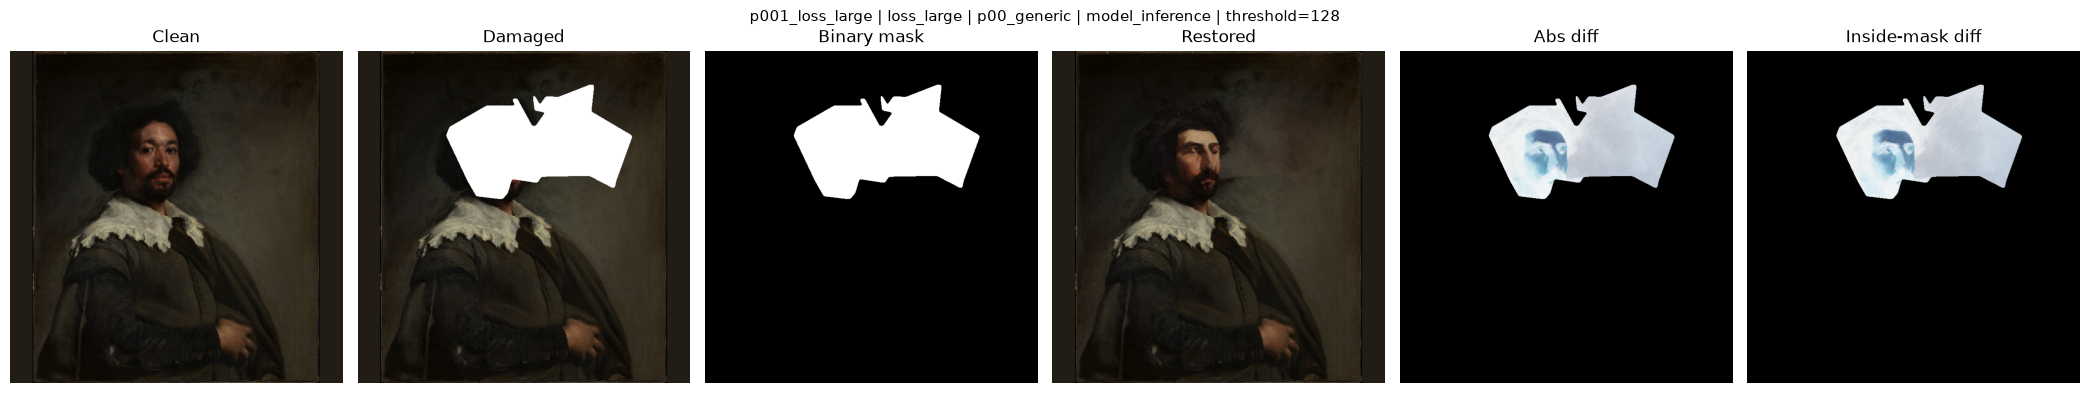

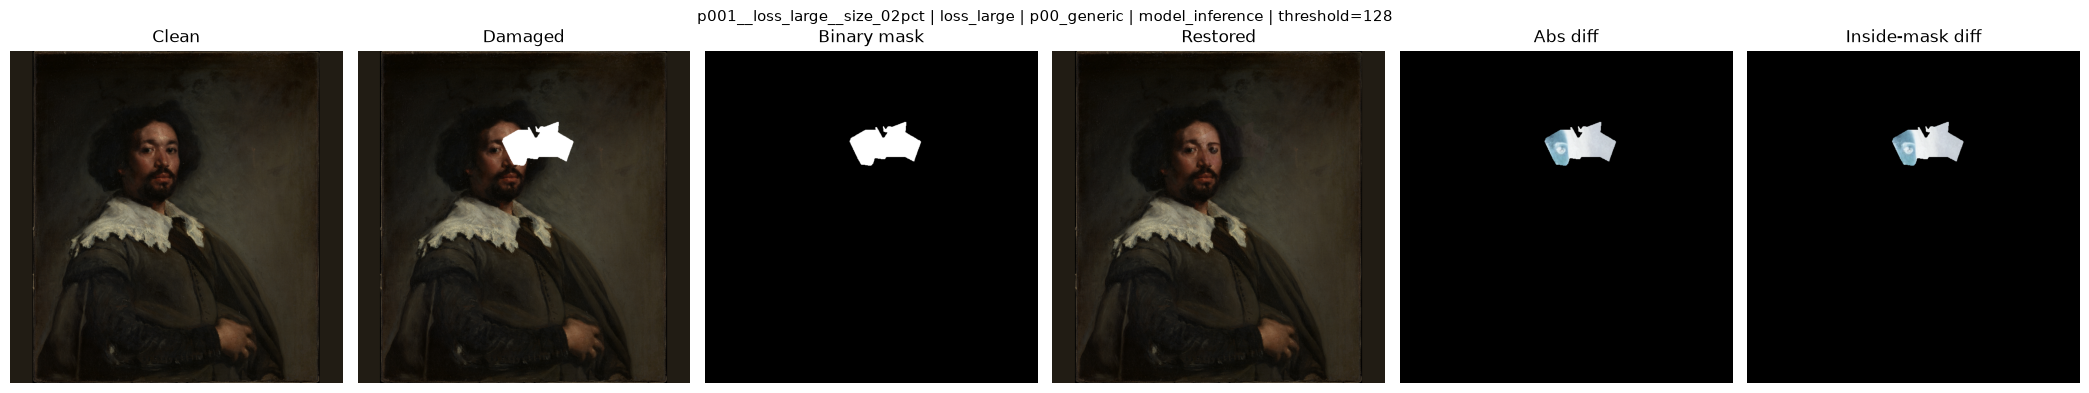

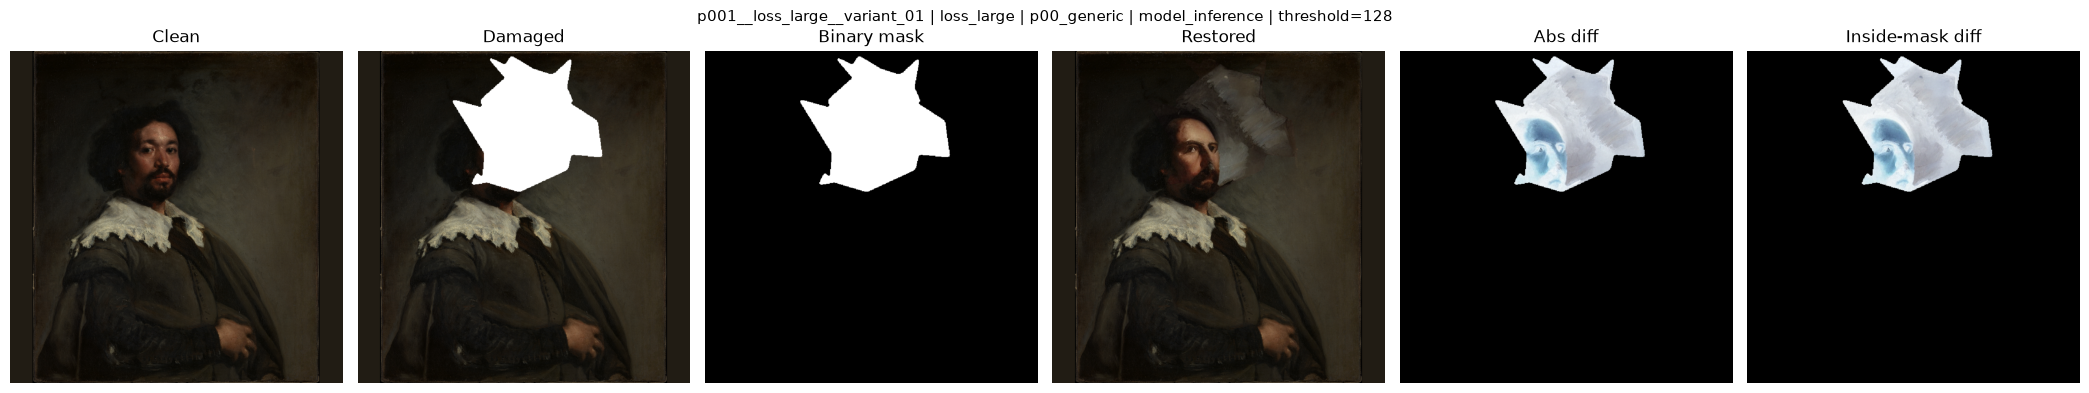

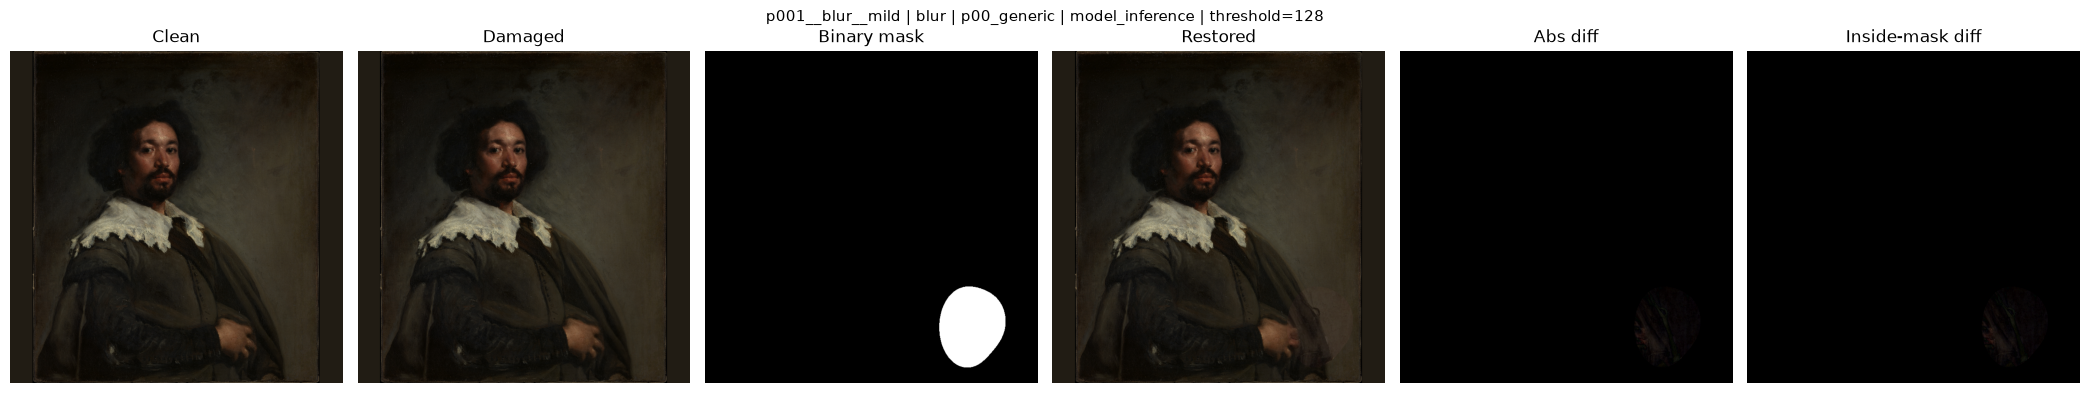

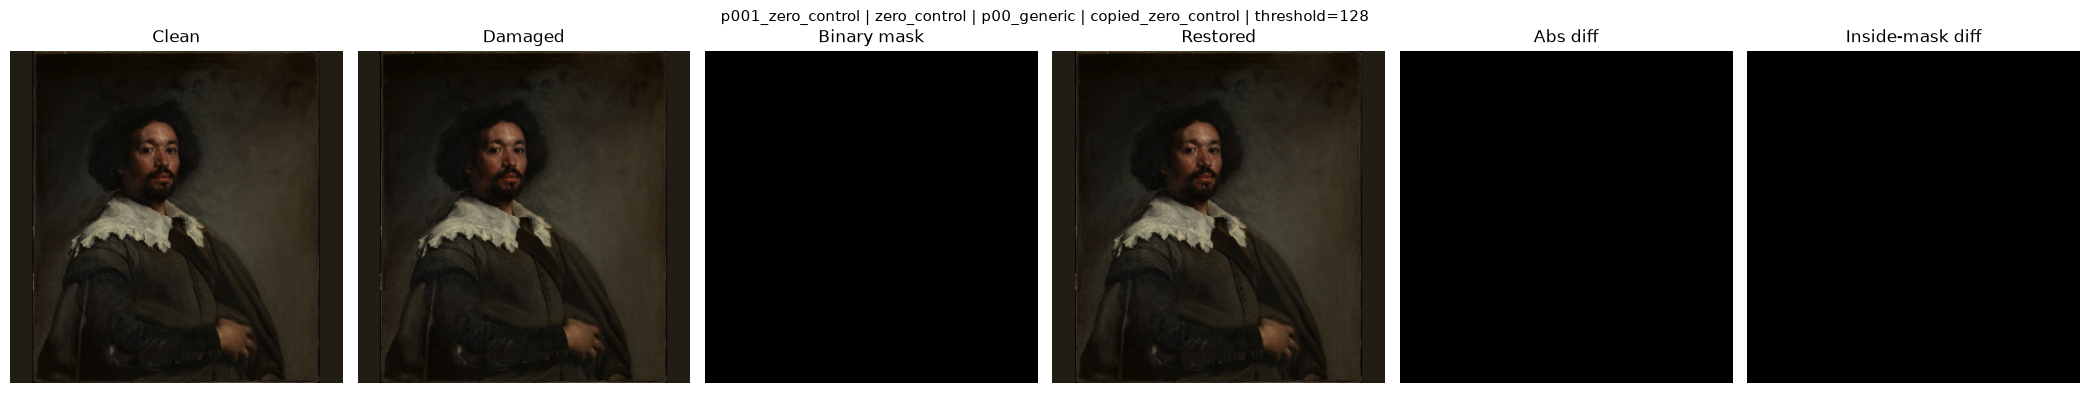

,restoration_case_id,candidate_id,case_id,mask_type,inference_mode,mask_binary_threshold,panel_path
0,smoke__sd__can__p001__loss_large__p00_generic__s2026__9441d9b074,smoke__sd__can__p001__loss_large__p00_generic__s2026__9441d9b074,p001_loss_large,loss_large,model_inference,128,outputs/21_stable_diffusion_restoration/figures/stable_diffusion_smoke_panels/smoke_sd_can_p001_loss_large_p00_generic_s2026_9441d9b074_panel.png
1,smoke__sd__dsz__p001__loss_large__p00_generic__s2026__fa1e62c449,smoke__sd__dsz__p001__loss_large__p00_generic__s2026__fa1e62c449,p001__loss_large__size_02pct,loss_large,model_inference,128,outputs/21_stable_diffusion_restoration/figures/stable_diffusion_smoke_panels/smoke_sd_dsz_p001_loss_large_p00_generic_s2026_fa1e62c449_panel.png
2,smoke__sd__mrob__p001__loss_large__p00_generic__s2026__791c7333f4,smoke__sd__mrob__p001__loss_large__p00_generic__s2026__791c7333f4,p001__loss_large__variant_01,loss_large,model_inference,128,outputs/21_stable_diffusion_restoration/figures/stable_diffusion_smoke_panels/smoke_sd_mrob_p001_loss_large_p00_generic_s2026_791c7333f4_panel.png
3,smoke__sd__syn__p001__blur__p00_generic__s2026__fd7709ae10,smoke__sd__syn__p001__blur__p00_generic__s2026__fd7709ae10,p001__blur__mild,blur,model_inference,128,outputs/21_stable_diffusion_restoration/figures/stable_diffusion_smoke_panels/smoke_sd_syn_p001_blur_p00_generic_s2026_fd7709ae10_panel.png
4,smoke__sd__can__p001__zero__p00_generic__s2026__3be104a7ae,smoke__sd__can__p001__zero__p00_generic__s2026__3be104a7ae,p001_zero_control,zero_control,copied_zero_control,128,outputs/21_stable_diffusion_restoration/figures/stable_diffusion_smoke_panels/smoke_sd_can_p001_zero_p00_generic_s2026_3be104a7ae_panel.png


Smoke panels: 5
Saved: outputs/21_stable_diffusion_restoration/validation/stable_diffusion_smoke_panels.csv


In [27]:
def load_panel_image(path_value: object, mode: str = "RGB") -> Image.Image:
    return Image.open(resolve_path(path_value, project_root=PROJECT_ROOT)).convert(mode)


smoke_panel_rows = []

for _, row in stable_diffusion_smoke_audit_df.iterrows():
    clean_img = load_panel_image(row["clean_path"], "RGB")
    damaged_img = load_panel_image(row["damaged_path"], "RGB")
    raw_mask_img = load_panel_image(row["mask_path"], "L")
    restored_img = load_panel_image(row["restored_path"], "RGB")

    binary_mask_img = binarize_mask_image(
        raw_mask_img,
        threshold=int(row.get("mask_binary_threshold", stable_diffusion_config.mask_binary_threshold)),
    )

    damaged_arr = np.asarray(damaged_img.convert("RGB")).astype(np.int16)
    restored_arr = np.asarray(restored_img.convert("RGB")).astype(np.int16)
    binary_mask_arr = np.asarray(binary_mask_img) > 0
    diff_arr = np.abs(restored_arr - damaged_arr).astype(np.uint8)
    inside_diff_arr = np.zeros_like(diff_arr)
    inside_diff_arr[binary_mask_arr] = diff_arr[binary_mask_arr]

    changed_pixels_arr = np.zeros((*binary_mask_arr.shape, 3), dtype=np.uint8)
    changed_pixels_arr[binary_mask_arr] = [255, 255, 255]

    fig, axes = plt.subplots(1, 6, figsize=(21, 4))

    axes[0].imshow(clean_img)
    axes[0].set_title("Clean")

    axes[1].imshow(damaged_img)
    axes[1].set_title("Damaged")

    axes[2].imshow(binary_mask_img, cmap="gray")
    axes[2].set_title("Binary mask")

    axes[3].imshow(restored_img)
    axes[3].set_title("Restored")

    axes[4].imshow(diff_arr)
    axes[4].set_title("Abs diff")

    axes[5].imshow(inside_diff_arr)
    axes[5].set_title("Inside-mask diff")

    for axis in axes:
        axis.axis("off")

    title = (
        f"{row['case_id']} | {row['mask_type']} | "
        f"{row['prompt_variant_id']} | {row['inference_mode']} | "
        f"threshold={row.get('mask_binary_threshold', stable_diffusion_config.mask_binary_threshold)}"
    )
    fig.suptitle(title, fontsize=11)
    fig.tight_layout()

    panel_path = (
        BATCH3_SMOKE_PANELS_DIR
        / f"{safe_slug(row['restoration_case_id'])[:120]}_panel.png"
    )
    fig.savefig(panel_path, dpi=160, bbox_inches="tight")
    plt.show()
    plt.close(fig)

    smoke_panel_rows.append(
        {
            "restoration_case_id": row["restoration_case_id"],
            "candidate_id": row["candidate_id"],
            "case_id": row["case_id"],
            "mask_type": row["mask_type"],
            "inference_mode": row["inference_mode"],
            "mask_binary_threshold": row.get("mask_binary_threshold", stable_diffusion_config.mask_binary_threshold),
            "panel_path": project_relative_path(panel_path),
        }
    )

stable_diffusion_smoke_panels_df = pd.DataFrame(smoke_panel_rows)
BATCH3_SMOKE_PANELS_MANIFEST_OUTPUT_PATH = VALIDATION_DIR / "stable_diffusion_smoke_panels.csv"
stable_diffusion_smoke_panels_df.to_csv(BATCH3_SMOKE_PANELS_MANIFEST_OUTPUT_PATH, index=False)

display(stable_diffusion_smoke_panels_df)

print("Smoke panels:", len(stable_diffusion_smoke_panels_df))
print("Saved:", project_relative_path(BATCH3_SMOKE_PANELS_MANIFEST_OUTPUT_PATH))

In [28]:
batch3_panel_checks_df = pd.DataFrame(
    [
        build_check(
            "batch3_smoke_panels_created",
            len(stable_diffusion_smoke_panels_df),
            len(stable_diffusion_smoke_audit_df),
            len(stable_diffusion_smoke_panels_df) == len(stable_diffusion_smoke_audit_df),
            "Smoke panel count does not match smoke audit rows.",
        ),
        build_check(
            "batch3_smoke_panel_files_exist",
            stable_diffusion_smoke_panels_df["panel_path"].tolist(),
            "all files exist",
            stable_diffusion_smoke_panels_df["panel_path"].map(
                lambda value: (PROJECT_ROOT / value).is_file()
            ).all(),
            "At least one smoke panel file is missing.",
        ),
    ]
)

display(batch3_panel_checks_df)

if not batch3_panel_checks_df["passed"].astype(bool).all():
    raise RuntimeError("Batch 3 smoke panel validation failed.")

print("Batch 3 complete: smoke audit, smoke validation, and smoke panels are ready.")

,check_name,observed,expected,passed,failure_message
0,batch3_smoke_panels_created,5,5,True,
1,batch3_smoke_panel_files_exist,"[outputs/21_stable_diffusion_restoration/figures/stable_diffusion_smoke_panels/smoke_sd_can_p001_loss_large_p00_generic_s2026_9441d9b074_panel.png, outputs/21_stable_diffusion_...",all files exist,True,


Batch 3 complete: smoke audit, smoke validation, and smoke panels are ready.


In [29]:
# Batch 4: run generic Stable Diffusion prompt on all source cases.

import json
import time
from pathlib import Path

import pandas as pd

from restoration_eval.restoration_stable_diffusion import (
    ZERO_CONTROL_MASK_TYPE,
    DEFAULT_PROMPT_POLICY_ID,
    StableDiffusionInpaintConfig,
    get_device,
    run_stable_diffusion_candidates,
    validate_stable_diffusion_restoration_outputs,
    summarize_stable_diffusion_restoration_metadata,
)

GENERIC_PROMPT_VARIANT_ID = globals().get("GENERIC_PROMPT_VARIANT_ID", "p00_generic")

if "stable_diffusion_config" not in globals():
    stable_diffusion_config = StableDiffusionInpaintConfig(
        prompt_policy_id=DEFAULT_PROMPT_POLICY_ID,
        base_seed=2026,
        num_inference_steps=30,
        guidance_scale=7.5,
        strength=1.0,
        inference_size=512,
        precision="float16",
        zero_control_behavior="copy_without_inference",
    )

BATCH4_AUDIT_OUTPUT_PATH = OUTPUT_ROOT / "stable_diffusion_restoration_audit.csv"
BATCH4_RUN_INFO_OUTPUT_PATH = VALIDATION_DIR / "stable_diffusion_batch4_generic_run_info.json"
BATCH4_VALIDATION_OUTPUT_PATH = VALIDATION_DIR / "stable_diffusion_restoration_validation.csv"
BATCH4_CHECKS_OUTPUT_PATH = VALIDATION_DIR / "stable_diffusion_batch4_generic_checks.csv"
BATCH4_SUMMARY_OUTPUT_PATH = VALIDATION_DIR / "stable_diffusion_restoration_summary_overview.csv"
BATCH4_DATASET_SUMMARY_OUTPUT_PATH = VALIDATION_DIR / "stable_diffusion_restoration_summary_by_dataset.csv"
BATCH4_DATASET_MASK_SUMMARY_OUTPUT_PATH = VALIDATION_DIR / "stable_diffusion_restoration_summary_by_dataset_mask.csv"
BATCH4_PROMPT_SUMMARY_OUTPUT_PATH = VALIDATION_DIR / "stable_diffusion_restoration_summary_by_prompt_variant.csv"
BATCH4_MODE_SUMMARY_OUTPUT_PATH = VALIDATION_DIR / "stable_diffusion_restoration_summary_by_inference_mode.csv"

STABLE_DIFFUSION_RESTORED_ROOT_DIR = PROJECT_ROOT / "data/processed/restored/stable_diffusion"

for path in [
    BATCH4_AUDIT_OUTPUT_PATH.parent,
    BATCH4_RUN_INFO_OUTPUT_PATH.parent,
    STABLE_DIFFUSION_RESTORED_ROOT_DIR,
]:
    path.mkdir(parents=True, exist_ok=True)

BATCH4_DEVICE = get_device(prefer_cuda=stable_diffusion_config.prefer_cuda)
require_cuda_device(BATCH4_DEVICE, "Batch 4 generic full run")
BATCH4_RESUME_EXISTING = False
BATCH4_PROGRESS_EVERY = 10

print("Batch 4 device:", BATCH4_DEVICE)
print("Generic prompt variant:", GENERIC_PROMPT_VARIANT_ID)
print("Main audit:", project_relative_path(BATCH4_AUDIT_OUTPUT_PATH))

Batch 4 generic full run requested device: cuda
Torch version: 2.5.1+cu121
CUDA available: True
CUDA device count: 1
CUDA device name: NVIDIA GeForce RTX 3060 Laptop GPU
Batch 4 device: cuda
Generic prompt variant: p00_generic
Main audit: outputs/21_stable_diffusion_restoration/stable_diffusion_restoration_audit.csv


In [30]:
if "stable_diffusion_candidate_manifest_df" not in globals():
    if "BATCH2_CANDIDATE_MANIFEST_OUTPUT_PATH" not in globals():
        BATCH2_CANDIDATE_MANIFEST_OUTPUT_PATH = OUTPUT_ROOT / "stable_diffusion_candidate_manifest.csv"

    stable_diffusion_candidate_manifest_df = pd.read_csv(BATCH2_CANDIDATE_MANIFEST_OUTPUT_PATH)

stable_diffusion_candidate_manifest_df = stable_diffusion_candidate_manifest_df.copy()

print("Candidate manifest rows:", len(stable_diffusion_candidate_manifest_df))
print(
    "Prompt variants:",
    stable_diffusion_candidate_manifest_df["prompt_variant_id"].value_counts(dropna=False).to_dict(),
)

Candidate manifest rows: 945
Prompt variants: {'p00_generic': 465, 'p01_style_period': 120, 'p02_artist': 120, 'p03_artist_style_period': 120, 'p04_full_context': 120}


In [31]:
stable_diffusion_batch4_generic_candidates_df = (
    stable_diffusion_candidate_manifest_df[
        stable_diffusion_candidate_manifest_df["prompt_variant_id"].astype(str).eq(GENERIC_PROMPT_VARIANT_ID)
    ]
    .copy()
    .sort_values(["dataset_name", "painting_id", "mask_type", "source_case_key", "candidate_seed"])
    .reset_index(drop=True)
)

if stable_diffusion_batch4_generic_candidates_df.empty:
    raise RuntimeError("Batch 4 found no generic prompt candidates.")

expected_generic_rows = int(stable_diffusion_batch4_generic_candidates_df["source_case_key"].nunique())

display(
    stable_diffusion_batch4_generic_candidates_df[
        [
            "candidate_index",
            "candidate_id",
            "restoration_case_id",
            "dataset_name",
            "case_id",
            "painting_id",
            "mask_type",
            "prompt_variant_id",
            "candidate_seed",
            "restored_path",
        ]
    ].head(20)
)

print("Generic candidates:", len(stable_diffusion_batch4_generic_candidates_df))
print("Unique source cases:", expected_generic_rows)
print(
    "Mask types:",
    stable_diffusion_batch4_generic_candidates_df["mask_type"].value_counts(dropna=False).to_dict(),
)

,candidate_index,candidate_id,restoration_case_id,dataset_name,case_id,painting_id,mask_type,prompt_variant_id,candidate_seed,restored_path
0,1,sd__can__p001__loss_large__p00_generic__s2026__9441d9b074,sd__can__p001__loss_large__p00_generic__s2026__9441d9b074,canonical,p001_loss_large,p001,loss_large,p00_generic,2026,data/processed/restored/stable_diffusion/canonical/p00_generic/sd__can__p001__loss_large__p00_generic__s2026__9441d9b074__restored_stable_diffusion_inpainting.png
1,2,sd__can__p001__loss_small__p00_generic__s2026__d6c5849fa0,sd__can__p001__loss_small__p00_generic__s2026__d6c5849fa0,canonical,p001_loss_small,p001,loss_small,p00_generic,2026,data/processed/restored/stable_diffusion/canonical/p00_generic/sd__can__p001__loss_small__p00_generic__s2026__d6c5849fa0__restored_stable_diffusion_inpainting.png
2,3,sd__can__p001__mixed_damage__p00_generic__s2026__6b27938af9,sd__can__p001__mixed_damage__p00_generic__s2026__6b27938af9,canonical,p001_mixed_damage,p001,mixed_damage,p00_generic,2026,data/processed/restored/stable_diffusion/canonical/p00_generic/sd__can__p001__mixed_damage__p00_generic__s2026__6b27938af9__restored_stable_diffusion_inpainting.png
3,4,sd__can__p001__scratch_thin__p00_generic__s2026__ccbc26b41e,sd__can__p001__scratch_thin__p00_generic__s2026__ccbc26b41e,canonical,p001_scratch_thin,p001,scratch_thin,p00_generic,2026,data/processed/restored/stable_diffusion/canonical/p00_generic/sd__can__p001__scratch_thin__p00_generic__s2026__ccbc26b41e__restored_stable_diffusion_inpainting.png
4,5,sd__can__p001__zero__p00_generic__s2026__3be104a7ae,sd__can__p001__zero__p00_generic__s2026__3be104a7ae,canonical,p001_zero_control,p001,zero_control,p00_generic,2026,data/processed/restored/stable_diffusion/canonical/p00_generic/sd__can__p001__zero__p00_generic__s2026__3be104a7ae__restored_stable_diffusion_inpainting.png
5,6,sd__can__p002__loss_large__p00_generic__s2026__59c0a6e9b9,sd__can__p002__loss_large__p00_generic__s2026__59c0a6e9b9,canonical,p002_loss_large,p002,loss_large,p00_generic,2026,data/processed/restored/stable_diffusion/canonical/p00_generic/sd__can__p002__loss_large__p00_generic__s2026__59c0a6e9b9__restored_stable_diffusion_inpainting.png
6,7,sd__can__p002__loss_small__p00_generic__s2026__0f60011f8c,sd__can__p002__loss_small__p00_generic__s2026__0f60011f8c,canonical,p002_loss_small,p002,loss_small,p00_generic,2026,data/processed/restored/stable_diffusion/canonical/p00_generic/sd__can__p002__loss_small__p00_generic__s2026__0f60011f8c__restored_stable_diffusion_inpainting.png
7,8,sd__can__p002__mixed_damage__p00_generic__s2026__9142f960af,sd__can__p002__mixed_damage__p00_generic__s2026__9142f960af,canonical,p002_mixed_damage,p002,mixed_damage,p00_generic,2026,data/processed/restored/stable_diffusion/canonical/p00_generic/sd__can__p002__mixed_damage__p00_generic__s2026__9142f960af__restored_stable_diffusion_inpainting.png
8,9,sd__can__p002__scratch_thin__p00_generic__s2026__ae2333cff6,sd__can__p002__scratch_thin__p00_generic__s2026__ae2333cff6,canonical,p002_scratch_thin,p002,scratch_thin,p00_generic,2026,data/processed/restored/stable_diffusion/canonical/p00_generic/sd__can__p002__scratch_thin__p00_generic__s2026__ae2333cff6__restored_stable_diffusion_inpainting.png
9,10,sd__can__p002__zero__p00_generic__s2026__606dc73934,sd__can__p002__zero__p00_generic__s2026__606dc73934,canonical,p002_zero_control,p002,zero_control,p00_generic,2026,data/processed/restored/stable_diffusion/canonical/p00_generic/sd__can__p002__zero__p00_generic__s2026__606dc73934__restored_stable_diffusion_inpainting.png


Generic candidates: 465
Unique source cases: 465
Mask types: {'loss_large': 110, 'loss_small': 75, 'scratch_thin': 75, 'mixed_damage': 50, 'zero_control': 50, 'blur': 15, 'dirt_dust': 15, 'discolouration': 15, 'fading': 15, 'partial_transparency': 15, 'water_stain': 15, 'blur_fading': 5, 'fading_discolouration': 5, 'water_stain_dirt': 5}


In [32]:
batch4_start = time.perf_counter()

stable_diffusion_batch4_result = run_stable_diffusion_candidates(
    stable_diffusion_batch4_generic_candidates_df,
    restored_root_dir=STABLE_DIFFUSION_RESTORED_ROOT_DIR,
    config=stable_diffusion_config,
    project_root=PROJECT_ROOT,
    pipe=globals().get("stable_diffusion_pipe", None),
    device=BATCH4_DEVICE,
    use_relative_paths=True,
    resume_existing=BATCH4_RESUME_EXISTING,
    progress_every=BATCH4_PROGRESS_EVERY,
)

batch4_runtime_seconds = time.perf_counter() - batch4_start

stable_diffusion_batch4_audit_df = stable_diffusion_batch4_result["restoration_metadata_df"].copy()
stable_diffusion_batch4_run_info = dict(stable_diffusion_batch4_result["run_info"])
stable_diffusion_batch4_run_info["batch4_runtime_seconds"] = float(batch4_runtime_seconds)

with open(BATCH4_RUN_INFO_OUTPUT_PATH, "w", encoding="utf-8") as file:
    json.dump(stable_diffusion_batch4_run_info, file, indent=2, ensure_ascii=False)

display(
    stable_diffusion_batch4_audit_df[
        [
            "candidate_id",
            "dataset_name",
            "case_id",
            "painting_id",
            "mask_type",
            "prompt_variant_id",
            "inference_mode",
            "runtime_seconds",
            "output_written",
            "status",
            "issue",
            "restored_path",
            "execution_device",
            "cuda_device_name",
            "mask_binary_threshold",
            "mask_raw_nonzero_pixel_count",
            "mask_thresholded_pixel_count",
            "effective_mask_pixel_count",
            "effective_mask_threshold_policy",
            "mask_gray_max",
            "restoration_generator_version",
            "preserve_unmasked_pixels",
        ]
    ].head(30)
)

print(f"Batch 4 runtime: {batch4_runtime_seconds:.2f} seconds")
print("Batch 4 rows:", len(stable_diffusion_batch4_audit_df))
print("Status:", stable_diffusion_batch4_audit_df["status"].value_counts(dropna=False).to_dict())
print("Inference modes:", stable_diffusion_batch4_audit_df["inference_mode"].value_counts(dropna=False).to_dict())
print("Saved:", project_relative_path(BATCH4_RUN_INFO_OUTPUT_PATH))

D:\Masters\FH\Thesis\painting-restoration-eval\.venv\Lib\site-packages\huggingface_hub\file_download.py:1142: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
vae\diffusion_pytorch_model.safetensors not found
Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]D:\Masters\FH\Thesis\painting-restoration-eval\.venv\Lib\site-packages\diffusers\models\modeling_utils.py:110: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the function

Stable Diffusion candidate 1/465: sd__can__p001__loss_large__p00_generic__s2026__9441d9b074
Stable Diffusion candidate 10/465: sd__can__p002__zero__p00_generic__s2026__606dc73934
Stable Diffusion candidate 20/465: sd__can__p004__zero__p00_generic__s2026__f5472b104d
Stable Diffusion candidate 30/465: sd__can__p006__zero__p00_generic__s2026__673d844071
Stable Diffusion candidate 40/465: sd__can__p008__zero__p00_generic__s2026__b83552a6cb
Stable Diffusion candidate 50/465: sd__can__p010__zero__p00_generic__s2026__b3bf0e71d4
Stable Diffusion candidate 60/465: sd__can__p012__zero__p00_generic__s2026__33c2e69c79
Stable Diffusion candidate 70/465: sd__can__p014__zero__p00_generic__s2026__b6b0b2c4cf
Stable Diffusion candidate 80/465: sd__can__p016__zero__p00_generic__s2026__12d870ea2f
Stable Diffusion candidate 90/465: sd__can__p018__zero__p00_generic__s2026__dae8f85992
Stable Diffusion candidate 100/465: sd__can__p020__zero__p00_generic__s2026__aaaca2352a
Stable Diffusion candidate 110/465: s

,candidate_id,dataset_name,case_id,painting_id,mask_type,prompt_variant_id,inference_mode,runtime_seconds,output_written,status,issue,restored_path,execution_device,cuda_device_name,mask_binary_threshold,mask_raw_nonzero_pixel_count,mask_thresholded_pixel_count,effective_mask_pixel_count,effective_mask_threshold_policy,mask_gray_max,restoration_generator_version,preserve_unmasked_pixels
0,sd__can__p001__loss_large__p00_generic__s2026__9441d9b074,canonical,p001_loss_large,p001,loss_large,p00_generic,model_inference,7.206220,True,ok,,data/processed/restored/stable_diffusion/canonical/p00_generic/sd__can__p001__loss_large__p00_generic__s2026__9441d9b074__restored_stable_diffusion_inpainting.png,cuda,NVIDIA GeForce RTX 3060 Laptop GPU,128,69018.0,69018.0,69018.0,configured_threshold,255.0,4.2_soft_mask_nonzero_fallback,True
1,sd__can__p001__loss_small__p00_generic__s2026__d6c5849fa0,canonical,p001_loss_small,p001,loss_small,p00_generic,model_inference,7.036892,True,ok,,data/processed/restored/stable_diffusion/canonical/p00_generic/sd__can__p001__loss_small__p00_generic__s2026__d6c5849fa0__restored_stable_diffusion_inpainting.png,cuda,NVIDIA GeForce RTX 3060 Laptop GPU,128,18239.0,18239.0,18239.0,configured_threshold,255.0,4.2_soft_mask_nonzero_fallback,True
2,sd__can__p001__mixed_damage__p00_generic__s2026__6b27938af9,canonical,p001_mixed_damage,p001,mixed_damage,p00_generic,model_inference,6.903118,True,ok,,data/processed/restored/stable_diffusion/canonical/p00_generic/sd__can__p001__mixed_damage__p00_generic__s2026__6b27938af9__restored_stable_diffusion_inpainting.png,cuda,NVIDIA GeForce RTX 3060 Laptop GPU,128,45733.0,45733.0,45733.0,configured_threshold,255.0,4.2_soft_mask_nonzero_fallback,True
3,sd__can__p001__scratch_thin__p00_generic__s2026__ccbc26b41e,canonical,p001_scratch_thin,p001,scratch_thin,p00_generic,model_inference,7.191327,True,ok,,data/processed/restored/stable_diffusion/canonical/p00_generic/sd__can__p001__scratch_thin__p00_generic__s2026__ccbc26b41e__restored_stable_diffusion_inpainting.png,cuda,NVIDIA GeForce RTX 3060 Laptop GPU,128,12058.0,12058.0,12058.0,configured_threshold,255.0,4.2_soft_mask_nonzero_fallback,True
4,sd__can__p001__zero__p00_generic__s2026__3be104a7ae,canonical,p001_zero_control,p001,zero_control,p00_generic,copied_zero_control,0.005163,True,ok,zero_control copied without model inference,data/processed/restored/stable_diffusion/canonical/p00_generic/sd__can__p001__zero__p00_generic__s2026__3be104a7ae__restored_stable_diffusion_inpainting.png,cuda,NVIDIA GeForce RTX 3060 Laptop GPU,128,NaN,NaN,NaN,NaN,NaN,4.2_soft_mask_nonzero_fallback,True
5,sd__can__p002__loss_large__p00_generic__s2026__59c0a6e9b9,canonical,p002_loss_large,p002,loss_large,p00_generic,model_inference,7.091234,True,ok,,data/processed/restored/stable_diffusion/canonical/p00_generic/sd__can__p002__loss_large__p00_generic__s2026__59c0a6e9b9__restored_stable_diffusion_inpainting.png,cuda,NVIDIA GeForce RTX 3060 Laptop GPU,128,37439.0,37439.0,37439.0,configured_threshold,255.0,4.2_soft_mask_nonzero_fallback,True
6,sd__can__p002__loss_small__p00_generic__s2026__0f60011f8c,canonical,p002_loss_small,p002,loss_small,p00_generic,model_inference,7.309058,True,ok,,data/processed/restored/stable_diffusion/canonical/p00_generic/sd__can__p002__loss_small__p00_generic__s2026__0f60011f8c__restored_stable_diffusion_inpainting.png,cuda,NVIDIA GeForce RTX 3060 Laptop GPU,128,18776.0,18776.0,18776.0,configured_threshold,255.0,4.2_soft_mask_nonzero_fallback,True
7,sd__can__p002__mixed_damage__p00_generic__s2026__9142f960af,canonical,p002_mixed_damage,p002,mixed_damage,p00_generic,model_inference,7.601382,True,ok,,data/processed/restored/stable_diffusion/canonical/p00_generic/sd__can__p002__mixed_damage__p00_generic__s2026__9142f960af__restored_stable_diffusion_inpainting.png,cuda,NVIDIA GeForce RTX 3060 Laptop GPU,128,34546.0,34546.0,34546.0,configured_threshold,255.0,4.2_soft_mask_nonzero_fallback,True
8,sd__can__p002__scratch_thin__p00_generic

Batch 4 runtime: 4239.75 seconds
Batch 4 rows: 465
Status: {'ok': 465}
Inference modes: {'model_inference': 415, 'copied_zero_control': 50}
Saved: outputs/21_stable_diffusion_restoration/validation/stable_diffusion_batch4_generic_run_info.json


In [33]:
if BATCH4_AUDIT_OUTPUT_PATH.is_file():
    existing_audit_df = pd.read_csv(BATCH4_AUDIT_OUTPUT_PATH)
else:
    existing_audit_df = pd.DataFrame()

audit_parts = [
    part for part in [existing_audit_df, stable_diffusion_batch4_audit_df]
    if part is not None and not part.empty
]

stable_diffusion_restoration_audit_df = (
    pd.concat(audit_parts, ignore_index=True, sort=False)
    if audit_parts
    else pd.DataFrame()
)

stable_diffusion_restoration_audit_df = (
    stable_diffusion_restoration_audit_df
    .drop_duplicates(subset=["candidate_id"], keep="last")
    .sort_values(["dataset_name", "painting_id", "mask_type", "source_case_key", "prompt_variant_id", "candidate_seed"])
    .reset_index(drop=True)
)

stable_diffusion_restoration_audit_df.to_csv(BATCH4_AUDIT_OUTPUT_PATH, index=False)

display(
    stable_diffusion_restoration_audit_df[
        [
            "candidate_id",
            "dataset_name",
            "case_id",
            "painting_id",
            "mask_type",
            "prompt_variant_id",
            "inference_mode",
            "output_written",
            "status",
            "restored_path",
        ]
    ].head(30)
)

print("Main audit rows:", len(stable_diffusion_restoration_audit_df))
print("Generic rows in main audit:", int(stable_diffusion_restoration_audit_df["prompt_variant_id"].astype(str).eq(GENERIC_PROMPT_VARIANT_ID).sum()))
print("Saved:", project_relative_path(BATCH4_AUDIT_OUTPUT_PATH))

,candidate_id,dataset_name,case_id,painting_id,mask_type,prompt_variant_id,inference_mode,output_written,status,restored_path
0,sd__can__p001__loss_large__p00_generic__s2026__9441d9b074,canonical,p001_loss_large,p001,loss_large,p00_generic,model_inference,True,ok,data/processed/restored/stable_diffusion/canonical/p00_generic/sd__can__p001__loss_large__p00_generic__s2026__9441d9b074__restored_stable_diffusion_inpainting.png
1,sd__can__p001__loss_small__p00_generic__s2026__d6c5849fa0,canonical,p001_loss_small,p001,loss_small,p00_generic,model_inference,True,ok,data/processed/restored/stable_diffusion/canonical/p00_generic/sd__can__p001__loss_small__p00_generic__s2026__d6c5849fa0__restored_stable_diffusion_inpainting.png
2,sd__can__p001__mixed_damage__p00_generic__s2026__6b27938af9,canonical,p001_mixed_damage,p001,mixed_damage,p00_generic,model_inference,True,ok,data/processed/restored/stable_diffusion/canonical/p00_generic/sd__can__p001__mixed_damage__p00_generic__s2026__6b27938af9__restored_stable_diffusion_inpainting.png
3,sd__can__p001__scratch_thin__p00_generic__s2026__ccbc26b41e,canonical,p001_scratch_thin,p001,scratch_thin,p00_generic,model_inference,True,ok,data/processed/restored/stable_diffusion/canonical/p00_generic/sd__can__p001__scratch_thin__p00_generic__s2026__ccbc26b41e__restored_stable_diffusion_inpainting.png
4,sd__can__p001__zero__p00_generic__s2026__3be104a7ae,canonical,p001_zero_control,p001,zero_control,p00_generic,copied_zero_control,True,ok,data/processed/restored/stable_diffusion/canonical/p00_generic/sd__can__p001__zero__p00_generic__s2026__3be104a7ae__restored_stable_diffusion_inpainting.png
5,sd__can__p002__loss_large__p00_generic__s2026__59c0a6e9b9,canonical,p002_loss_large,p002,loss_large,p00_generic,model_inference,True,ok,data/processed/restored/stable_diffusion/canonical/p00_generic/sd__can__p002__loss_large__p00_generic__s2026__59c0a6e9b9__restored_stable_diffusion_inpainting.png
6,sd__can__p002__loss_small__p00_generic__s2026__0f60011f8c,canonical,p002_loss_small,p002,loss_small,p00_generic,model_inference,True,ok,data/processed/restored/stable_diffusion/canonical/p00_generic/sd__can__p002__loss_small__p00_generic__s2026__0f60011f8c__restored_stable_diffusion_inpainting.png
7,sd__can__p002__mixed_damage__p00_generic__s2026__9142f960af,canonical,p002_mixed_damage,p002,mixed_damage,p00_generic,model_inference,True,ok,data/processed/restored/stable_diffusion/canonical/p00_generic/sd__can__p002__mixed_damage__p00_generic__s2026__9142f960af__restored_stable_diffusion_inpainting.png
8,sd__can__p002__scratch_thin__p00_generic__s2026__ae2333cff6,canonical,p002_scratch_thin,p002,scratch_thin,p00_generic,model_inference,True,ok,data/processed/restored/stable_diffusion/canonical/p00_generic/sd__can__p002__scratch_thin__p00_generic__s2026__ae2333cff6__restored_stable_diffusion_inpainting.png
9,sd__can__p002__zero__p00_generic__s2026__606dc73934,canonical,p002_zero_control,p002,zero_control,p00_generic,copied_zero_control,True,ok,data/processed/restored/stable_diffusion/canonical/p00_generic/sd__can__p002__zero__p00_generic__s2026__606dc73934__restored_stable_diffusion_inpainting.png


Main audit rows: 465
Generic rows in main audit: 465
Saved: outputs/21_stable_diffusion_restoration/stable_diffusion_restoration_audit.csv


In [34]:
stable_diffusion_restoration_validation_df = validate_stable_diffusion_restoration_outputs(
    stable_diffusion_restoration_audit_df,
    project_root=PROJECT_ROOT,
    zero_control_mask_type=ZERO_CONTROL_MASK_TYPE,
    zero_control_behavior=stable_diffusion_config.zero_control_behavior,
    progress_every=25,
)

stable_diffusion_restoration_validation_df.to_csv(BATCH4_VALIDATION_OUTPUT_PATH, index=False)

display(
    stable_diffusion_restoration_validation_df[
        [
            "candidate_id",
            "dataset_name",
            "case_id",
            "painting_id",
            "mask_type",
            "prompt_variant_id",
            "status",
            "restored_exists",
            "exact_match_to_damaged",
            "changed_from_damaged",
            "validation_passed",
            "validation_issue",
            "inside_mask_changed",
            "inside_mask_mean_abs_diff",
            "outside_mask_exact_match",
            "outside_mask_mean_abs_diff",
            "outside_mask_max_abs_diff",
            "mask_binary_threshold",
            "mask_raw_nonzero_pixel_count",
            "mask_thresholded_pixel_count",
            "effective_mask_pixel_count",
            "effective_mask_threshold_policy",
            "mask_gray_max",
            "mask_pixel_count",
        ]
    ].head(30)
)

print("Validation rows:", len(stable_diffusion_restoration_validation_df))
print("Validation passed:", stable_diffusion_restoration_validation_df["validation_passed"].value_counts(dropna=False).to_dict())
print("Saved:", project_relative_path(BATCH4_VALIDATION_OUTPUT_PATH))

Validating Stable Diffusion output 1/465
Validating Stable Diffusion output 25/465
Validating Stable Diffusion output 50/465
Validating Stable Diffusion output 75/465
Validating Stable Diffusion output 100/465
Validating Stable Diffusion output 125/465
Validating Stable Diffusion output 150/465
Validating Stable Diffusion output 175/465
Validating Stable Diffusion output 200/465
Validating Stable Diffusion output 225/465
Validating Stable Diffusion output 250/465
Validating Stable Diffusion output 275/465
Validating Stable Diffusion output 300/465
Validating Stable Diffusion output 325/465
Validating Stable Diffusion output 350/465
Validating Stable Diffusion output 375/465
Validating Stable Diffusion output 400/465
Validating Stable Diffusion output 425/465
Validating Stable Diffusion output 450/465
Validating Stable Diffusion output 465/465


,candidate_id,dataset_name,case_id,painting_id,mask_type,prompt_variant_id,status,restored_exists,exact_match_to_damaged,changed_from_damaged,validation_passed,validation_issue,inside_mask_changed,inside_mask_mean_abs_diff,outside_mask_exact_match,outside_mask_mean_abs_diff,outside_mask_max_abs_diff,mask_binary_threshold,mask_raw_nonzero_pixel_count,mask_thresholded_pixel_count,effective_mask_pixel_count,effective_mask_threshold_policy,mask_gray_max,mask_pixel_count
0,sd__can__p001__loss_large__p00_generic__s2026__9441d9b074,canonical,p001_loss_large,p001,loss_large,p00_generic,ok,True,False,True,True,,True,213.606378,True,0.0,0.0,128,69018,69018,69018,configured_threshold,255,69018
1,sd__can__p001__loss_small__p00_generic__s2026__d6c5849fa0,canonical,p001_loss_small,p001,loss_small,p00_generic,ok,True,False,True,True,,True,230.115174,True,0.0,0.0,128,18239,18239,18239,configured_threshold,255,18239
2,sd__can__p001__mixed_damage__p00_generic__s2026__6b27938af9,canonical,p001_mixed_damage,p001,mixed_damage,p00_generic,ok,True,False,True,True,,True,213.606812,True,0.0,0.0,128,45733,45733,45733,configured_threshold,255,45733
3,sd__can__p001__scratch_thin__p00_generic__s2026__ccbc26b41e,canonical,p001_scratch_thin,p001,scratch_thin,p00_generic,ok,True,False,True,True,,True,163.357992,True,0.0,0.0,128,12058,12058,12058,configured_threshold,255,12058
4,sd__can__p001__zero__p00_generic__s2026__3be104a7ae,canonical,p001_zero_control,p001,zero_control,p00_generic,ok,True,True,False,True,,False,NaN,True,0.0,0.0,128,0,0,0,configured_threshold,0,0
5,sd__can__p002__loss_large__p00_generic__s2026__59c0a6e9b9,canonical,p002_loss_large,p002,loss_large,p00_generic,ok,True,False,True,True,,True,172.400972,True,0.0,0.0,128,37439,37439,37439,configured_threshold,255,37439
6,sd__can__p002__loss_small__p00_generic__s2026__0f60011f8c,canonical,p002_loss_small,p002,loss_small,p00_generic,ok,True,False,True,True,,True,204.724791,True,0.0,0.0,128,18776,18776,18776,configured_threshold,255,18776
7,sd__can__p002__mixed_damage__p00_generic__s2026__9142f960af,canonical,p002_mixed_damage,p002,mixed_damage,p00_generic,ok,True,False,True,True,,True,191.192179,True,0.0,0.0,128,34546,34546,34546,configured_threshold,255,34546
8,sd__can__p002__scratch_thin__p00_generic__s2026__ae2333cff6,canonical,p002_scratch_thin,p002,scratch_thin,p00_generic,ok,True,False,True,True,,True,141.631871,True,0.0,0.0,128,9599,9599,9599,configured_threshold,255,9599
9,sd__can__p002__zero__p00_generic__s2026__606dc73934,canonical,p002_zero_control,p002,zero_control,p00_generic,ok,True,True,False,True,,False,NaN,True,0.0,0.0,128,0,0,0,configured_threshold,0,0


Validation rows: 465
Validation passed: {True: 465}
Saved: outputs/21_stable_diffusion_restoration/validation/stable_diffusion_restoration_validation.csv


In [35]:
stable_diffusion_restoration_summary = summarize_stable_diffusion_restoration_metadata(
    stable_diffusion_restoration_audit_df
)

stable_diffusion_restoration_summary["overview_df"].to_csv(BATCH4_SUMMARY_OUTPUT_PATH, index=False)
stable_diffusion_restoration_summary["by_dataset_df"].to_csv(BATCH4_DATASET_SUMMARY_OUTPUT_PATH, index=False)
stable_diffusion_restoration_summary["by_dataset_mask_df"].to_csv(BATCH4_DATASET_MASK_SUMMARY_OUTPUT_PATH, index=False)
stable_diffusion_restoration_summary["by_prompt_variant_df"].to_csv(BATCH4_PROMPT_SUMMARY_OUTPUT_PATH, index=False)
stable_diffusion_restoration_summary["by_inference_mode_df"].to_csv(BATCH4_MODE_SUMMARY_OUTPUT_PATH, index=False)

display(stable_diffusion_restoration_summary["overview_df"])
display(stable_diffusion_restoration_summary["by_dataset_mask_df"])

print("Saved:", project_relative_path(BATCH4_SUMMARY_OUTPUT_PATH))
print("Saved:", project_relative_path(BATCH4_DATASET_SUMMARY_OUTPUT_PATH))
print("Saved:", project_relative_path(BATCH4_DATASET_MASK_SUMMARY_OUTPUT_PATH))
print("Saved:", project_relative_path(BATCH4_PROMPT_SUMMARY_OUTPUT_PATH))
print("Saved:", project_relative_path(BATCH4_MODE_SUMMARY_OUTPUT_PATH))

,item,value
0,total_rows,465.000000
1,unique_source_cases,465.000000
2,unique_candidates,465.000000
3,successful_rows,465.000000
4,error_rows,0.000000
5,mean_runtime_seconds,9.073919


,dataset_name,mask_type,candidates,source_cases,successful_candidates,error_candidates,mean_runtime_seconds,median_runtime_seconds
0,canonical,loss_large,50,50,50,0,9.902989,9.935927
1,canonical,loss_small,50,50,50,0,9.913068,9.973436
2,canonical,mixed_damage,50,50,50,0,9.947574,9.943154
3,canonical,scratch_thin,50,50,50,0,9.964057,9.973567
4,canonical,zero_control,50,50,50,0,0.012610,0.013144
5,damage_size_sensitivity,loss_large,35,35,35,0,10.434073,10.425516
6,mask_robustness,loss_large,25,25,25,0,10.457188,10.445979
7,mask_robustness,loss_small,25,25,25,0,10.458263,10.453707
8,mask_robustness,scratch_thin,25,25,25,0,10.463546,10.449127
9,synthetic_degradation,blur,15,15,15,0,10.413298,10.440363


Saved: outputs/21_stable_diffusion_restoration/validation/stable_diffusion_restoration_summary_overview.csv
Saved: outputs/21_stable_diffusion_restoration/validation/stable_diffusion_restoration_summary_by_dataset.csv
Saved: outputs/21_stable_diffusion_restoration/validation/stable_diffusion_restoration_summary_by_dataset_mask.csv
Saved: outputs/21_stable_diffusion_restoration/validation/stable_diffusion_restoration_summary_by_prompt_variant.csv
Saved: outputs/21_stable_diffusion_restoration/validation/stable_diffusion_restoration_summary_by_inference_mode.csv


In [36]:
generic_audit_df = stable_diffusion_restoration_audit_df[
    stable_diffusion_restoration_audit_df["prompt_variant_id"].astype(str).eq(GENERIC_PROMPT_VARIANT_ID)
].copy()

generic_validation_df = stable_diffusion_restoration_validation_df[
    stable_diffusion_restoration_validation_df["prompt_variant_id"].astype(str).eq(GENERIC_PROMPT_VARIANT_ID)
].copy()

batch4_checks = [
    build_check(
        "batch4_generic_candidate_rows",
        len(stable_diffusion_batch4_generic_candidates_df),
        expected_generic_rows,
        len(stable_diffusion_batch4_generic_candidates_df) == expected_generic_rows,
        "Generic candidate row count does not match unique source-case count.",
    ),
    build_check(
        "batch4_run_returned_all_generic_rows",
        len(stable_diffusion_batch4_audit_df),
        len(stable_diffusion_batch4_generic_candidates_df),
        len(stable_diffusion_batch4_audit_df) == len(stable_diffusion_batch4_generic_candidates_df),
        "Batch 4 run did not return one audit row per generic candidate.",
    ),
    build_check(
        "batch4_run_status_ok",
        stable_diffusion_batch4_audit_df["status"].value_counts(dropna=False).to_dict(),
        {"ok": len(stable_diffusion_batch4_audit_df)},
        bool(stable_diffusion_batch4_audit_df["status"].astype(str).eq("ok").all()),
        "At least one Batch 4 generic restoration failed.",
    ),
    build_check(
        "batch4_outputs_written",
        int(stable_diffusion_batch4_audit_df["output_written"].astype(bool).sum()),
        len(stable_diffusion_batch4_audit_df),
        bool(stable_diffusion_batch4_audit_df["output_written"].astype(bool).all()),
        "At least one Batch 4 output was not written.",
    ),
    build_check(
        "batch4_main_audit_written",
        project_relative_path(BATCH4_AUDIT_OUTPUT_PATH),
        "file exists",
        BATCH4_AUDIT_OUTPUT_PATH.is_file(),
        "Main Stable Diffusion audit CSV was not written.",
    ),
    build_check(
        "batch4_main_audit_candidate_ids_unique",
        int(stable_diffusion_restoration_audit_df["candidate_id"].duplicated(keep=False).sum()),
        0,
        int(stable_diffusion_restoration_audit_df["candidate_id"].duplicated(keep=False).sum()) == 0,
        "Main audit contains duplicate candidate_id values.",
    ),
    build_check(
        "batch4_main_audit_has_all_generic_candidates",
        int(generic_audit_df["candidate_id"].nunique()),
        len(stable_diffusion_batch4_generic_candidates_df),
        int(generic_audit_df["candidate_id"].nunique()) == len(stable_diffusion_batch4_generic_candidates_df),
        "Main audit does not contain every generic candidate.",
    ),
    build_check(
        "batch4_validation_rows_match_audit",
        len(stable_diffusion_restoration_validation_df),
        len(stable_diffusion_restoration_audit_df),
        len(stable_diffusion_restoration_validation_df) == len(stable_diffusion_restoration_audit_df),
        "Validation row count does not match main audit row count.",
    ),
    build_check(
        "batch4_generic_validation_passed",
        generic_validation_df["validation_passed"].value_counts(dropna=False).to_dict(),
        {True: len(generic_validation_df)},
        bool(len(generic_validation_df) > 0 and generic_validation_df["validation_passed"].astype(bool).all()),
        "At least one generic restoration failed output validation.",
    ),
    build_check(
        "batch4_generic_nonzero_inside_mask_changed",
        int(generic_validation_df[
            generic_validation_df["mask_type"].astype(str).ne(ZERO_CONTROL_MASK_TYPE)
        ]["inside_mask_changed"].fillna(False).astype(bool).sum()),
        int(generic_validation_df["mask_type"].astype(str).ne(ZERO_CONTROL_MASK_TYPE).sum()),
        int(generic_validation_df[
            generic_validation_df["mask_type"].astype(str).ne(ZERO_CONTROL_MASK_TYPE)
        ]["inside_mask_changed"].fillna(False).astype(bool).sum())
        == int(generic_validation_df["mask_type"].astype(str).ne(ZERO_CONTROL_MASK_TYPE).sum()),
        "At least one generic non-zero output did not change pixels inside the binary mask.",
    ),
    build_check(
        "batch4_generic_nonzero_outside_mask_preserved",
        int(generic_validation_df[
            generic_validation_df["mask_type"].astype(str).ne(ZERO_CONTROL_MASK_TYPE)
        ]["outside_mask_exact_match"].fillna(False).astype(bool).sum()),
        int(generic_validation_df["mask_type"].astype(str).ne(ZERO_CONTROL_MASK_TYPE).sum()),
        int(generic_validation_df[
            generic_validation_df["mask_type"].astype(str).ne(ZERO_CONTROL_MASK_TYPE)
        ]["outside_mask_exact_match"].fillna(False).astype(bool).sum())
        == int(generic_validation_df["mask_type"].astype(str).ne(ZERO_CONTROL_MASK_TYPE).sum()),
        "At least one generic non-zero output changed pixels outside the binary mask.",
    ),
    build_check(
        "batch4_validation_written",
        project_relative_path(BATCH4_VALIDATION_OUTPUT_PATH),
        "file exists",
        BATCH4_VALIDATION_OUTPUT_PATH.is_file(),
        "Stable Diffusion validation CSV was not written.",
    ),
]

batch4_checks_df = pd.DataFrame(batch4_checks)

batch4_checks_export_df = batch4_checks_df.copy()
for column in ["observed", "expected"]:
    batch4_checks_export_df[column] = batch4_checks_export_df[column].map(json_for_csv)

batch4_checks_export_df.to_csv(BATCH4_CHECKS_OUTPUT_PATH, index=False)

display(batch4_checks_df)

print("Batch 4 checks passed:", int(batch4_checks_df["passed"].sum()), "/", len(batch4_checks_df))
print("Saved:", project_relative_path(BATCH4_CHECKS_OUTPUT_PATH))

if not batch4_checks_df["passed"].all():
    display(
        batch4_checks_df.loc[
            ~batch4_checks_df["passed"],
            ["check_name", "failure_message"],
        ]
    )
    raise RuntimeError("Batch 4 generic Stable Diffusion run failed validation.")

,check_name,observed,expected,passed,failure_message
0,batch4_generic_candidate_rows,465,465,True,
1,batch4_run_returned_all_generic_rows,465,465,True,
2,batch4_run_status_ok,{'ok': 465},{'ok': 465},True,
3,batch4_outputs_written,465,465,True,
4,batch4_main_audit_written,outputs/21_stable_diffusion_restoration/stable_diffusion_restoration_audit.csv,file exists,True,
5,batch4_main_audit_candidate_ids_unique,0,0,True,
6,batch4_main_audit_has_all_generic_candidates,465,465,True,
7,batch4_validation_rows_match_audit,465,465,True,
8,batch4_generic_validation_passed,{True: 465},{True: 465},True,
9,batch4_generic_nonzero_inside_mask_changed,415,415,True,


Batch 4 checks passed: 12 / 12
Saved: outputs/21_stable_diffusion_restoration/validation/stable_diffusion_batch4_generic_checks.csv


In [37]:
preview_columns = [
    "candidate_id",
    "restoration_case_id",
    "dataset_name",
    "case_id",
    "painting_id",
    "mask_type",
    "prompt_variant_id",
    "inference_mode",
    "runtime_seconds",
    "status",
    "restored_path",
]

display(stable_diffusion_restoration_audit_df[preview_columns].head(20))
display(stable_diffusion_restoration_audit_df[preview_columns].tail(20))

print("Batch 4 complete.")
print("Main audit:", project_relative_path(BATCH4_AUDIT_OUTPUT_PATH))
print("Validation:", project_relative_path(BATCH4_VALIDATION_OUTPUT_PATH))

,candidate_id,restoration_case_id,dataset_name,case_id,painting_id,mask_type,prompt_variant_id,inference_mode,runtime_seconds,status,restored_path
0,sd__can__p001__loss_large__p00_generic__s2026__9441d9b074,sd__can__p001__loss_large__p00_generic__s2026__9441d9b074,canonical,p001_loss_large,p001,loss_large,p00_generic,model_inference,7.206220,ok,data/processed/restored/stable_diffusion/canonical/p00_generic/sd__can__p001__loss_large__p00_generic__s2026__9441d9b074__restored_stable_diffusion_inpainting.png
1,sd__can__p001__loss_small__p00_generic__s2026__d6c5849fa0,sd__can__p001__loss_small__p00_generic__s2026__d6c5849fa0,canonical,p001_loss_small,p001,loss_small,p00_generic,model_inference,7.036892,ok,data/processed/restored/stable_diffusion/canonical/p00_generic/sd__can__p001__loss_small__p00_generic__s2026__d6c5849fa0__restored_stable_diffusion_inpainting.png
2,sd__can__p001__mixed_damage__p00_generic__s2026__6b27938af9,sd__can__p001__mixed_damage__p00_generic__s2026__6b27938af9,canonical,p001_mixed_damage,p001,mixed_damage,p00_generic,model_inference,6.903118,ok,data/processed/restored/stable_diffusion/canonical/p00_generic/sd__can__p001__mixed_damage__p00_generic__s2026__6b27938af9__restored_stable_diffusion_inpainting.png
3,sd__can__p001__scratch_thin__p00_generic__s2026__ccbc26b41e,sd__can__p001__scratch_thin__p00_generic__s2026__ccbc26b41e,canonical,p001_scratch_thin,p001,scratch_thin,p00_generic,model_inference,7.191327,ok,data/processed/restored/stable_diffusion/canonical/p00_generic/sd__can__p001__scratch_thin__p00_generic__s2026__ccbc26b41e__restored_stable_diffusion_inpainting.png
4,sd__can__p001__zero__p00_generic__s2026__3be104a7ae,sd__can__p001__zero__p00_generic__s2026__3be104a7ae,canonical,p001_zero_control,p001,zero_control,p00_generic,copied_zero_control,0.005163,ok,data/processed/restored/stable_diffusion/canonical/p00_generic/sd__can__p001__zero__p00_generic__s2026__3be104a7ae__restored_stable_diffusion_inpainting.png
5,sd__can__p002__loss_large__p00_generic__s2026__59c0a6e9b9,sd__can__p002__loss_large__p00_generic__s2026__59c0a6e9b9,canonical,p002_loss_large,p002,loss_large,p00_generic,model_inference,7.091234,ok,data/processed/restored/stable_diffusion/canonical/p00_generic/sd__can__p002__loss_large__p00_generic__s2026__59c0a6e9b9__restored_stable_diffusion_inpainting.png
6,sd__can__p002__loss_small__p00_generic__s2026__0f60011f8c,sd__can__p002__loss_small__p00_generic__s2026__0f60011f8c,canonical,p002_loss_small,p002,loss_small,p00_generic,model_inference,7.309058,ok,data/processed/restored/stable_diffusion/canonical/p00_generic/sd__can__p002__loss_small__p00_generic__s2026__0f60011f8c__restored_stable_diffusion_inpainting.png
7,sd__can__p002__mixed_damage__p00_generic__s2026__9142f960af,sd__can__p002__mixed_damage__p00_generic__s2026__9142f960af,canonical,p002_mixed_damage,p002,mixed_damage,p00_generic,model_inference,7.601382,ok,data/processed/restored/stable_diffusion/canonical/p00_generic/sd__can__p002__mixed_damage__p00_generic__s2026__9142f960af__restored_stable_diffusion_inpainting.png
8,sd__can__p002__scratch_thin__p00_generic__s2026__ae2333cff6,sd__can__p002__scratch_thin__p00_generic__s2026__ae2333cff6,canonical,p002_scratch_thin,p002,scratch_thin,p00_generic,model_inference,7.838587,ok,data/processed/restored/stable_diffusion/canonical/p00_generic/sd__can__p002__scratch_thin__p00_generic__s2026__ae2333cff6__restored_stable_diffusion_inpainting.png
9,sd__can__p002__zero__p00_generic__s2026__606dc73934,sd__can__p002__zero__p00_generic__s2026__606dc73934,canonical,p002_zero_control,p002,zero_control,p00_generic,copied_zero_control,0.004090,ok,data/processed/restored/stable_diffusion/canonical/p00_generic/sd__can__p002__zero__p00_generic__s2026__606dc73934__restored_stable_diffusion_inpainting.png


,candidate_id,restoration_case_id,dataset_name,case_id,painting_id,mask_type,prompt_variant_id,inference_mode,runtime_seconds,status,restored_path
445,sd__syn__p043__blur__p00_generic__s2026__7cb827119e,sd__syn__p043__blur__p00_generic__s2026__7cb827119e,synthetic_degradation,p043__blur__moderate,p043,blur,p00_generic,model_inference,10.056955,ok,data/processed/restored/stable_diffusion/synthetic_degradation/p00_generic/sd__syn__p043__blur__p00_generic__s2026__7cb827119e__restored_stable_diffusion_inpainting.png
446,sd__syn__p043__blur__p00_generic__s2026__57594d924f,sd__syn__p043__blur__p00_generic__s2026__57594d924f,synthetic_degradation,p043__blur__severe,p043,blur,p00_generic,model_inference,10.129125,ok,data/processed/restored/stable_diffusion/synthetic_degradation/p00_generic/sd__syn__p043__blur__p00_generic__s2026__57594d924f__restored_stable_diffusion_inpainting.png
447,sd__syn__p043__blur_fading__p00_generic__s2026__9b15c33755,sd__syn__p043__blur_fading__p00_generic__s2026__9b15c33755,synthetic_degradation,p043__blur_fading__moderate,p043,blur_fading,p00_generic,model_inference,10.091824,ok,data/processed/restored/stable_diffusion/synthetic_degradation/p00_generic/sd__syn__p043__blur_fading__p00_generic__s2026__9b15c33755__restored_stable_diffusion_inpainting.png
448,sd__syn__p043__dirt_dust__p00_generic__s2026__ee231e48fa,sd__syn__p043__dirt_dust__p00_generic__s2026__ee231e48fa,synthetic_degradation,p043__dirt_dust__mild,p043,dirt_dust,p00_generic,model_inference,10.007309,ok,data/processed/restored/stable_diffusion/synthetic_degradation/p00_generic/sd__syn__p043__dirt_dust__p00_generic__s2026__ee231e48fa__restored_stable_diffusion_inpainting.png
449,sd__syn__p043__dirt_dust__p00_generic__s2026__7a90eaa70e,sd__syn__p043__dirt_dust__p00_generic__s2026__7a90eaa70e,synthetic_degradation,p043__dirt_dust__moderate,p043,dirt_dust,p00_generic,model_inference,10.036028,ok,data/processed/restored/stable_diffusion/synthetic_degradation/p00_generic/sd__syn__p043__dirt_dust__p00_generic__s2026__7a90eaa70e__restored_stable_diffusion_inpainting.png
450,sd__syn__p043__dirt_dust__p00_generic__s2026__006b263255,sd__syn__p043__dirt_dust__p00_generic__s2026__006b263255,synthetic_degradation,p043__dirt_dust__severe,p043,dirt_dust,p00_generic,model_inference,9.836579,ok,data/processed/restored/stable_diffusion/synthetic_degradation/p00_generic/sd__syn__p043__dirt_dust__p00_generic__s2026__006b263255__restored_stable_diffusion_inpainting.png
451,sd__syn__p043__discolouration__p00_generic__s2026__bbf91a2815,sd__syn__p043__discolouration__p00_generic__s2026__bbf91a2815,synthetic_degradation,p043__discolouration__mild,p043,discolouration,p00_generic,model_inference,10.207603,ok,data/processed/restored/stable_diffusion/synthetic_degradation/p00_generic/sd__syn__p043__discolouration__p00_generic__s2026__bbf91a2815__restored_stable_diffusion_inpainting.png
452,sd__syn__p043__discolouration__p00_generic__s2026__94e27ad4b7,sd__syn__p043__discolouration__p00_generic__s2026__94e27ad4b7,synthetic_degradation,p043__discolouration__moderate,p043,discolouration,p00_generic,model_inference,10.131110,ok,data/processed/restored/stable_diffusion/synthetic_degradation/p00_generic/sd__syn__p043__discolouration__p00_generic__s2026__94e27ad4b7__restored_stable_diffusion_inpainting.png
453,sd__syn__p043__discolouration__p00_generic__s2026__dc6f828e54,sd__syn__p043__discolouration__p00_generic__s2026__dc6f828e54,synthetic_degradation,p043__discolouration__severe,p043,discolouration,p00_generic,model_inference,10.116024,ok,data/processed/restored/stable_diffusion/synthetic_degradation/p00_generic/sd__syn__p043__discolouration__p00_generic__s2026__dc6f828e54__restored_stable_diffusion_inpainting.png
454,sd__syn__p043__fading__p00_generic__s2026__747b94cae2,sd__syn__p043__fading__p00_generic__s2026__747b94cae2,synthetic_degradation,p043__fading__mild,p043,fading,p00_generic,model_inference,10.053911,ok,data/processed/restored/stable_diffusion/synthetic_degradation/

Batch 4 complete.
Main audit: outputs/21_stable_diffusion_restoration/stable_diffusion_restoration_audit.csv
Validation: outputs/21_stable_diffusion_restoration/validation/stable_diffusion_restoration_validation.csv


In [38]:
# Batch 5: run contextual prompt variants on the controlled prompt-ablation subset.

import json
import time
from pathlib import Path

import pandas as pd

from restoration_eval.restoration_stable_diffusion import (
    ZERO_CONTROL_MASK_TYPE,
    DEFAULT_PROMPT_POLICY_ID,
    StableDiffusionInpaintConfig,
    get_device,
    run_stable_diffusion_candidates,
    validate_stable_diffusion_restoration_outputs,
    summarize_stable_diffusion_restoration_metadata,
)

GENERIC_PROMPT_VARIANT_ID = globals().get("GENERIC_PROMPT_VARIANT_ID", "p00_generic")

if "stable_diffusion_config" not in globals():
    stable_diffusion_config = StableDiffusionInpaintConfig(
        prompt_policy_id=DEFAULT_PROMPT_POLICY_ID,
        base_seed=2026,
        num_inference_steps=30,
        guidance_scale=7.5,
        strength=1.0,
        inference_size=512,
        precision="float16",
        zero_control_behavior="copy_without_inference",
    )

STABLE_DIFFUSION_RESTORED_ROOT_DIR = PROJECT_ROOT / "data/processed/restored/stable_diffusion"

BATCH5_AUDIT_OUTPUT_PATH = OUTPUT_ROOT / "stable_diffusion_restoration_audit.csv"
BATCH5_RUN_INFO_OUTPUT_PATH = VALIDATION_DIR / "stable_diffusion_batch5_contextual_run_info.json"
BATCH5_MAIN_VALIDATION_OUTPUT_PATH = VALIDATION_DIR / "stable_diffusion_restoration_validation.csv"
BATCH5_PROMPT_ABLATION_VALIDATION_OUTPUT_PATH = VALIDATION_DIR / "stable_diffusion_prompt_ablation_validation.csv"
BATCH5_CHECKS_OUTPUT_PATH = VALIDATION_DIR / "stable_diffusion_batch5_prompt_ablation_checks.csv"
BATCH5_ABLATION_SUMMARY_OUTPUT_PATH = VALIDATION_DIR / "stable_diffusion_prompt_ablation_summary_overview.csv"
BATCH5_ABLATION_BY_VARIANT_OUTPUT_PATH = VALIDATION_DIR / "stable_diffusion_prompt_ablation_summary_by_prompt_variant.csv"

for path in [
    STABLE_DIFFUSION_RESTORED_ROOT_DIR,
    BATCH5_AUDIT_OUTPUT_PATH.parent,
    BATCH5_RUN_INFO_OUTPUT_PATH.parent,
]:
    path.mkdir(parents=True, exist_ok=True)

BATCH5_DEVICE = get_device(prefer_cuda=stable_diffusion_config.prefer_cuda)
require_cuda_device(BATCH5_DEVICE, "Batch 5 contextual full run")
BATCH5_RESUME_EXISTING = False
BATCH5_PROGRESS_EVERY = 10

print("Batch 5 device:", BATCH5_DEVICE)
print("Main audit:", project_relative_path(BATCH5_AUDIT_OUTPUT_PATH))

Batch 5 contextual full run requested device: cuda
Torch version: 2.5.1+cu121
CUDA available: True
CUDA device count: 1
CUDA device name: NVIDIA GeForce RTX 3060 Laptop GPU
Batch 5 device: cuda
Main audit: outputs/21_stable_diffusion_restoration/stable_diffusion_restoration_audit.csv


In [39]:
if "stable_diffusion_candidate_manifest_df" not in globals():
    if "BATCH2_CANDIDATE_MANIFEST_OUTPUT_PATH" not in globals():
        BATCH2_CANDIDATE_MANIFEST_OUTPUT_PATH = OUTPUT_ROOT / "stable_diffusion_candidate_manifest.csv"
    stable_diffusion_candidate_manifest_df = pd.read_csv(BATCH2_CANDIDATE_MANIFEST_OUTPUT_PATH)

if "stable_diffusion_prompt_subset_cases_df" not in globals():
    if "BATCH2_PROMPT_SUBSET_OUTPUT_PATH" not in globals():
        BATCH2_PROMPT_SUBSET_OUTPUT_PATH = OUTPUT_ROOT / "stable_diffusion_prompt_subset_cases.csv"
    stable_diffusion_prompt_subset_cases_df = pd.read_csv(BATCH2_PROMPT_SUBSET_OUTPUT_PATH)

stable_diffusion_candidate_manifest_df = stable_diffusion_candidate_manifest_df.copy()
stable_diffusion_prompt_subset_cases_df = stable_diffusion_prompt_subset_cases_df.copy()

prompt_subset_keys = set(stable_diffusion_prompt_subset_cases_df["source_case_key"].astype(str))

print("Candidate manifest rows:", len(stable_diffusion_candidate_manifest_df))
print("Prompt subset source cases:", len(prompt_subset_keys))
print(
    "Prompt variants:",
    stable_diffusion_candidate_manifest_df["prompt_variant_id"].value_counts(dropna=False).to_dict(),
)

Candidate manifest rows: 945
Prompt subset source cases: 120
Prompt variants: {'p00_generic': 465, 'p01_style_period': 120, 'p02_artist': 120, 'p03_artist_style_period': 120, 'p04_full_context': 120}


In [40]:
stable_diffusion_batch5_contextual_candidates_df = (
    stable_diffusion_candidate_manifest_df[
        stable_diffusion_candidate_manifest_df["prompt_variant_id"].astype(str).ne(GENERIC_PROMPT_VARIANT_ID)
    ]
    .copy()
    .sort_values(["dataset_name", "painting_id", "mask_type", "source_case_key", "prompt_variant_order", "candidate_seed"])
    .reset_index(drop=True)
)

if stable_diffusion_batch5_contextual_candidates_df.empty:
    raise RuntimeError("Batch 5 found no contextual prompt candidates.")

contextual_source_keys = set(stable_diffusion_batch5_contextual_candidates_df["source_case_key"].astype(str))
outside_subset_keys = sorted(contextual_source_keys - prompt_subset_keys)

if outside_subset_keys:
    raise RuntimeError(f"Contextual candidates include cases outside the prompt subset: {outside_subset_keys[:10]}")

contextual_variant_count = int(
    stable_diffusion_batch5_contextual_candidates_df["prompt_variant_id"].nunique()
)
expected_contextual_rows = int(len(prompt_subset_keys) * contextual_variant_count)

display(
    stable_diffusion_batch5_contextual_candidates_df[
        [
            "candidate_index",
            "candidate_id",
            "restoration_case_id",
            "dataset_name",
            "case_id",
            "painting_id",
            "mask_type",
            "prompt_ablation_subset",
            "prompt_variant_id",
            "candidate_seed",
            "restored_path",
        ]
    ].head(30)
)

print("Contextual candidates:", len(stable_diffusion_batch5_contextual_candidates_df))
print("Contextual variants:", contextual_variant_count)
print("Unique contextual source cases:", len(contextual_source_keys))
print("Expected contextual rows:", expected_contextual_rows)

,candidate_index,candidate_id,restoration_case_id,dataset_name,case_id,painting_id,mask_type,prompt_ablation_subset,prompt_variant_id,candidate_seed,restored_path
0,17,sd__can__p004__loss_large__p01_style_period__s2026__ea7b25ac5a,sd__can__p004__loss_large__p01_style_period__s2026__ea7b25ac5a,canonical,p004_loss_large,p004,loss_large,True,p01_style_period,2026,data/processed/restored/stable_diffusion/canonical/p01_style_period/sd__can__p004__loss_large__p01_style_period__s2026__ea7b25ac5a__restored_stable_diffusion_inpainting.png
1,18,sd__can__p004__loss_large__p02_artist__s2026__c73c23c161,sd__can__p004__loss_large__p02_artist__s2026__c73c23c161,canonical,p004_loss_large,p004,loss_large,True,p02_artist,2026,data/processed/restored/stable_diffusion/canonical/p02_artist/sd__can__p004__loss_large__p02_artist__s2026__c73c23c161__restored_stable_diffusion_inpainting.png
2,19,sd__can__p004__loss_large__p03_artist_style_p__s2026__b0cf9a78ca,sd__can__p004__loss_large__p03_artist_style_p__s2026__b0cf9a78ca,canonical,p004_loss_large,p004,loss_large,True,p03_artist_style_period,2026,data/processed/restored/stable_diffusion/canonical/p03_artist_style_period/sd__can__p004__loss_large__p03_artist_style_p__s2026__b0cf9a78ca__restored_stable_diffusion_inpaintin...
3,20,sd__can__p004__loss_large__p04_full_context__s2026__a29f15defc,sd__can__p004__loss_large__p04_full_context__s2026__a29f15defc,canonical,p004_loss_large,p004,loss_large,True,p04_full_context,2026,data/processed/restored/stable_diffusion/canonical/p04_full_context/sd__can__p004__loss_large__p04_full_context__s2026__a29f15defc__restored_stable_diffusion_inpainting.png
4,22,sd__can__p004__loss_small__p01_style_period__s2026__6875d753fa,sd__can__p004__loss_small__p01_style_period__s2026__6875d753fa,canonical,p004_loss_small,p004,loss_small,True,p01_style_period,2026,data/processed/restored/stable_diffusion/canonical/p01_style_period/sd__can__p004__loss_small__p01_style_period__s2026__6875d753fa__restored_stable_diffusion_inpainting.png
5,23,sd__can__p004__loss_small__p02_artist__s2026__b447ea1ec9,sd__can__p004__loss_small__p02_artist__s2026__b447ea1ec9,canonical,p004_loss_small,p004,loss_small,True,p02_artist,2026,data/processed/restored/stable_diffusion/canonical/p02_artist/sd__can__p004__loss_small__p02_artist__s2026__b447ea1ec9__restored_stable_diffusion_inpainting.png
6,24,sd__can__p004__loss_small__p03_artist_style_p__s2026__244a7ff7e9,sd__can__p004__loss_small__p03_artist_style_p__s2026__244a7ff7e9,canonical,p004_loss_small,p004,loss_small,True,p03_artist_style_period,2026,data/processed/restored/stable_diffusion/canonical/p03_artist_style_period/sd__can__p004__loss_small__p03_artist_style_p__s2026__244a7ff7e9__restored_stable_diffusion_inpaintin...
7,25,sd__can__p004__loss_small__p04_full_context__s2026__35477c304b,sd__can__p004__loss_small__p04_full_context__s2026__35477c304b,canonical,p004_loss_small,p004,loss_small,True,p04_full_context,2026,data/processed/restored/stable_diffusion/canonical/p04_full_context/sd__can__p004__loss_small__p04_full_context__s2026__35477c304b__restored_stable_diffusion_inpainting.png
8,27,sd__can__p004__mixed_damage__p01_style_period__s2026__7a2827e1b4,sd__can__p004__mixed_damage__p01_style_period__s2026__7a2827e1b4,canonical,p004_mixed_damage,p004,mixed_damage,True,p01_style_period,2026,data/processed/restored/stable_diffusion/canonical/p01_style_period/sd__can__p004__mixed_damage__p01_style_period__s2026__7a2827e1b4__restored_stable_diffusion_inpainting.png
9,28,sd__can__p004__mixed_damage__p02_artist__s2026__149f0c96ae,sd__can__p004__mixed_damage__p02_artist__s2026__149f0c96ae,canonical,p004_mixed_damage,p004,mixed_damage,True,p02_artist,2026,data/processed/restored/stable_diffusion/canonical/p02_artist/sd__can__p004__mixed_damage__p02_artist__s2026__149f0c96ae__restored_stable_diffusion_inpainting.png


Contextual candidates: 480
Contextual variants: 4
Unique contextual source cases: 120
Expected contextual rows: 480


In [41]:
batch5_start = time.perf_counter()

stable_diffusion_batch5_result = run_stable_diffusion_candidates(
    stable_diffusion_batch5_contextual_candidates_df,
    restored_root_dir=STABLE_DIFFUSION_RESTORED_ROOT_DIR,
    config=stable_diffusion_config,
    project_root=PROJECT_ROOT,
    pipe=globals().get("stable_diffusion_pipe", None),
    device=BATCH5_DEVICE,
    use_relative_paths=True,
    resume_existing=BATCH5_RESUME_EXISTING,
    progress_every=BATCH5_PROGRESS_EVERY,
)

batch5_runtime_seconds = time.perf_counter() - batch5_start

stable_diffusion_batch5_audit_df = stable_diffusion_batch5_result["restoration_metadata_df"].copy()
stable_diffusion_batch5_run_info = dict(stable_diffusion_batch5_result["run_info"])
stable_diffusion_batch5_run_info["batch5_runtime_seconds"] = float(batch5_runtime_seconds)

with open(BATCH5_RUN_INFO_OUTPUT_PATH, "w", encoding="utf-8") as file:
    json.dump(stable_diffusion_batch5_run_info, file, indent=2, ensure_ascii=False)

display(
    stable_diffusion_batch5_audit_df[
        [
            "candidate_id",
            "dataset_name",
            "case_id",
            "painting_id",
            "mask_type",
            "prompt_variant_id",
            "inference_mode",
            "runtime_seconds",
            "output_written",
            "status",
            "issue",
            "restored_path",
            "execution_device",
            "cuda_device_name",
            "mask_binary_threshold",
            "preserve_unmasked_pixels",
        ]
    ].head(30)
)

print(f"Batch 5 runtime: {batch5_runtime_seconds:.2f} seconds")
print("Batch 5 rows:", len(stable_diffusion_batch5_audit_df))
print("Status:", stable_diffusion_batch5_audit_df["status"].value_counts(dropna=False).to_dict())
print("Saved:", project_relative_path(BATCH5_RUN_INFO_OUTPUT_PATH))

D:\Masters\FH\Thesis\painting-restoration-eval\.venv\Lib\site-packages\huggingface_hub\file_download.py:1142: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
vae\diffusion_pytorch_model.safetensors not found
Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]D:\Masters\FH\Thesis\painting-restoration-eval\.venv\Lib\site-packages\diffusers\models\modeling_utils.py:110: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the function

Stable Diffusion candidate 1/480: sd__can__p004__loss_large__p01_style_period__s2026__ea7b25ac5a
Stable Diffusion candidate 10/480: sd__can__p004__mixed_damage__p02_artist__s2026__149f0c96ae
Stable Diffusion candidate 20/480: sd__can__p004__zero__p04_full_context__s2026__12d7c77a63
Stable Diffusion candidate 30/480: sd__can__p008__mixed_damage__p02_artist__s2026__92cda93e19
Stable Diffusion candidate 40/480: sd__can__p008__zero__p04_full_context__s2026__d17f21b3e1
Stable Diffusion candidate 50/480: sd__can__p014__mixed_damage__p02_artist__s2026__c6a38a521d
Stable Diffusion candidate 60/480: sd__can__p014__zero__p04_full_context__s2026__389d299b29
Stable Diffusion candidate 70/480: sd__can__p018__mixed_damage__p02_artist__s2026__fa68968fd7
Stable Diffusion candidate 80/480: sd__can__p018__zero__p04_full_context__s2026__18fa176f20
Stable Diffusion candidate 90/480: sd__can__p024__mixed_damage__p02_artist__s2026__037f3c74dd
Stable Diffusion candidate 100/480: sd__can__p024__zero__p04_full

,candidate_id,dataset_name,case_id,painting_id,mask_type,prompt_variant_id,inference_mode,runtime_seconds,output_written,status,issue,restored_path,execution_device,cuda_device_name,mask_binary_threshold,preserve_unmasked_pixels
0,sd__can__p004__loss_large__p01_style_period__s2026__ea7b25ac5a,canonical,p004_loss_large,p004,loss_large,p01_style_period,model_inference,7.019409,True,ok,,data/processed/restored/stable_diffusion/canonical/p01_style_period/sd__can__p004__loss_large__p01_style_period__s2026__ea7b25ac5a__restored_stable_diffusion_inpainting.png,cuda,NVIDIA GeForce RTX 3060 Laptop GPU,128,True
1,sd__can__p004__loss_large__p02_artist__s2026__c73c23c161,canonical,p004_loss_large,p004,loss_large,p02_artist,model_inference,6.809885,True,ok,,data/processed/restored/stable_diffusion/canonical/p02_artist/sd__can__p004__loss_large__p02_artist__s2026__c73c23c161__restored_stable_diffusion_inpainting.png,cuda,NVIDIA GeForce RTX 3060 Laptop GPU,128,True
2,sd__can__p004__loss_large__p03_artist_style_p__s2026__b0cf9a78ca,canonical,p004_loss_large,p004,loss_large,p03_artist_style_period,model_inference,7.430802,True,ok,,data/processed/restored/stable_diffusion/canonical/p03_artist_style_period/sd__can__p004__loss_large__p03_artist_style_p__s2026__b0cf9a78ca__restored_stable_diffusion_inpaintin...,cuda,NVIDIA GeForce RTX 3060 Laptop GPU,128,True
3,sd__can__p004__loss_large__p04_full_context__s2026__a29f15defc,canonical,p004_loss_large,p004,loss_large,p04_full_context,model_inference,8.232763,True,ok,,data/processed/restored/stable_diffusion/canonical/p04_full_context/sd__can__p004__loss_large__p04_full_context__s2026__a29f15defc__restored_stable_diffusion_inpainting.png,cuda,NVIDIA GeForce RTX 3060 Laptop GPU,128,True
4,sd__can__p004__loss_small__p01_style_period__s2026__6875d753fa,canonical,p004_loss_small,p004,loss_small,p01_style_period,model_inference,9.121238,True,ok,,data/processed/restored/stable_diffusion/canonical/p01_style_period/sd__can__p004__loss_small__p01_style_period__s2026__6875d753fa__restored_stable_diffusion_inpainting.png,cuda,NVIDIA GeForce RTX 3060 Laptop GPU,128,True
5,sd__can__p004__loss_small__p02_artist__s2026__b447ea1ec9,canonical,p004_loss_small,p004,loss_small,p02_artist,model_inference,9.655009,True,ok,,data/processed/restored/stable_diffusion/canonical/p02_artist/sd__can__p004__loss_small__p02_artist__s2026__b447ea1ec9__restored_stable_diffusion_inpainting.png,cuda,NVIDIA GeForce RTX 3060 Laptop GPU,128,True
6,sd__can__p004__loss_small__p03_artist_style_p__s2026__244a7ff7e9,canonical,p004_loss_small,p004,loss_small,p03_artist_style_period,model_inference,9.804304,True,ok,,data/processed/restored/stable_diffusion/canonical/p03_artist_style_period/sd__can__p004__loss_small__p03_artist_style_p__s2026__244a7ff7e9__restored_stable_diffusion_inpaintin...,cuda,NVIDIA GeForce RTX 3060 Laptop GPU,128,True
7,sd__can__p004__loss_small__p04_full_context__s2026__35477c304b,canonical,p004_loss_small,p004,loss_small,p04_full_context,model_inference,9.843688,True,ok,,data/processed/restored/stable_diffusion/canonical/p04_full_context/sd__can__p004__loss_small__p04_full_context__s2026__35477c304b__restored_stable_diffusion_inpainting.png,cuda,NVIDIA GeForce RTX 3060 Laptop GPU,128,True
8,sd__can__p004__mixed_damage__p01_style_period__s2026__7a2827e1b4,canonical,p004_mixed_damage,p004,mixed_damage,p01_style_period,model_inference,9.891975,True,ok,,data/processed/restored/stable_diffusion/canonical/p01_style_period/sd__can__p004__mixed_damage__p01_style_period__s2026__7a2827e1b4__restored_stable_diffusion_inpainting.png,cuda,NVIDIA GeForce RTX 3060 Laptop GPU,128,True
9,sd__can__p004__mixed_damage__p02_artist__s2026__149f0c96ae,canonical,p004_mixed_damage,p004,mixed_damage,p02_artist,model_inference,9.897340,True,ok,,data/processed/restored/stable_diffusion/canonical/p02_artist/sd__can__p004__mixed_damage__p02_artist__s2026__149f0c96ae__restored_stable_diffusion_inpainting.png,cuda,NVIDIA GeForce RTX 3060 Laptop GPU,128,

Batch 5 runtime: 4176.79 seconds
Batch 5 rows: 480
Status: {'ok': 480}
Saved: outputs/21_stable_diffusion_restoration/validation/stable_diffusion_batch5_contextual_run_info.json


In [42]:
if BATCH5_AUDIT_OUTPUT_PATH.is_file():
    existing_audit_df = pd.read_csv(BATCH5_AUDIT_OUTPUT_PATH)
else:
    existing_audit_df = pd.DataFrame()

audit_parts = [
    part for part in [existing_audit_df, stable_diffusion_batch5_audit_df]
    if part is not None and not part.empty
]

stable_diffusion_restoration_audit_df = pd.concat(
    audit_parts,
    ignore_index=True,
    sort=False,
)

stable_diffusion_restoration_audit_df = (
    stable_diffusion_restoration_audit_df
    .drop_duplicates(subset=["candidate_id"], keep="last")
    .sort_values(["dataset_name", "painting_id", "mask_type", "source_case_key", "prompt_variant_id", "candidate_seed"])
    .reset_index(drop=True)
)

stable_diffusion_restoration_audit_df.to_csv(BATCH5_AUDIT_OUTPUT_PATH, index=False)

display(
    stable_diffusion_restoration_audit_df[
        [
            "candidate_id",
            "dataset_name",
            "case_id",
            "painting_id",
            "mask_type",
            "prompt_ablation_subset",
            "prompt_variant_id",
            "inference_mode",
            "output_written",
            "status",
            "restored_path",
        ]
    ].tail(30)
)

print("Main audit rows:", len(stable_diffusion_restoration_audit_df))
print(
    "Rows by prompt variant:",
    stable_diffusion_restoration_audit_df["prompt_variant_id"].value_counts(dropna=False).to_dict(),
)
print("Saved:", project_relative_path(BATCH5_AUDIT_OUTPUT_PATH))

,candidate_id,dataset_name,case_id,painting_id,mask_type,prompt_ablation_subset,prompt_variant_id,inference_mode,output_written,status,restored_path
915,sd__syn__p043__fading__p00_generic__s2026__bd6687ccac,synthetic_degradation,p043__fading__moderate,p043,fading,False,p00_generic,model_inference,True,ok,data/processed/restored/stable_diffusion/synthetic_degradation/p00_generic/sd__syn__p043__fading__p00_generic__s2026__bd6687ccac__restored_stable_diffusion_inpainting.png
916,sd__syn__p043__fading__p00_generic__s2026__cc97f68a01,synthetic_degradation,p043__fading__severe,p043,fading,True,p00_generic,model_inference,True,ok,data/processed/restored/stable_diffusion/synthetic_degradation/p00_generic/sd__syn__p043__fading__p00_generic__s2026__cc97f68a01__restored_stable_diffusion_inpainting.png
917,sd__syn__p043__fading__p01_style_period__s2026__beb282bcc7,synthetic_degradation,p043__fading__severe,p043,fading,True,p01_style_period,model_inference,True,ok,data/processed/restored/stable_diffusion/synthetic_degradation/p01_style_period/sd__syn__p043__fading__p01_style_period__s2026__beb282bcc7__restored_stable_diffusion_inpainting...
918,sd__syn__p043__fading__p02_artist__s2026__66be51e397,synthetic_degradation,p043__fading__severe,p043,fading,True,p02_artist,model_inference,True,ok,data/processed/restored/stable_diffusion/synthetic_degradation/p02_artist/sd__syn__p043__fading__p02_artist__s2026__66be51e397__restored_stable_diffusion_inpainting.png
919,sd__syn__p043__fading__p03_artist_style_p__s2026__9255561c0b,synthetic_degradation,p043__fading__severe,p043,fading,True,p03_artist_style_period,model_inference,True,ok,data/processed/restored/stable_diffusion/synthetic_degradation/p03_artist_style_period/sd__syn__p043__fading__p03_artist_style_p__s2026__9255561c0b__restored_stable_diffusion_i...
920,sd__syn__p043__fading__p04_full_context__s2026__5656e5d54e,synthetic_degradation,p043__fading__severe,p043,fading,True,p04_full_context,model_inference,True,ok,data/processed/restored/stable_diffusion/synthetic_degradation/p04_full_context/sd__syn__p043__fading__p04_full_context__s2026__5656e5d54e__restored_stable_diffusion_inpainting...
921,sd__syn__p043__fading_discolouration__p00_generic__s2026__190b245acb,synthetic_degradation,p043__fading_discolouration__moderate,p043,fading_discolouration,True,p00_generic,model_inference,True,ok,data/processed/restored/stable_diffusion/synthetic_degradation/p00_generic/sd__syn__p043__fading_discolouration__p00_generic__s2026__190b245acb__restored_stable_diffusion_inpai...
922,sd__syn__p043__fading_discolouration__p01_style_period__s2026__05f4bc65b9,synthetic_degradation,p043__fading_discolouration__moderate,p043,fading_discolouration,True,p01_style_period,model_inference,True,ok,data/processed/restored/stable_diffusion/synthetic_degradation/p01_style_period/sd__syn__p043__fading_discolouration__p01_style_period__s2026__05f4bc65b9__restored_stable_diffu...
923,sd__syn__p043__fading_discolouration__p02_artist__s2026__7ca8d59615,synthetic_degradation,p043__fading_discolouration__moderate,p043,fading_discolouration,True,p02_artist,model_inference,True,ok,data/processed/restored/stable_diffusion/synthetic_degradation/p02_artist/sd__syn__p043__fading_discolouration__p02_artist__s2026__7ca8d59615__restored_stable_diffusion_inpaint...
924,sd__syn__p043__fading_discolouration__p03_artist_style_p__s2026__29f524efe6,synthetic_degradation,p043__fading_discolouration__moderate,p043,fading_discolouration,True,p03_artist_style_period,model_inference,True,ok,data/processed/restored/stable_diffusion/synthetic_degradation/p03_artist_style_period/sd__syn__p043__fading_discolouration__p03_artist_style_p__s2026__29f524efe6__restored_sta...


Main audit rows: 945
Rows by prompt variant: {'p00_generic': 465, 'p01_style_period': 120, 'p02_artist': 120, 'p03_artist_style_period': 120, 'p04_full_context': 120}
Saved: outputs/21_stable_diffusion_restoration/stable_diffusion_restoration_audit.csv


In [43]:
stable_diffusion_restoration_validation_df = validate_stable_diffusion_restoration_outputs(
    stable_diffusion_restoration_audit_df,
    project_root=PROJECT_ROOT,
    zero_control_mask_type=ZERO_CONTROL_MASK_TYPE,
    zero_control_behavior=stable_diffusion_config.zero_control_behavior,
    progress_every=25,
)

stable_diffusion_restoration_validation_df.to_csv(BATCH5_MAIN_VALIDATION_OUTPUT_PATH, index=False)

stable_diffusion_prompt_ablation_validation_df = (
    stable_diffusion_restoration_validation_df[
        stable_diffusion_restoration_validation_df["prompt_variant_id"].astype(str).ne(GENERIC_PROMPT_VARIANT_ID)
    ]
    .copy()
    .sort_values(["dataset_name", "painting_id", "mask_type", "source_case_key", "prompt_variant_id"])
    .reset_index(drop=True)
)

stable_diffusion_prompt_ablation_validation_df.to_csv(
    BATCH5_PROMPT_ABLATION_VALIDATION_OUTPUT_PATH,
    index=False,
)

display(
    stable_diffusion_prompt_ablation_validation_df[
        [
            "candidate_id",
            "dataset_name",
            "case_id",
            "painting_id",
            "mask_type",
            "prompt_ablation_subset",
            "prompt_variant_id",
            "restored_exists",
            "exact_match_to_damaged",
            "changed_from_damaged",
            "validation_passed",
            "validation_issue",
            "inside_mask_changed",
            "outside_mask_exact_match",
            "outside_mask_mean_abs_diff",
            "outside_mask_max_abs_diff",
        ]
    ].head(30)
)

print("Main validation rows:", len(stable_diffusion_restoration_validation_df))
print("Prompt-ablation validation rows:", len(stable_diffusion_prompt_ablation_validation_df))
print("Saved:", project_relative_path(BATCH5_MAIN_VALIDATION_OUTPUT_PATH))
print("Saved:", project_relative_path(BATCH5_PROMPT_ABLATION_VALIDATION_OUTPUT_PATH))

Validating Stable Diffusion output 1/945
Validating Stable Diffusion output 25/945
Validating Stable Diffusion output 50/945
Validating Stable Diffusion output 75/945
Validating Stable Diffusion output 100/945
Validating Stable Diffusion output 125/945
Validating Stable Diffusion output 150/945
Validating Stable Diffusion output 175/945
Validating Stable Diffusion output 200/945
Validating Stable Diffusion output 225/945
Validating Stable Diffusion output 250/945
Validating Stable Diffusion output 275/945
Validating Stable Diffusion output 300/945
Validating Stable Diffusion output 325/945
Validating Stable Diffusion output 350/945
Validating Stable Diffusion output 375/945
Validating Stable Diffusion output 400/945
Validating Stable Diffusion output 425/945
Validating Stable Diffusion output 450/945
Validating Stable Diffusion output 475/945
Validating Stable Diffusion output 500/945
Validating Stable Diffusion output 525/945
Validating Stable Diffusion output 550/945
Validating Stabl

,candidate_id,dataset_name,case_id,painting_id,mask_type,prompt_ablation_subset,prompt_variant_id,restored_exists,exact_match_to_damaged,changed_from_damaged,validation_passed,validation_issue,inside_mask_changed,outside_mask_exact_match,outside_mask_mean_abs_diff,outside_mask_max_abs_diff
0,sd__can__p004__loss_large__p01_style_period__s2026__ea7b25ac5a,canonical,p004_loss_large,p004,loss_large,True,p01_style_period,True,False,True,True,,True,True,0.0,0.0
1,sd__can__p004__loss_large__p02_artist__s2026__c73c23c161,canonical,p004_loss_large,p004,loss_large,True,p02_artist,True,False,True,True,,True,True,0.0,0.0
2,sd__can__p004__loss_large__p03_artist_style_p__s2026__b0cf9a78ca,canonical,p004_loss_large,p004,loss_large,True,p03_artist_style_period,True,False,True,True,,True,True,0.0,0.0
3,sd__can__p004__loss_large__p04_full_context__s2026__a29f15defc,canonical,p004_loss_large,p004,loss_large,True,p04_full_context,True,False,True,True,,True,True,0.0,0.0
4,sd__can__p004__loss_small__p01_style_period__s2026__6875d753fa,canonical,p004_loss_small,p004,loss_small,True,p01_style_period,True,False,True,True,,True,True,0.0,0.0
5,sd__can__p004__loss_small__p02_artist__s2026__b447ea1ec9,canonical,p004_loss_small,p004,loss_small,True,p02_artist,True,False,True,True,,True,True,0.0,0.0
6,sd__can__p004__loss_small__p03_artist_style_p__s2026__244a7ff7e9,canonical,p004_loss_small,p004,loss_small,True,p03_artist_style_period,True,False,True,True,,True,True,0.0,0.0
7,sd__can__p004__loss_small__p04_full_context__s2026__35477c304b,canonical,p004_loss_small,p004,loss_small,True,p04_full_context,True,False,True,True,,True,True,0.0,0.0
8,sd__can__p004__mixed_damage__p01_style_period__s2026__7a2827e1b4,canonical,p004_mixed_damage,p004,mixed_damage,True,p01_style_period,True,False,True,True,,True,True,0.0,0.0
9,sd__can__p004__mixed_damage__p02_artist__s2026__149f0c96ae,canonical,p004_mixed_damage,p004,mixed_damage,True,p02_artist,True,False,True,True,,True,True,0.0,0.0


Main validation rows: 945
Prompt-ablation validation rows: 480
Saved: outputs/21_stable_diffusion_restoration/validation/stable_diffusion_restoration_validation.csv
Saved: outputs/21_stable_diffusion_restoration/validation/stable_diffusion_prompt_ablation_validation.csv


In [44]:
stable_diffusion_prompt_ablation_audit_df = (
    stable_diffusion_restoration_audit_df[
        stable_diffusion_restoration_audit_df["prompt_variant_id"].astype(str).ne(GENERIC_PROMPT_VARIANT_ID)
    ]
    .copy()
    .reset_index(drop=True)
)

stable_diffusion_prompt_ablation_summary = summarize_stable_diffusion_restoration_metadata(
    stable_diffusion_prompt_ablation_audit_df
)

stable_diffusion_prompt_ablation_summary["overview_df"].to_csv(
    BATCH5_ABLATION_SUMMARY_OUTPUT_PATH,
    index=False,
)
stable_diffusion_prompt_ablation_summary["by_prompt_variant_df"].to_csv(
    BATCH5_ABLATION_BY_VARIANT_OUTPUT_PATH,
    index=False,
)

display(stable_diffusion_prompt_ablation_summary["overview_df"])
display(stable_diffusion_prompt_ablation_summary["by_prompt_variant_df"])

print("Saved:", project_relative_path(BATCH5_ABLATION_SUMMARY_OUTPUT_PATH))
print("Saved:", project_relative_path(BATCH5_ABLATION_BY_VARIANT_OUTPUT_PATH))

,item,value
0,total_rows,480.000000
1,unique_source_cases,120.000000
2,unique_candidates,480.000000
3,successful_rows,480.000000
4,error_rows,0.000000
5,mean_runtime_seconds,8.658021


,prompt_variant_id,candidates,source_cases,successful_candidates,error_candidates,mean_runtime_seconds,median_runtime_seconds
0,p01_style_period,120,120,120,0,8.656825,9.467570
1,p02_artist,120,120,120,0,8.651505,9.453830
2,p03_artist_style_period,120,120,120,0,8.652048,9.450466
3,p04_full_context,120,120,120,0,8.671705,9.456567


Saved: outputs/21_stable_diffusion_restoration/validation/stable_diffusion_prompt_ablation_summary_overview.csv
Saved: outputs/21_stable_diffusion_restoration/validation/stable_diffusion_prompt_ablation_summary_by_prompt_variant.csv


In [45]:
contextual_audit_df = stable_diffusion_restoration_audit_df[
    stable_diffusion_restoration_audit_df["prompt_variant_id"].astype(str).ne(GENERIC_PROMPT_VARIANT_ID)
].copy()

generic_audit_df = stable_diffusion_restoration_audit_df[
    stable_diffusion_restoration_audit_df["prompt_variant_id"].astype(str).eq(GENERIC_PROMPT_VARIANT_ID)
].copy()

contextual_audit_keys = set(contextual_audit_df["source_case_key"].astype(str))

batch5_checks = [
    build_check(
        "batch5_contextual_candidate_rows",
        len(stable_diffusion_batch5_contextual_candidates_df),
        expected_contextual_rows,
        len(stable_diffusion_batch5_contextual_candidates_df) == expected_contextual_rows,
        "Contextual candidate row count does not match subset size times contextual variant count.",
    ),
    build_check(
        "batch5_no_generic_candidates_rerun",
        stable_diffusion_batch5_contextual_candidates_df["prompt_variant_id"].astype(str).eq(GENERIC_PROMPT_VARIANT_ID).sum(),
        0,
        int(stable_diffusion_batch5_contextual_candidates_df["prompt_variant_id"].astype(str).eq(GENERIC_PROMPT_VARIANT_ID).sum()) == 0,
        "Batch 5 candidate selection accidentally includes generic prompt rows.",
    ),
    build_check(
        "batch5_contextual_only_prompt_subset",
        sorted(contextual_audit_keys - prompt_subset_keys)[:20],
        [],
        len(contextual_audit_keys - prompt_subset_keys) == 0,
        "Contextual audit rows include cases outside the controlled prompt subset.",
    ),
    build_check(
        "batch5_run_returned_all_contextual_rows",
        len(stable_diffusion_batch5_audit_df),
        len(stable_diffusion_batch5_contextual_candidates_df),
        len(stable_diffusion_batch5_audit_df) == len(stable_diffusion_batch5_contextual_candidates_df),
        "Batch 5 run did not return one audit row per contextual candidate.",
    ),
    build_check(
        "batch5_run_status_ok",
        stable_diffusion_batch5_audit_df["status"].value_counts(dropna=False).to_dict(),
        {"ok": len(stable_diffusion_batch5_audit_df)},
        bool(stable_diffusion_batch5_audit_df["status"].astype(str).eq("ok").all()),
        "At least one Batch 5 contextual restoration failed.",
    ),
    build_check(
        "batch5_outputs_written",
        int(stable_diffusion_batch5_audit_df["output_written"].astype(bool).sum()),
        len(stable_diffusion_batch5_audit_df),
        bool(stable_diffusion_batch5_audit_df["output_written"].astype(bool).all()),
        "At least one Batch 5 output was not written.",
    ),
    build_check(
        "batch5_main_audit_candidate_ids_unique",
        int(stable_diffusion_restoration_audit_df["candidate_id"].duplicated(keep=False).sum()),
        0,
        int(stable_diffusion_restoration_audit_df["candidate_id"].duplicated(keep=False).sum()) == 0,
        "Main audit contains duplicate candidate_id values.",
    ),
    build_check(
        "batch5_main_audit_has_all_contextual_candidates",
        int(contextual_audit_df["candidate_id"].nunique()),
        len(stable_diffusion_batch5_contextual_candidates_df),
        int(contextual_audit_df["candidate_id"].nunique()) == len(stable_diffusion_batch5_contextual_candidates_df),
        "Main audit does not contain every contextual prompt candidate.",
    ),
    build_check(
        "batch5_main_audit_still_has_generic_candidates",
        int(generic_audit_df["candidate_id"].nunique()),
        ">= 1",
        int(generic_audit_df["candidate_id"].nunique()) >= 1,
        "Main audit no longer contains generic Batch 4 rows.",
    ),
    build_check(
        "batch5_prompt_ablation_validation_rows",
        len(stable_diffusion_prompt_ablation_validation_df),
        len(stable_diffusion_batch5_contextual_candidates_df),
        len(stable_diffusion_prompt_ablation_validation_df) == len(stable_diffusion_batch5_contextual_candidates_df),
        "Prompt-ablation validation row count does not match contextual candidate count.",
    ),
    build_check(
        "batch5_prompt_ablation_validation_passed",
        stable_diffusion_prompt_ablation_validation_df["validation_passed"].value_counts(dropna=False).to_dict(),
        {True: len(stable_diffusion_prompt_ablation_validation_df)},
        bool(
            len(stable_diffusion_prompt_ablation_validation_df) > 0
            and stable_diffusion_prompt_ablation_validation_df["validation_passed"].astype(bool).all()
        ),
        "At least one prompt-ablation restoration failed output validation.",
    ),
    build_check(
        "batch5_main_audit_written",
        project_relative_path(BATCH5_AUDIT_OUTPUT_PATH),
        "file exists",
        BATCH5_AUDIT_OUTPUT_PATH.is_file(),
        "Main Stable Diffusion audit CSV was not written.",
    ),
    build_check(
        "batch5_prompt_ablation_validation_written",
        project_relative_path(BATCH5_PROMPT_ABLATION_VALIDATION_OUTPUT_PATH),
        "file exists",
        BATCH5_PROMPT_ABLATION_VALIDATION_OUTPUT_PATH.is_file(),
        "Prompt-ablation validation CSV was not written.",
    ),
]

batch5_checks_df = pd.DataFrame(batch5_checks)

batch5_checks_export_df = batch5_checks_df.copy()
for column in ["observed", "expected"]:
    batch5_checks_export_df[column] = batch5_checks_export_df[column].map(json_for_csv)

batch5_checks_export_df.to_csv(BATCH5_CHECKS_OUTPUT_PATH, index=False)

display(batch5_checks_df)

print("Batch 5 checks passed:", int(batch5_checks_df["passed"].sum()), "/", len(batch5_checks_df))
print("Saved:", project_relative_path(BATCH5_CHECKS_OUTPUT_PATH))

if not batch5_checks_df["passed"].all():
    display(batch5_checks_df.loc[~batch5_checks_df["passed"], ["check_name", "failure_message"]])
    raise RuntimeError("Batch 5 contextual prompt-ablation run failed validation.")

,check_name,observed,expected,passed,failure_message
0,batch5_contextual_candidate_rows,480,480,True,
1,batch5_no_generic_candidates_rerun,0,0,True,
2,batch5_contextual_only_prompt_subset,[],[],True,
3,batch5_run_returned_all_contextual_rows,480,480,True,
4,batch5_run_status_ok,{'ok': 480},{'ok': 480},True,
5,batch5_outputs_written,480,480,True,
6,batch5_main_audit_candidate_ids_unique,0,0,True,
7,batch5_main_audit_has_all_contextual_candidates,480,480,True,
8,batch5_main_audit_still_has_generic_candidates,465,>= 1,True,
9,batch5_prompt_ablation_validation_rows,480,480,True,


Batch 5 checks passed: 13 / 13
Saved: outputs/21_stable_diffusion_restoration/validation/stable_diffusion_batch5_prompt_ablation_checks.csv


In [46]:
preview_columns = [
    "candidate_id",
    "restoration_case_id",
    "dataset_name",
    "case_id",
    "painting_id",
    "mask_type",
    "prompt_ablation_subset",
    "prompt_variant_id",
    "inference_mode",
    "runtime_seconds",
    "status",
    "restored_path",
]

display(stable_diffusion_restoration_audit_df[preview_columns].head(20))
display(stable_diffusion_restoration_audit_df[preview_columns].tail(20))

print("Batch 5 complete.")
print("Main audit:", project_relative_path(BATCH5_AUDIT_OUTPUT_PATH))
print("Prompt-ablation validation:", project_relative_path(BATCH5_PROMPT_ABLATION_VALIDATION_OUTPUT_PATH))

,candidate_id,restoration_case_id,dataset_name,case_id,painting_id,mask_type,prompt_ablation_subset,prompt_variant_id,inference_mode,runtime_seconds,status,restored_path
0,sd__can__p001__loss_large__p00_generic__s2026__9441d9b074,sd__can__p001__loss_large__p00_generic__s2026__9441d9b074,canonical,p001_loss_large,p001,loss_large,False,p00_generic,model_inference,7.206220,ok,data/processed/restored/stable_diffusion/canonical/p00_generic/sd__can__p001__loss_large__p00_generic__s2026__9441d9b074__restored_stable_diffusion_inpainting.png
1,sd__can__p001__loss_small__p00_generic__s2026__d6c5849fa0,sd__can__p001__loss_small__p00_generic__s2026__d6c5849fa0,canonical,p001_loss_small,p001,loss_small,False,p00_generic,model_inference,7.036892,ok,data/processed/restored/stable_diffusion/canonical/p00_generic/sd__can__p001__loss_small__p00_generic__s2026__d6c5849fa0__restored_stable_diffusion_inpainting.png
2,sd__can__p001__mixed_damage__p00_generic__s2026__6b27938af9,sd__can__p001__mixed_damage__p00_generic__s2026__6b27938af9,canonical,p001_mixed_damage,p001,mixed_damage,False,p00_generic,model_inference,6.903118,ok,data/processed/restored/stable_diffusion/canonical/p00_generic/sd__can__p001__mixed_damage__p00_generic__s2026__6b27938af9__restored_stable_diffusion_inpainting.png
3,sd__can__p001__scratch_thin__p00_generic__s2026__ccbc26b41e,sd__can__p001__scratch_thin__p00_generic__s2026__ccbc26b41e,canonical,p001_scratch_thin,p001,scratch_thin,False,p00_generic,model_inference,7.191327,ok,data/processed/restored/stable_diffusion/canonical/p00_generic/sd__can__p001__scratch_thin__p00_generic__s2026__ccbc26b41e__restored_stable_diffusion_inpainting.png
4,sd__can__p001__zero__p00_generic__s2026__3be104a7ae,sd__can__p001__zero__p00_generic__s2026__3be104a7ae,canonical,p001_zero_control,p001,zero_control,False,p00_generic,copied_zero_control,0.005163,ok,data/processed/restored/stable_diffusion/canonical/p00_generic/sd__can__p001__zero__p00_generic__s2026__3be104a7ae__restored_stable_diffusion_inpainting.png
5,sd__can__p002__loss_large__p00_generic__s2026__59c0a6e9b9,sd__can__p002__loss_large__p00_generic__s2026__59c0a6e9b9,canonical,p002_loss_large,p002,loss_large,False,p00_generic,model_inference,7.091234,ok,data/processed/restored/stable_diffusion/canonical/p00_generic/sd__can__p002__loss_large__p00_generic__s2026__59c0a6e9b9__restored_stable_diffusion_inpainting.png
6,sd__can__p002__loss_small__p00_generic__s2026__0f60011f8c,sd__can__p002__loss_small__p00_generic__s2026__0f60011f8c,canonical,p002_loss_small,p002,loss_small,False,p00_generic,model_inference,7.309058,ok,data/processed/restored/stable_diffusion/canonical/p00_generic/sd__can__p002__loss_small__p00_generic__s2026__0f60011f8c__restored_stable_diffusion_inpainting.png
7,sd__can__p002__mixed_damage__p00_generic__s2026__9142f960af,sd__can__p002__mixed_damage__p00_generic__s2026__9142f960af,canonical,p002_mixed_damage,p002,mixed_damage,False,p00_generic,model_inference,7.601382,ok,data/processed/restored/stable_diffusion/canonical/p00_generic/sd__can__p002__mixed_damage__p00_generic__s2026__9142f960af__restored_stable_diffusion_inpainting.png
8,sd__can__p002__scratch_thin__p00_generic__s2026__ae2333cff6,sd__can__p002__scratch_thin__p00_generic__s2026__ae2333cff6,canonical,p002_scratch_thin,p002,scratch_thin,False,p00_generic,model_inference,7.838587,ok,data/processed/restored/stable_diffusion/canonical/p00_generic/sd__can__p002__scratch_thin__p00_generic__s2026__ae2333cff6__restored_stable_diffusion_inpainting.png
9,sd__can__p002__zero__p00_generic__s2026__606dc73934,sd__can__p002__zero__p00_generic__s2026__606dc73934,canonical,p002_zero_control,p002,zero_control,False,p00_generic,copied_zero_control,0.004090,ok,data/processed/restored/stable_diffusion/canonical/p00_generic/sd__can__p002__zero__p00_generic__s2026__606dc73934__restored_stable_diffusion_inpainting.png


,candidate_id,restoration_case_id,dataset_name,case_id,painting_id,mask_type,prompt_ablation_subset,prompt_variant_id,inference_mode,runtime_seconds,status,restored_path
925,sd__syn__p043__fading_discolouration__p04_full_context__s2026__f66b62cfa1,sd__syn__p043__fading_discolouration__p04_full_context__s2026__f66b62cfa1,synthetic_degradation,p043__fading_discolouration__moderate,p043,fading_discolouration,True,p04_full_context,model_inference,9.509762,ok,data/processed/restored/stable_diffusion/synthetic_degradation/p04_full_context/sd__syn__p043__fading_discolouration__p04_full_context__s2026__f66b62cfa1__restored_stable_diffu...
926,sd__syn__p043__partial_transparency__p00_generic__s2026__42751e4818,sd__syn__p043__partial_transparency__p00_generic__s2026__42751e4818,synthetic_degradation,p043__partial_transparency__mild,p043,partial_transparency,False,p00_generic,model_inference,10.158216,ok,data/processed/restored/stable_diffusion/synthetic_degradation/p00_generic/sd__syn__p043__partial_transparency__p00_generic__s2026__42751e4818__restored_stable_diffusion_inpain...
927,sd__syn__p043__partial_transparency__p00_generic__s2026__c27fbe68ef,sd__syn__p043__partial_transparency__p00_generic__s2026__c27fbe68ef,synthetic_degradation,p043__partial_transparency__moderate,p043,partial_transparency,False,p00_generic,model_inference,10.209079,ok,data/processed/restored/stable_diffusion/synthetic_degradation/p00_generic/sd__syn__p043__partial_transparency__p00_generic__s2026__c27fbe68ef__restored_stable_diffusion_inpain...
928,sd__syn__p043__partial_transparency__p00_generic__s2026__24691e8752,sd__syn__p043__partial_transparency__p00_generic__s2026__24691e8752,synthetic_degradation,p043__partial_transparency__severe,p043,partial_transparency,True,p00_generic,model_inference,10.145294,ok,data/processed/restored/stable_diffusion/synthetic_degradation/p00_generic/sd__syn__p043__partial_transparency__p00_generic__s2026__24691e8752__restored_stable_diffusion_inpain...
929,sd__syn__p043__partial_transparency__p01_style_period__s2026__a9de74e6a9,sd__syn__p043__partial_transparency__p01_style_period__s2026__a9de74e6a9,synthetic_degradation,p043__partial_transparency__severe,p043,partial_transparency,True,p01_style_period,model_inference,9.441445,ok,data/processed/restored/stable_diffusion/synthetic_degradation/p01_style_period/sd__syn__p043__partial_transparency__p01_style_period__s2026__a9de74e6a9__restored_stable_diffus...
930,sd__syn__p043__partial_transparency__p02_artist__s2026__36a16a7ecb,sd__syn__p043__partial_transparency__p02_artist__s2026__36a16a7ecb,synthetic_degradation,p043__partial_transparency__severe,p043,partial_transparency,True,p02_artist,model_inference,9.512436,ok,data/processed/restored/stable_diffusion/synthetic_degradation/p02_artist/sd__syn__p043__partial_transparency__p02_artist__s2026__36a16a7ecb__restored_stable_diffusion_inpainti...
931,sd__syn__p043__partial_transparency__p03_artist_style_p__s2026__194fdc3293,sd__syn__p043__partial_transparency__p03_artist_style_p__s2026__194fdc3293,synthetic_degradation,p043__partial_transparency__severe,p043,partial_transparency,True,p03_artist_style_period,model_inference,9.564550,ok,data/processed/restored/stable_diffusion/synthetic_degradation/p03_artist_style_period/sd__syn__p043__partial_transparency__p03_artist_style_p__s2026__194fdc3293__restored_stab...
932,sd__syn__p043__partial_transparency__p04_full_context__s2026__c1ee814773,sd__syn__p043__partial_transparency__p04_full_context__s2026__c1ee814773,synthetic_degradation,p043__partial_transparency__severe,p043,partial_transparency,True,p04_full_context,model_inference,9.555873,ok,data/processed/restored/stable_diffusion/synthetic_degradation/p04_full_context/sd__syn__p043__partial_transparency__p04_full_context__s2026__c1ee814773__restored_stable_diffus...
933,sd__syn__p043__water_stain__p00_generic__s2026__05d1e6c430,sd__syn__p043__water_stain__p00_generic__s2026__05d1e6c430,synthetic_degradation,p043__water_stain__mild

Batch 5 complete.
Main audit: outputs/21_stable_diffusion_restoration/stable_diffusion_restoration_audit.csv
Prompt-ablation validation: outputs/21_stable_diffusion_restoration/validation/stable_diffusion_prompt_ablation_validation.csv


In [47]:
# Batch 6: validate all Stable Diffusion outputs, write compact summaries, and surface failure patterns.

import json
from pathlib import Path

import numpy as np
import pandas as pd

from restoration_eval.restoration_stable_diffusion import (
    ZERO_CONTROL_MASK_TYPE,
    StableDiffusionInpaintConfig,
    validate_stable_diffusion_restoration_outputs,
    summarize_stable_diffusion_restoration_metadata,
)

GENERIC_PROMPT_VARIANT_ID = globals().get("GENERIC_PROMPT_VARIANT_ID", "p00_generic")

if "stable_diffusion_config" not in globals():
    stable_diffusion_config = StableDiffusionInpaintConfig(
        zero_control_behavior="copy_without_inference",
    )

BATCH6_AUDIT_INPUT_PATH = OUTPUT_ROOT / "stable_diffusion_restoration_audit.csv"
BATCH6_CANDIDATE_MANIFEST_INPUT_PATH = OUTPUT_ROOT / "stable_diffusion_candidate_manifest.csv"

BATCH6_FULL_VALIDATION_OUTPUT_PATH = VALIDATION_DIR / "stable_diffusion_restoration_validation.csv"
BATCH6_GENERIC_VALIDATION_OUTPUT_PATH = VALIDATION_DIR / "stable_diffusion_generic_validation.csv"
BATCH6_PROMPT_ABLATION_VALIDATION_OUTPUT_PATH = VALIDATION_DIR / "stable_diffusion_prompt_ablation_validation.csv"

BATCH6_COMPACT_SUMMARY_OUTPUT_PATH = VALIDATION_DIR / "stable_diffusion_batch6_compact_summary.csv"
BATCH6_SUMMARY_BY_DATASET_MASK_OUTPUT_PATH = VALIDATION_DIR / "stable_diffusion_batch6_summary_by_dataset_mask.csv"
BATCH6_SUMMARY_BY_PROMPT_VARIANT_OUTPUT_PATH = VALIDATION_DIR / "stable_diffusion_batch6_summary_by_prompt_variant.csv"
BATCH6_SUMMARY_BY_INFERENCE_MODE_OUTPUT_PATH = VALIDATION_DIR / "stable_diffusion_batch6_summary_by_inference_mode.csv"

BATCH6_FAILURE_ROWS_OUTPUT_PATH = VALIDATION_DIR / "stable_diffusion_validation_failures.csv"
BATCH6_FAILURE_PATTERNS_OUTPUT_PATH = VALIDATION_DIR / "stable_diffusion_failure_patterns.csv"
BATCH6_OUTPUT_ANOMALIES_OUTPUT_PATH = VALIDATION_DIR / "stable_diffusion_output_anomalies.csv"
BATCH6_CHECKS_OUTPUT_PATH = VALIDATION_DIR / "stable_diffusion_batch6_output_validation_checks.csv"

VALIDATION_DIR.mkdir(parents=True, exist_ok=True)

if "build_check" not in globals():
    def build_check(check_name, observed, expected, passed, failure_message):
        return {
            "check_name": check_name,
            "observed": observed,
            "expected": expected,
            "passed": bool(passed),
            "failure_message": "" if passed else failure_message,
        }

if "json_for_csv" not in globals():
    def json_for_csv(value):
        if isinstance(value, (dict, list, tuple, set)):
            return json.dumps(value, sort_keys=True, ensure_ascii=False)
        return value

print("Batch 6 audit input:", project_relative_path(BATCH6_AUDIT_INPUT_PATH))
print("Batch 6 validation output:", project_relative_path(BATCH6_FULL_VALIDATION_OUTPUT_PATH))

Batch 6 audit input: outputs/21_stable_diffusion_restoration/stable_diffusion_restoration_audit.csv
Batch 6 validation output: outputs/21_stable_diffusion_restoration/validation/stable_diffusion_restoration_validation.csv


In [48]:
if not BATCH6_AUDIT_INPUT_PATH.is_file():
    raise FileNotFoundError(f"Missing main audit: {BATCH6_AUDIT_INPUT_PATH}")

stable_diffusion_restoration_audit_df = pd.read_csv(BATCH6_AUDIT_INPUT_PATH)

if stable_diffusion_restoration_audit_df.empty:
    raise RuntimeError("Main Stable Diffusion audit is empty.")

if BATCH6_CANDIDATE_MANIFEST_INPUT_PATH.is_file():
    stable_diffusion_candidate_manifest_df = pd.read_csv(BATCH6_CANDIDATE_MANIFEST_INPUT_PATH)
else:
    stable_diffusion_candidate_manifest_df = pd.DataFrame()

display(
    stable_diffusion_restoration_audit_df[
        [
            "candidate_id",
            "dataset_name",
            "case_id",
            "painting_id",
            "mask_type",
            "prompt_ablation_subset",
            "prompt_variant_id",
            "inference_mode",
            "output_written",
            "status",
            "issue",
            "restored_path",
        ]
    ].head(20)
)

print("Audit rows:", len(stable_diffusion_restoration_audit_df))
print("Unique candidates:", stable_diffusion_restoration_audit_df["candidate_id"].nunique())
print("Rows by status:", stable_diffusion_restoration_audit_df["status"].value_counts(dropna=False).to_dict())
print("Rows by prompt variant:", stable_diffusion_restoration_audit_df["prompt_variant_id"].value_counts(dropna=False).to_dict())

if not stable_diffusion_candidate_manifest_df.empty:
    print("Candidate manifest rows:", len(stable_diffusion_candidate_manifest_df))

,candidate_id,dataset_name,case_id,painting_id,mask_type,prompt_ablation_subset,prompt_variant_id,inference_mode,output_written,status,issue,restored_path
0,sd__can__p001__loss_large__p00_generic__s2026__9441d9b074,canonical,p001_loss_large,p001,loss_large,False,p00_generic,model_inference,True,ok,NaN,data/processed/restored/stable_diffusion/canonical/p00_generic/sd__can__p001__loss_large__p00_generic__s2026__9441d9b074__restored_stable_diffusion_inpainting.png
1,sd__can__p001__loss_small__p00_generic__s2026__d6c5849fa0,canonical,p001_loss_small,p001,loss_small,False,p00_generic,model_inference,True,ok,NaN,data/processed/restored/stable_diffusion/canonical/p00_generic/sd__can__p001__loss_small__p00_generic__s2026__d6c5849fa0__restored_stable_diffusion_inpainting.png
2,sd__can__p001__mixed_damage__p00_generic__s2026__6b27938af9,canonical,p001_mixed_damage,p001,mixed_damage,False,p00_generic,model_inference,True,ok,NaN,data/processed/restored/stable_diffusion/canonical/p00_generic/sd__can__p001__mixed_damage__p00_generic__s2026__6b27938af9__restored_stable_diffusion_inpainting.png
3,sd__can__p001__scratch_thin__p00_generic__s2026__ccbc26b41e,canonical,p001_scratch_thin,p001,scratch_thin,False,p00_generic,model_inference,True,ok,NaN,data/processed/restored/stable_diffusion/canonical/p00_generic/sd__can__p001__scratch_thin__p00_generic__s2026__ccbc26b41e__restored_stable_diffusion_inpainting.png
4,sd__can__p001__zero__p00_generic__s2026__3be104a7ae,canonical,p001_zero_control,p001,zero_control,False,p00_generic,copied_zero_control,True,ok,zero_control copied without model inference,data/processed/restored/stable_diffusion/canonical/p00_generic/sd__can__p001__zero__p00_generic__s2026__3be104a7ae__restored_stable_diffusion_inpainting.png
5,sd__can__p002__loss_large__p00_generic__s2026__59c0a6e9b9,canonical,p002_loss_large,p002,loss_large,False,p00_generic,model_inference,True,ok,NaN,data/processed/restored/stable_diffusion/canonical/p00_generic/sd__can__p002__loss_large__p00_generic__s2026__59c0a6e9b9__restored_stable_diffusion_inpainting.png
6,sd__can__p002__loss_small__p00_generic__s2026__0f60011f8c,canonical,p002_loss_small,p002,loss_small,False,p00_generic,model_inference,True,ok,NaN,data/processed/restored/stable_diffusion/canonical/p00_generic/sd__can__p002__loss_small__p00_generic__s2026__0f60011f8c__restored_stable_diffusion_inpainting.png
7,sd__can__p002__mixed_damage__p00_generic__s2026__9142f960af,canonical,p002_mixed_damage,p002,mixed_damage,False,p00_generic,model_inference,True,ok,NaN,data/processed/restored/stable_diffusion/canonical/p00_generic/sd__can__p002__mixed_damage__p00_generic__s2026__9142f960af__restored_stable_diffusion_inpainting.png
8,sd__can__p002__scratch_thin__p00_generic__s2026__ae2333cff6,canonical,p002_scratch_thin,p002,scratch_thin,False,p00_generic,model_inference,True,ok,NaN,data/processed/restored/stable_diffusion/canonical/p00_generic/sd__can__p002__scratch_thin__p00_generic__s2026__ae2333cff6__restored_stable_diffusion_inpainting.png
9,sd__can__p002__zero__p00_generic__s2026__606dc73934,canonical,p002_zero_control,p002,zero_control,False,p00_generic,copied_zero_control,True,ok,zero_control copied without model inference,data/processed/restored/stable_diffusion/canonical/p00_generic/sd__can__p002__zero__p00_generic__s2026__606dc73934__restored_stable_diffusion_inpainting.png


Audit rows: 945
Unique candidates: 945
Rows by status: {'ok': 945}
Rows by prompt variant: {'p00_generic': 465, 'p01_style_period': 120, 'p02_artist': 120, 'p03_artist_style_period': 120, 'p04_full_context': 120}
Candidate manifest rows: 945


In [49]:
stable_diffusion_restoration_validation_df = validate_stable_diffusion_restoration_outputs(
    stable_diffusion_restoration_audit_df,
    project_root=PROJECT_ROOT,
    zero_control_mask_type=ZERO_CONTROL_MASK_TYPE,
    zero_control_behavior=stable_diffusion_config.zero_control_behavior,
    progress_every=25,
)

stable_diffusion_restoration_validation_df.to_csv(
    BATCH6_FULL_VALIDATION_OUTPUT_PATH,
    index=False,
)

stable_diffusion_generic_validation_df = (
    stable_diffusion_restoration_validation_df[
        stable_diffusion_restoration_validation_df["prompt_variant_id"].astype(str).eq(GENERIC_PROMPT_VARIANT_ID)
    ]
    .copy()
    .reset_index(drop=True)
)

stable_diffusion_prompt_ablation_validation_df = (
    stable_diffusion_restoration_validation_df[
        stable_diffusion_restoration_validation_df["prompt_variant_id"].astype(str).ne(GENERIC_PROMPT_VARIANT_ID)
    ]
    .copy()
    .reset_index(drop=True)
)

stable_diffusion_generic_validation_df.to_csv(
    BATCH6_GENERIC_VALIDATION_OUTPUT_PATH,
    index=False,
)

stable_diffusion_prompt_ablation_validation_df.to_csv(
    BATCH6_PROMPT_ABLATION_VALIDATION_OUTPUT_PATH,
    index=False,
)

display(
    stable_diffusion_restoration_validation_df[
        [
            "candidate_id",
            "dataset_name",
            "case_id",
            "painting_id",
            "mask_type",
            "prompt_variant_id",
            "status",
            "damaged_exists",
            "restored_exists",
            "exact_match_to_damaged",
            "changed_from_damaged",
            "mean_abs_diff",
            "max_abs_diff",
            "validation_passed",
            "validation_issue",
            "inside_mask_changed",
            "inside_mask_mean_abs_diff",
            "outside_mask_exact_match",
            "outside_mask_mean_abs_diff",
            "outside_mask_max_abs_diff",
        ]
    ].head(30)
)

print("Validation rows:", len(stable_diffusion_restoration_validation_df))
print("Validation passed:", stable_diffusion_restoration_validation_df["validation_passed"].value_counts(dropna=False).to_dict())
print("Saved:", project_relative_path(BATCH6_FULL_VALIDATION_OUTPUT_PATH))
print("Saved:", project_relative_path(BATCH6_GENERIC_VALIDATION_OUTPUT_PATH))
print("Saved:", project_relative_path(BATCH6_PROMPT_ABLATION_VALIDATION_OUTPUT_PATH))

Validating Stable Diffusion output 1/945
Validating Stable Diffusion output 25/945
Validating Stable Diffusion output 50/945
Validating Stable Diffusion output 75/945
Validating Stable Diffusion output 100/945
Validating Stable Diffusion output 125/945
Validating Stable Diffusion output 150/945
Validating Stable Diffusion output 175/945
Validating Stable Diffusion output 200/945
Validating Stable Diffusion output 225/945
Validating Stable Diffusion output 250/945
Validating Stable Diffusion output 275/945
Validating Stable Diffusion output 300/945
Validating Stable Diffusion output 325/945
Validating Stable Diffusion output 350/945
Validating Stable Diffusion output 375/945
Validating Stable Diffusion output 400/945
Validating Stable Diffusion output 425/945
Validating Stable Diffusion output 450/945
Validating Stable Diffusion output 475/945
Validating Stable Diffusion output 500/945
Validating Stable Diffusion output 525/945
Validating Stable Diffusion output 550/945
Validating Stabl

,candidate_id,dataset_name,case_id,painting_id,mask_type,prompt_variant_id,status,damaged_exists,restored_exists,exact_match_to_damaged,changed_from_damaged,mean_abs_diff,max_abs_diff,validation_passed,validation_issue,inside_mask_changed,inside_mask_mean_abs_diff,outside_mask_exact_match,outside_mask_mean_abs_diff,outside_mask_max_abs_diff
0,sd__can__p001__loss_large__p00_generic__s2026__9441d9b074,canonical,p001_loss_large,p001,loss_large,p00_generic,ok,True,True,False,True,24.995058,255.0,True,,True,213.606378,True,0.0,0.0
1,sd__can__p001__loss_small__p00_generic__s2026__d6c5849fa0,canonical,p001_loss_small,p001,loss_small,p00_generic,ok,True,True,False,True,7.115802,253.0,True,,True,230.115174,True,0.0,0.0
2,sd__can__p001__mixed_damage__p00_generic__s2026__6b27938af9,canonical,p001_mixed_damage,p001,mixed_damage,p00_generic,ok,True,True,False,True,16.562365,255.0,True,,True,213.606812,True,0.0,0.0
3,sd__can__p001__scratch_thin__p00_generic__s2026__ccbc26b41e,canonical,p001_scratch_thin,p001,scratch_thin,p00_generic,ok,True,True,False,True,3.339591,255.0,True,,True,163.357992,True,0.0,0.0
4,sd__can__p001__zero__p00_generic__s2026__3be104a7ae,canonical,p001_zero_control,p001,zero_control,p00_generic,ok,True,True,True,False,0.000000,0.0,True,,False,NaN,True,0.0,0.0
5,sd__can__p002__loss_large__p00_generic__s2026__59c0a6e9b9,canonical,p002_loss_large,p002,loss_large,p00_generic,ok,True,True,False,True,10.943129,255.0,True,,True,172.400972,True,0.0,0.0
6,sd__can__p002__loss_small__p00_generic__s2026__0f60011f8c,canonical,p002_loss_small,p002,loss_small,p00_generic,ok,True,True,False,True,6.517050,255.0,True,,True,204.724791,True,0.0,0.0
7,sd__can__p002__mixed_damage__p00_generic__s2026__9142f960af,canonical,p002_mixed_damage,p002,mixed_damage,p00_generic,ok,True,True,False,True,11.198129,255.0,True,,True,191.192179,True,0.0,0.0
8,sd__can__p002__scratch_thin__p00_generic__s2026__ae2333cff6,canonical,p002_scratch_thin,p002,scratch_thin,p00_generic,ok,True,True,False,True,2.304966,255.0,True,,True,141.631871,True,0.0,0.0
9,sd__can__p002__zero__p00_generic__s2026__606dc73934,canonical,p002_zero_control,p002,zero_control,p00_generic,ok,True,True,True,False,0.000000,0.0,True,,False,NaN,True,0.0,0.0


Validation rows: 945
Validation passed: {True: 945}
Saved: outputs/21_stable_diffusion_restoration/validation/stable_diffusion_restoration_validation.csv
Saved: outputs/21_stable_diffusion_restoration/validation/stable_diffusion_generic_validation.csv
Saved: outputs/21_stable_diffusion_restoration/validation/stable_diffusion_prompt_ablation_validation.csv


In [50]:
stable_diffusion_summary = summarize_stable_diffusion_restoration_metadata(
    stable_diffusion_restoration_audit_df
)

stable_diffusion_summary["by_dataset_mask_df"].to_csv(
    BATCH6_SUMMARY_BY_DATASET_MASK_OUTPUT_PATH,
    index=False,
)
stable_diffusion_summary["by_prompt_variant_df"].to_csv(
    BATCH6_SUMMARY_BY_PROMPT_VARIANT_OUTPUT_PATH,
    index=False,
)
stable_diffusion_summary["by_inference_mode_df"].to_csv(
    BATCH6_SUMMARY_BY_INFERENCE_MODE_OUTPUT_PATH,
    index=False,
)

audit_status = stable_diffusion_restoration_audit_df["status"].astype(str)
validation_passed = stable_diffusion_restoration_validation_df["validation_passed"].astype(bool)

nonzero_validation_df = stable_diffusion_restoration_validation_df[
    stable_diffusion_restoration_validation_df["mask_type"].astype(str).ne(ZERO_CONTROL_MASK_TYPE)
]
zero_validation_df = stable_diffusion_restoration_validation_df[
    stable_diffusion_restoration_validation_df["mask_type"].astype(str).eq(ZERO_CONTROL_MASK_TYPE)
]

compact_rows = [
    {"section": "audit", "item": "total_rows", "value": len(stable_diffusion_restoration_audit_df)},
    {"section": "audit", "item": "unique_candidates", "value": stable_diffusion_restoration_audit_df["candidate_id"].nunique()},
    {"section": "audit", "item": "unique_source_cases", "value": stable_diffusion_restoration_audit_df["source_case_key"].nunique()},
    {"section": "audit", "item": "generic_rows", "value": int(stable_diffusion_restoration_audit_df["prompt_variant_id"].astype(str).eq(GENERIC_PROMPT_VARIANT_ID).sum())},
    {"section": "audit", "item": "contextual_rows", "value": int(stable_diffusion_restoration_audit_df["prompt_variant_id"].astype(str).ne(GENERIC_PROMPT_VARIANT_ID).sum())},
    {"section": "audit", "item": "status_ok_rows", "value": int(audit_status.eq("ok").sum())},
    {"section": "audit", "item": "status_error_rows", "value": int((~audit_status.eq("ok")).sum())},
    {"section": "validation", "item": "total_rows", "value": len(stable_diffusion_restoration_validation_df)},
    {"section": "validation", "item": "passed_rows", "value": int(validation_passed.sum())},
    {"section": "validation", "item": "failed_rows", "value": int((~validation_passed).sum())},
    {"section": "validation", "item": "generic_validation_rows", "value": len(stable_diffusion_generic_validation_df)},
    {"section": "validation", "item": "prompt_ablation_validation_rows", "value": len(stable_diffusion_prompt_ablation_validation_df)},
    {"section": "validation", "item": "nonzero_changed_rows", "value": int(nonzero_validation_df["changed_from_damaged"].fillna(False).astype(bool).sum())},
    {"section": "validation", "item": "zero_control_exact_copy_rows", "value": int(zero_validation_df["exact_match_to_damaged"].fillna(False).astype(bool).sum())},
    {"section": "runtime", "item": "mean_runtime_seconds", "value": float(pd.to_numeric(stable_diffusion_restoration_audit_df["runtime_seconds"], errors="coerce").mean())},
    {"section": "runtime", "item": "median_runtime_seconds", "value": float(pd.to_numeric(stable_diffusion_restoration_audit_df["runtime_seconds"], errors="coerce").median())},
]

if not stable_diffusion_candidate_manifest_df.empty:
    compact_rows.extend(
        [
            {"section": "expected", "item": "candidate_manifest_rows", "value": len(stable_diffusion_candidate_manifest_df)},
            {"section": "expected", "item": "candidate_manifest_unique_candidates", "value": stable_diffusion_candidate_manifest_df["candidate_id"].nunique()},
        ]
    )

stable_diffusion_batch6_compact_summary_df = pd.DataFrame(compact_rows)
stable_diffusion_batch6_compact_summary_df.to_csv(
    BATCH6_COMPACT_SUMMARY_OUTPUT_PATH,
    index=False,
)

display(stable_diffusion_batch6_compact_summary_df)
display(stable_diffusion_summary["by_dataset_mask_df"])
display(stable_diffusion_summary["by_prompt_variant_df"])

print("Saved:", project_relative_path(BATCH6_COMPACT_SUMMARY_OUTPUT_PATH))
print("Saved:", project_relative_path(BATCH6_SUMMARY_BY_DATASET_MASK_OUTPUT_PATH))
print("Saved:", project_relative_path(BATCH6_SUMMARY_BY_PROMPT_VARIANT_OUTPUT_PATH))
print("Saved:", project_relative_path(BATCH6_SUMMARY_BY_INFERENCE_MODE_OUTPUT_PATH))

,section,item,value
0,audit,total_rows,945.000000
1,audit,unique_candidates,945.000000
2,audit,unique_source_cases,465.000000
3,audit,generic_rows,465.000000
4,audit,contextual_rows,480.000000
5,audit,status_ok_rows,945.000000
6,audit,status_error_rows,0.000000
7,validation,total_rows,945.000000
8,validation,passed_rows,945.000000
9,validation,failed_rows,0.000000


,dataset_name,mask_type,candidates,source_cases,successful_candidates,error_candidates,mean_runtime_seconds,median_runtime_seconds
0,canonical,loss_large,90,50,90,0,9.717569,9.835052
1,canonical,loss_small,90,50,90,0,9.807570,9.823723
2,canonical,mixed_damage,90,50,90,0,9.840722,9.886318
3,canonical,scratch_thin,94,50,94,0,9.848943,9.852846
4,canonical,zero_control,94,50,94,0,0.009605,0.007356
5,damage_size_sensitivity,loss_large,55,35,55,0,10.076114,10.387065
6,mask_robustness,loss_large,45,25,45,0,10.002609,10.356674
7,mask_robustness,loss_small,53,25,53,0,9.921493,9.582232
8,mask_robustness,scratch_thin,45,25,45,0,10.011402,10.361433
9,synthetic_degradation,blur,35,15,35,0,9.900375,9.600700


,prompt_variant_id,candidates,source_cases,successful_candidates,error_candidates,mean_runtime_seconds,median_runtime_seconds
0,p00_generic,465,465,465,0,9.073919,10.342575
1,p01_style_period,120,120,120,0,8.656825,9.467570
2,p02_artist,120,120,120,0,8.651505,9.453830
3,p03_artist_style_period,120,120,120,0,8.652048,9.450466
4,p04_full_context,120,120,120,0,8.671705,9.456567


Saved: outputs/21_stable_diffusion_restoration/validation/stable_diffusion_batch6_compact_summary.csv
Saved: outputs/21_stable_diffusion_restoration/validation/stable_diffusion_batch6_summary_by_dataset_mask.csv
Saved: outputs/21_stable_diffusion_restoration/validation/stable_diffusion_batch6_summary_by_prompt_variant.csv
Saved: outputs/21_stable_diffusion_restoration/validation/stable_diffusion_batch6_summary_by_inference_mode.csv


In [51]:
stable_diffusion_validation_failures_df = (
    stable_diffusion_restoration_validation_df[
        ~stable_diffusion_restoration_validation_df["validation_passed"].astype(bool)
    ]
    .copy()
    .reset_index(drop=True)
)

stable_diffusion_audit_failures_df = (
    stable_diffusion_restoration_audit_df[
        stable_diffusion_restoration_audit_df["status"].astype(str).ne("ok")
    ]
    .copy()
    .reset_index(drop=True)
)

failure_parts = []

if not stable_diffusion_validation_failures_df.empty:
    failure_parts.append(
        stable_diffusion_validation_failures_df.assign(failure_source="output_validation")
    )

if not stable_diffusion_audit_failures_df.empty:
    audit_failure_projection_df = stable_diffusion_audit_failures_df[
        [
            "candidate_id",
            "dataset_name",
            "source_case_key",
            "case_id",
            "painting_id",
            "mask_type",
            "prompt_variant_id",
            "prompt_ablation_subset",
            "inference_mode",
            "status",
            "issue",
            "restored_path",
        ]
    ].copy()
    audit_failure_projection_df["validation_issue"] = audit_failure_projection_df["issue"]
    audit_failure_projection_df["validation_passed"] = False
    audit_failure_projection_df["failure_source"] = "run_audit"
    failure_parts.append(audit_failure_projection_df)

stable_diffusion_failure_rows_df = (
    pd.concat(failure_parts, ignore_index=True, sort=False)
    if failure_parts
    else pd.DataFrame(
        columns=[
            "candidate_id",
            "dataset_name",
            "source_case_key",
            "case_id",
            "painting_id",
            "mask_type",
            "prompt_variant_id",
            "prompt_ablation_subset",
            "inference_mode",
            "status",
            "issue",
            "validation_issue",
            "validation_passed",
            "failure_source",
            "restored_path",
        ]
    )
)

stable_diffusion_failure_rows_df.to_csv(BATCH6_FAILURE_ROWS_OUTPUT_PATH, index=False)

if stable_diffusion_failure_rows_df.empty:
    stable_diffusion_failure_patterns_df = pd.DataFrame(
        columns=[
            "failure_source",
            "dataset_name",
            "mask_type",
            "prompt_variant_id",
            "status",
            "issue",
            "validation_issue",
            "failed_rows",
            "source_cases",
        ]
    )
else:
    stable_diffusion_failure_patterns_df = (
        stable_diffusion_failure_rows_df
        .assign(
            issue=stable_diffusion_failure_rows_df.get("issue", "").fillna("").astype(str),
            validation_issue=stable_diffusion_failure_rows_df.get("validation_issue", "").fillna("").astype(str),
        )
        .groupby(
            [
                "failure_source",
                "dataset_name",
                "mask_type",
                "prompt_variant_id",
                "status",
                "issue",
                "validation_issue",
            ],
            dropna=False,
        )
        .agg(
            failed_rows=("candidate_id", "count"),
            source_cases=("source_case_key", "nunique"),
        )
        .reset_index()
        .sort_values(["failed_rows", "source_cases"], ascending=False)
        .reset_index(drop=True)
    )

stable_diffusion_failure_patterns_df.to_csv(BATCH6_FAILURE_PATTERNS_OUTPUT_PATH, index=False)

display(stable_diffusion_failure_rows_df.head(30))
display(stable_diffusion_failure_patterns_df)

print("Failure rows:", len(stable_diffusion_failure_rows_df))
print("Failure patterns:", len(stable_diffusion_failure_patterns_df))
print("Saved:", project_relative_path(BATCH6_FAILURE_ROWS_OUTPUT_PATH))
print("Saved:", project_relative_path(BATCH6_FAILURE_PATTERNS_OUTPUT_PATH))

,candidate_id,dataset_name,source_case_key,case_id,painting_id,mask_type,prompt_variant_id,prompt_ablation_subset,inference_mode,status,issue,validation_issue,validation_passed,failure_source,restored_path


,failure_source,dataset_name,mask_type,prompt_variant_id,status,issue,validation_issue,failed_rows,source_cases


Failure rows: 0
Failure patterns: 0
Saved: outputs/21_stable_diffusion_restoration/validation/stable_diffusion_validation_failures.csv
Saved: outputs/21_stable_diffusion_restoration/validation/stable_diffusion_failure_patterns.csv


In [52]:
anomaly_rows = []

duplicate_candidate_ids = stable_diffusion_restoration_audit_df[
    stable_diffusion_restoration_audit_df["candidate_id"].duplicated(keep=False)
].copy()

for _, row in duplicate_candidate_ids.iterrows():
    anomaly_rows.append(
        {
            "anomaly_type": "duplicate_candidate_id",
            "candidate_id": row.get("candidate_id", ""),
            "dataset_name": row.get("dataset_name", ""),
            "case_id": row.get("case_id", ""),
            "mask_type": row.get("mask_type", ""),
            "prompt_variant_id": row.get("prompt_variant_id", ""),
            "restored_path": row.get("restored_path", ""),
            "detail": "candidate_id appears more than once in main audit",
        }
    )

duplicate_restored_paths = stable_diffusion_restoration_audit_df[
    stable_diffusion_restoration_audit_df["restored_path"].astype(str).duplicated(keep=False)
].copy()

for _, row in duplicate_restored_paths.iterrows():
    anomaly_rows.append(
        {
            "anomaly_type": "duplicate_restored_path",
            "candidate_id": row.get("candidate_id", ""),
            "dataset_name": row.get("dataset_name", ""),
            "case_id": row.get("case_id", ""),
            "mask_type": row.get("mask_type", ""),
            "prompt_variant_id": row.get("prompt_variant_id", ""),
            "restored_path": row.get("restored_path", ""),
            "detail": "restored_path appears more than once in main audit",
        }
    )

missing_or_unwritten_df = stable_diffusion_restoration_validation_df[
    (~stable_diffusion_restoration_validation_df["restored_exists"].astype(bool))
    | (~stable_diffusion_restoration_validation_df["damaged_exists"].astype(bool))
].copy()

for _, row in missing_or_unwritten_df.iterrows():
    anomaly_rows.append(
        {
            "anomaly_type": "missing_input_or_output",
            "candidate_id": row.get("candidate_id", ""),
            "dataset_name": row.get("dataset_name", ""),
            "case_id": row.get("case_id", ""),
            "mask_type": row.get("mask_type", ""),
            "prompt_variant_id": row.get("prompt_variant_id", ""),
            "restored_path": "",
            "detail": row.get("validation_issue", ""),
        }
    )

stable_diffusion_output_anomalies_df = pd.DataFrame(anomaly_rows)
stable_diffusion_output_anomalies_df.to_csv(BATCH6_OUTPUT_ANOMALIES_OUTPUT_PATH, index=False)

display(stable_diffusion_output_anomalies_df.head(50))

print("Output anomalies:", len(stable_diffusion_output_anomalies_df))
print("Saved:", project_relative_path(BATCH6_OUTPUT_ANOMALIES_OUTPUT_PATH))

""


Output anomalies: 0
Saved: outputs/21_stable_diffusion_restoration/validation/stable_diffusion_output_anomalies.csv


In [53]:
expected_manifest_rows = (
    len(stable_diffusion_candidate_manifest_df)
    if not stable_diffusion_candidate_manifest_df.empty
    else len(stable_diffusion_restoration_audit_df)
)

expected_manifest_unique_candidates = (
    stable_diffusion_candidate_manifest_df["candidate_id"].nunique()
    if not stable_diffusion_candidate_manifest_df.empty
    else stable_diffusion_restoration_audit_df["candidate_id"].nunique()
)

zero_control_expected = len(zero_validation_df)
nonzero_expected = len(nonzero_validation_df)

batch6_checks = [
    build_check(
        "batch6_main_audit_exists",
        project_relative_path(BATCH6_AUDIT_INPUT_PATH),
        "file exists",
        BATCH6_AUDIT_INPUT_PATH.is_file(),
        "Main Stable Diffusion audit CSV is missing.",
    ),
    build_check(
        "batch6_main_audit_nonempty",
        len(stable_diffusion_restoration_audit_df),
        "> 0",
        len(stable_diffusion_restoration_audit_df) > 0,
        "Main Stable Diffusion audit is empty.",
    ),
    build_check(
        "batch6_audit_rows_match_candidate_manifest",
        len(stable_diffusion_restoration_audit_df),
        expected_manifest_rows,
        len(stable_diffusion_restoration_audit_df) == expected_manifest_rows,
        "Main audit row count does not match the candidate manifest.",
    ),
    build_check(
        "batch6_candidate_ids_unique",
        int(stable_diffusion_restoration_audit_df["candidate_id"].duplicated(keep=False).sum()),
        0,
        int(stable_diffusion_restoration_audit_df["candidate_id"].duplicated(keep=False).sum()) == 0,
        "Main audit contains duplicate candidate_id values.",
    ),
    build_check(
        "batch6_unique_candidate_count_matches_manifest",
        stable_diffusion_restoration_audit_df["candidate_id"].nunique(),
        expected_manifest_unique_candidates,
        stable_diffusion_restoration_audit_df["candidate_id"].nunique() == expected_manifest_unique_candidates,
        "Main audit unique candidate count does not match candidate manifest.",
    ),
    build_check(
        "batch6_run_status_ok",
        stable_diffusion_restoration_audit_df["status"].astype(str).value_counts(dropna=False).to_dict(),
        {"ok": len(stable_diffusion_restoration_audit_df)},
        bool(stable_diffusion_restoration_audit_df["status"].astype(str).eq("ok").all()),
        "At least one Stable Diffusion audit row has non-ok status.",
    ),
    build_check(
        "batch6_outputs_written",
        int(stable_diffusion_restoration_audit_df["output_written"].astype(bool).sum()),
        len(stable_diffusion_restoration_audit_df),
        bool(stable_diffusion_restoration_audit_df["output_written"].astype(bool).all()),
        "At least one Stable Diffusion output was not written.",
    ),
    build_check(
        "batch6_validation_rows_match_audit",
        len(stable_diffusion_restoration_validation_df),
        len(stable_diffusion_restoration_audit_df),
        len(stable_diffusion_restoration_validation_df) == len(stable_diffusion_restoration_audit_df),
        "Validation row count does not match main audit row count.",
    ),
    build_check(
        "batch6_validation_passed",
        stable_diffusion_restoration_validation_df["validation_passed"].value_counts(dropna=False).to_dict(),
        {True: len(stable_diffusion_restoration_validation_df)},
        bool(stable_diffusion_restoration_validation_df["validation_passed"].astype(bool).all()),
        "At least one Stable Diffusion output failed validation.",
    ),
    build_check(
        "batch6_zero_control_exact_copies",
        int(zero_validation_df["exact_match_to_damaged"].fillna(False).astype(bool).sum()),
        zero_control_expected,
        int(zero_validation_df["exact_match_to_damaged"].fillna(False).astype(bool).sum()) == zero_control_expected,
        "At least one zero-control output is not an exact damaged-input copy.",
    ),
    build_check(
        "batch6_nonzero_outputs_changed",
        int(nonzero_validation_df["changed_from_damaged"].fillna(False).astype(bool).sum()),
        nonzero_expected,
        int(nonzero_validation_df["changed_from_damaged"].fillna(False).astype(bool).sum()) == nonzero_expected,
        "At least one non-zero model output is identical to the damaged input.",
    ),
    build_check(
        "batch6_nonzero_inside_mask_changed",
        int(nonzero_validation_df["inside_mask_changed"].fillna(False).astype(bool).sum()),
        nonzero_expected,
        int(nonzero_validation_df["inside_mask_changed"].fillna(False).astype(bool).sum()) == nonzero_expected,
        "At least one non-zero model output did not change pixels inside the binary mask.",
    ),
    build_check(
        "batch6_nonzero_outside_mask_preserved",
        int(nonzero_validation_df["outside_mask_exact_match"].fillna(False).astype(bool).sum()),
        nonzero_expected,
        int(nonzero_validation_df["outside_mask_exact_match"].fillna(False).astype(bool).sum()) == nonzero_expected,
        "At least one non-zero model output changed pixels outside the binary mask.",
    ),
    build_check(
        "batch6_no_output_anomalies",
        len(stable_diffusion_output_anomalies_df),
        0,
        len(stable_diffusion_output_anomalies_df) == 0,
        "Output anomaly scan found duplicate IDs, duplicate paths, or missing files.",
    ),
    build_check(
        "batch6_compact_summary_written",
        project_relative_path(BATCH6_COMPACT_SUMMARY_OUTPUT_PATH),
        "file exists",
        BATCH6_COMPACT_SUMMARY_OUTPUT_PATH.is_file(),
        "Compact summary CSV was not written.",
    ),
    build_check(
        "batch6_failure_patterns_written",
        project_relative_path(BATCH6_FAILURE_PATTERNS_OUTPUT_PATH),
        "file exists",
        BATCH6_FAILURE_PATTERNS_OUTPUT_PATH.is_file(),
        "Failure patterns CSV was not written.",
    ),
]

batch6_checks_df = pd.DataFrame(batch6_checks)

batch6_checks_export_df = batch6_checks_df.copy()
for column in ["observed", "expected"]:
    batch6_checks_export_df[column] = batch6_checks_export_df[column].map(json_for_csv)

batch6_checks_export_df.to_csv(BATCH6_CHECKS_OUTPUT_PATH, index=False)

display(batch6_checks_df)

print("Batch 6 checks passed:", int(batch6_checks_df["passed"].sum()), "/", len(batch6_checks_df))
print("Saved:", project_relative_path(BATCH6_CHECKS_OUTPUT_PATH))

if not batch6_checks_df["passed"].all():
    display(batch6_checks_df.loc[~batch6_checks_df["passed"], ["check_name", "failure_message"]])
    display(stable_diffusion_failure_patterns_df)
    raise RuntimeError("Batch 6 Stable Diffusion output validation failed. Inspect failure rows before metrics.")

,check_name,observed,expected,passed,failure_message
0,batch6_main_audit_exists,outputs/21_stable_diffusion_restoration/stable_diffusion_restoration_audit.csv,file exists,True,
1,batch6_main_audit_nonempty,945,> 0,True,
2,batch6_audit_rows_match_candidate_manifest,945,945,True,
3,batch6_candidate_ids_unique,0,0,True,
4,batch6_unique_candidate_count_matches_manifest,945,945,True,
5,batch6_run_status_ok,{'ok': 945},{'ok': 945},True,
6,batch6_outputs_written,945,945,True,
7,batch6_validation_rows_match_audit,945,945,True,
8,batch6_validation_passed,{True: 945},{True: 945},True,
9,batch6_zero_control_exact_copies,94,94,True,


Batch 6 checks passed: 16 / 16
Saved: outputs/21_stable_diffusion_restoration/validation/stable_diffusion_batch6_output_validation_checks.csv


In [54]:
display(stable_diffusion_batch6_compact_summary_df)
display(stable_diffusion_summary["by_prompt_variant_df"])
display(stable_diffusion_summary["by_inference_mode_df"])

print("Batch 6 complete.")
print("Main audit:", project_relative_path(BATCH6_AUDIT_INPUT_PATH))
print("Full validation:", project_relative_path(BATCH6_FULL_VALIDATION_OUTPUT_PATH))
print("Compact summary:", project_relative_path(BATCH6_COMPACT_SUMMARY_OUTPUT_PATH))
print("Failure rows:", project_relative_path(BATCH6_FAILURE_ROWS_OUTPUT_PATH))
print("Failure patterns:", project_relative_path(BATCH6_FAILURE_PATTERNS_OUTPUT_PATH))

,section,item,value
0,audit,total_rows,945.000000
1,audit,unique_candidates,945.000000
2,audit,unique_source_cases,465.000000
3,audit,generic_rows,465.000000
4,audit,contextual_rows,480.000000
5,audit,status_ok_rows,945.000000
6,audit,status_error_rows,0.000000
7,validation,total_rows,945.000000
8,validation,passed_rows,945.000000
9,validation,failed_rows,0.000000


,prompt_variant_id,candidates,source_cases,successful_candidates,error_candidates,mean_runtime_seconds,median_runtime_seconds
0,p00_generic,465,465,465,0,9.073919,10.342575
1,p01_style_period,120,120,120,0,8.656825,9.467570
2,p02_artist,120,120,120,0,8.651505,9.453830
3,p03_artist_style_period,120,120,120,0,8.652048,9.450466
4,p04_full_context,120,120,120,0,8.671705,9.456567


,inference_mode,candidates,source_cases,successful_candidates,error_candidates,mean_runtime_seconds,median_runtime_seconds
0,copied_zero_control,94,50,94,0,0.009605,0.007356
1,model_inference,851,415,851,0,9.840563,9.779301


Batch 6 complete.
Main audit: outputs/21_stable_diffusion_restoration/stable_diffusion_restoration_audit.csv
Full validation: outputs/21_stable_diffusion_restoration/validation/stable_diffusion_restoration_validation.csv
Compact summary: outputs/21_stable_diffusion_restoration/validation/stable_diffusion_batch6_compact_summary.csv
Failure rows: outputs/21_stable_diffusion_restoration/validation/stable_diffusion_validation_failures.csv
Failure patterns: outputs/21_stable_diffusion_restoration/validation/stable_diffusion_failure_patterns.csv


In [55]:
# Batch 7: prompt-ablation analysis, selected visual panels, figure manifest, and HTML report.

import html
import json
import os
import re
import textwrap
from datetime import datetime, timezone
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image, ImageDraw, ImageFont, ImageOps

from restoration_eval.restoration_stable_diffusion import (
    ZERO_CONTROL_MASK_TYPE,
    StableDiffusionInpaintConfig,
    build_stable_diffusion_prompt_policy_df,
    validate_stable_diffusion_restoration_outputs,
)

GENERIC_PROMPT_VARIANT_ID = globals().get("GENERIC_PROMPT_VARIANT_ID", "p00_generic")

if "stable_diffusion_config" not in globals():
    stable_diffusion_config = StableDiffusionInpaintConfig()

BATCH7_AUDIT_INPUT_PATH = OUTPUT_ROOT / "stable_diffusion_restoration_audit.csv"
BATCH7_VALIDATION_INPUT_PATH = VALIDATION_DIR / "stable_diffusion_restoration_validation.csv"

BATCH7_ANALYSIS_DIR = OUTPUT_ROOT / "analysis"
BATCH7_FIGURE_DIR = OUTPUT_ROOT / "figures" / "prompt_ablation"
BATCH7_PANEL_DIR = BATCH7_FIGURE_DIR / "selected_case_panels"
BATCH7_REPORT_DIR = OUTPUT_ROOT / "reports"
BATCH7_MANIFEST_DIR = OUTPUT_ROOT / "manifests"

BATCH7_PROMPT_SCOPE_OUTPUT_PATH = BATCH7_ANALYSIS_DIR / "stable_diffusion_prompt_ablation_analysis_rows.csv"
BATCH7_PROMPT_VARIANT_SUMMARY_OUTPUT_PATH = BATCH7_ANALYSIS_DIR / "stable_diffusion_prompt_variant_summary.csv"
BATCH7_PROMPT_COMPARISON_PAIRS_OUTPUT_PATH = BATCH7_ANALYSIS_DIR / "stable_diffusion_prompt_comparison_pairs.csv"
BATCH7_PROMPT_COMPARISON_SUMMARY_OUTPUT_PATH = BATCH7_ANALYSIS_DIR / "stable_diffusion_prompt_comparison_summary.csv"
BATCH7_PROMPT_COMPARISON_DATASET_MASK_OUTPUT_PATH = BATCH7_ANALYSIS_DIR / "stable_diffusion_prompt_comparison_by_dataset_mask.csv"
BATCH7_SELECTED_CASES_OUTPUT_PATH = BATCH7_ANALYSIS_DIR / "stable_diffusion_prompt_ablation_selected_cases.csv"

BATCH7_FIGURE_MANIFEST_OUTPUT_PATH = BATCH7_MANIFEST_DIR / "stable_diffusion_prompt_ablation_figure_manifest.csv"
BATCH7_HTML_REPORT_OUTPUT_PATH = BATCH7_REPORT_DIR / "stable_diffusion_prompt_ablation_report.html"
BATCH7_CHECKS_OUTPUT_PATH = VALIDATION_DIR / "stable_diffusion_batch7_prompt_ablation_report_checks.csv"

for path in [
    BATCH7_ANALYSIS_DIR,
    BATCH7_FIGURE_DIR,
    BATCH7_PANEL_DIR,
    BATCH7_REPORT_DIR,
    BATCH7_MANIFEST_DIR,
    VALIDATION_DIR,
]:
    path.mkdir(parents=True, exist_ok=True)

if "build_check" not in globals():
    def build_check(check_name, observed, expected, passed, failure_message):
        return {
            "check_name": check_name,
            "observed": observed,
            "expected": expected,
            "passed": bool(passed),
            "failure_message": "" if passed else failure_message,
        }

if "json_for_csv" not in globals():
    def json_for_csv(value):
        if isinstance(value, (dict, list, tuple, set)):
            return json.dumps(value, sort_keys=True, ensure_ascii=False)
        return value

def project_relative(path):
    if "project_relative_path" in globals():
        return project_relative_path(path)
    return str(Path(path).resolve().relative_to(PROJECT_ROOT.resolve()))

def utc_now():
    return datetime.now(timezone.utc).isoformat()

print("Batch 7 audit input:", project_relative(BATCH7_AUDIT_INPUT_PATH))
print("Batch 7 report output:", project_relative(BATCH7_HTML_REPORT_OUTPUT_PATH))

Batch 7 audit input: outputs/21_stable_diffusion_restoration/stable_diffusion_restoration_audit.csv
Batch 7 report output: outputs/21_stable_diffusion_restoration/reports/stable_diffusion_prompt_ablation_report.html


In [56]:
if not BATCH7_AUDIT_INPUT_PATH.is_file():
    raise FileNotFoundError(f"Missing main audit: {BATCH7_AUDIT_INPUT_PATH}")

stable_diffusion_restoration_audit_df = pd.read_csv(BATCH7_AUDIT_INPUT_PATH)

if BATCH7_VALIDATION_INPUT_PATH.is_file():
    stable_diffusion_restoration_validation_df = pd.read_csv(BATCH7_VALIDATION_INPUT_PATH)
else:
    stable_diffusion_restoration_validation_df = validate_stable_diffusion_restoration_outputs(
        stable_diffusion_restoration_audit_df,
        project_root=PROJECT_ROOT,
        zero_control_mask_type=ZERO_CONTROL_MASK_TYPE,
        zero_control_behavior=stable_diffusion_config.zero_control_behavior,
        progress_every=25,
    )
    stable_diffusion_restoration_validation_df.to_csv(BATCH7_VALIDATION_INPUT_PATH, index=False)

if "stable_diffusion_prompt_policy_df" not in globals():
    stable_diffusion_prompt_policy_df = build_stable_diffusion_prompt_policy_df(
        config=stable_diffusion_config
    )

def coerce_bool_series(series):
    return (
        series.fillna(False)
        .astype(str)
        .str.strip()
        .str.lower()
        .isin(["true", "1", "yes", "y"])
    )

def json_list_length(value):
    if value is None or pd.isna(value):
        return 0
    text = str(value).strip()
    if text in ["", "[]", "nan", "None", "null"]:
        return 0
    try:
        parsed = json.loads(text)
        if isinstance(parsed, list):
            return len(parsed)
    except Exception:
        pass
    return 1

validation_columns = [
    "candidate_id",
    "damaged_exists",
    "restored_exists",
    "restored_width",
    "restored_height",
    "restored_mode",
    "exact_match_to_damaged",
    "changed_from_damaged",
    "mean_abs_diff",
    "max_abs_diff",
    "validation_passed",
    "validation_issue",
]
validation_columns = [
    column for column in validation_columns
    if column in stable_diffusion_restoration_validation_df.columns
]

stable_diffusion_batch7_analysis_df = stable_diffusion_restoration_audit_df.merge(
    stable_diffusion_restoration_validation_df[validation_columns],
    on="candidate_id",
    how="left",
)

stable_diffusion_batch7_analysis_df["prompt_ablation_subset_bool"] = coerce_bool_series(
    stable_diffusion_batch7_analysis_df.get("prompt_ablation_subset", pd.Series(False, index=stable_diffusion_batch7_analysis_df.index))
)
stable_diffusion_batch7_analysis_df["validation_passed_bool"] = coerce_bool_series(
    stable_diffusion_batch7_analysis_df.get("validation_passed", pd.Series(False, index=stable_diffusion_batch7_analysis_df.index))
)
stable_diffusion_batch7_analysis_df["output_written_bool"] = coerce_bool_series(
    stable_diffusion_batch7_analysis_df.get("output_written", pd.Series(False, index=stable_diffusion_batch7_analysis_df.index))
)

for column in ["runtime_seconds", "mean_abs_diff", "max_abs_diff", "candidate_seed", "prompt_variant_order"]:
    if column in stable_diffusion_batch7_analysis_df.columns:
        stable_diffusion_batch7_analysis_df[column] = pd.to_numeric(
            stable_diffusion_batch7_analysis_df[column],
            errors="coerce",
        )

stable_diffusion_batch7_analysis_df["prompt_metadata_missing_count"] = (
    stable_diffusion_batch7_analysis_df.get("prompt_metadata_missing_fields", "")
    .map(json_list_length)
)

contextual_source_keys = set(
    stable_diffusion_batch7_analysis_df.loc[
        stable_diffusion_batch7_analysis_df["prompt_variant_id"].astype(str).ne(GENERIC_PROMPT_VARIANT_ID),
        "source_case_key",
    ].astype(str)
)

stable_diffusion_prompt_ablation_scope_df = (
    stable_diffusion_batch7_analysis_df[
        stable_diffusion_batch7_analysis_df["source_case_key"].astype(str).isin(contextual_source_keys)
    ]
    .copy()
    .sort_values(["dataset_name", "painting_id", "mask_type", "source_case_key", "prompt_variant_order"])
    .reset_index(drop=True)
)

stable_diffusion_prompt_ablation_scope_df.to_csv(BATCH7_PROMPT_SCOPE_OUTPUT_PATH, index=False)

display(
    stable_diffusion_prompt_ablation_scope_df[
        [
            "candidate_id",
            "source_case_key",
            "dataset_name",
            "painting_id",
            "mask_type",
            "prompt_variant_id",
            "prompt_template_name",
            "runtime_seconds",
            "mean_abs_diff",
            "validation_passed_bool",
            "restored_path",
        ]
    ].head(30)
)

print("Prompt-ablation scope rows:", len(stable_diffusion_prompt_ablation_scope_df))
print("Prompt-ablation source cases:", stable_diffusion_prompt_ablation_scope_df["source_case_key"].nunique())
print("Rows by prompt variant:", stable_diffusion_prompt_ablation_scope_df["prompt_variant_id"].value_counts(dropna=False).to_dict())
print("Saved:", project_relative(BATCH7_PROMPT_SCOPE_OUTPUT_PATH))

,candidate_id,source_case_key,dataset_name,painting_id,mask_type,prompt_variant_id,prompt_template_name,runtime_seconds,mean_abs_diff,validation_passed_bool,restored_path
0,sd__can__p004__loss_large__p00_generic__s2026__59cd822dac,canonical__p004_loss_large,canonical,p004,loss_large,p00_generic,generic_restoration,8.740029,16.788987,True,data/processed/restored/stable_diffusion/canonical/p00_generic/sd__can__p004__loss_large__p00_generic__s2026__59cd822dac__restored_stable_diffusion_inpainting.png
1,sd__can__p004__loss_large__p01_style_period__s2026__ea7b25ac5a,canonical__p004_loss_large,canonical,p004,loss_large,p01_style_period,style_period_context,7.019409,16.605142,True,data/processed/restored/stable_diffusion/canonical/p01_style_period/sd__can__p004__loss_large__p01_style_period__s2026__ea7b25ac5a__restored_stable_diffusion_inpainting.png
2,sd__can__p004__loss_large__p02_artist__s2026__c73c23c161,canonical__p004_loss_large,canonical,p004,loss_large,p02_artist,artist_context,6.809885,15.894190,True,data/processed/restored/stable_diffusion/canonical/p02_artist/sd__can__p004__loss_large__p02_artist__s2026__c73c23c161__restored_stable_diffusion_inpainting.png
3,sd__can__p004__loss_large__p03_artist_style_p__s2026__b0cf9a78ca,canonical__p004_loss_large,canonical,p004,loss_large,p03_artist_style_period,artist_style_period_context,7.430802,15.886735,True,data/processed/restored/stable_diffusion/canonical/p03_artist_style_period/sd__can__p004__loss_large__p03_artist_style_p__s2026__b0cf9a78ca__restored_stable_diffusion_inpaintin...
4,sd__can__p004__loss_large__p04_full_context__s2026__a29f15defc,canonical__p004_loss_large,canonical,p004,loss_large,p04_full_context,artwork_full_context,8.232763,18.110048,True,data/processed/restored/stable_diffusion/canonical/p04_full_context/sd__can__p004__loss_large__p04_full_context__s2026__a29f15defc__restored_stable_diffusion_inpainting.png
5,sd__can__p004__loss_small__p00_generic__s2026__d9f18735f1,canonical__p004_loss_small,canonical,p004,loss_small,p00_generic,generic_restoration,9.143161,5.654927,True,data/processed/restored/stable_diffusion/canonical/p00_generic/sd__can__p004__loss_small__p00_generic__s2026__d9f18735f1__restored_stable_diffusion_inpainting.png
6,sd__can__p004__loss_small__p01_style_period__s2026__6875d753fa,canonical__p004_loss_small,canonical,p004,loss_small,p01_style_period,style_period_context,9.121238,5.698901,True,data/processed/restored/stable_diffusion/canonical/p01_style_period/sd__can__p004__loss_small__p01_style_period__s2026__6875d753fa__restored_stable_diffusion_inpainting.png
7,sd__can__p004__loss_small__p02_artist__s2026__b447ea1ec9,canonical__p004_loss_small,canonical,p004,loss_small,p02_artist,artist_context,9.655009,5.627087,True,data/processed/restored/stable_diffusion/canonical/p02_artist/sd__can__p004__loss_small__p02_artist__s2026__b447ea1ec9__restored_stable_diffusion_inpainting.png
8,sd__can__p004__loss_small__p03_artist_style_p__s2026__244a7ff7e9,canonical__p004_loss_small,canonical,p004,loss_small,p03_artist_style_period,artist_style_period_context,9.804304,5.586431,True,data/processed/restored/stable_diffusion/canonical/p03_artist_style_period/sd__can__p004__loss_small__p03_artist_style_p__s2026__244a7ff7e9__restored_stable_diffusion_inpaintin...
9,sd__can__p004__loss_small__p04_full_context__s2026__35477c304b,canonical__p004_loss_small,canonical,p004,loss_small,p04_full_context,artwork_full_context,9.843688,5.564484,True,data/processed/restored/stable_diffusion/canonical/p04_full_context/sd__can__p004__loss_small__p04_full_context__s2026__35477c304b__restored_stable_diffusion_inpainting.png


Prompt-ablation scope rows: 600
Prompt-ablation source cases: 120
Rows by prompt variant: {'p00_generic': 120, 'p01_style_period': 120, 'p02_artist': 120, 'p03_artist_style_period': 120, 'p04_full_context': 120}
Saved: outputs/21_stable_diffusion_restoration/analysis/stable_diffusion_prompt_ablation_analysis_rows.csv


In [57]:
stable_diffusion_prompt_variant_summary_df = (
    stable_diffusion_prompt_ablation_scope_df
    .groupby(
        [
            "prompt_variant_id",
            "prompt_template_name",
            "prompt_variant_family",
            "prompt_variant_order",
        ],
        dropna=False,
    )
    .agg(
        rows=("candidate_id", "count"),
        source_cases=("source_case_key", "nunique"),
        validation_pass_rate=("validation_passed_bool", "mean"),
        output_written_rate=("output_written_bool", "mean"),
        mean_output_change_from_damaged=("mean_abs_diff", "mean"),
        median_output_change_from_damaged=("mean_abs_diff", "median"),
        mean_max_abs_diff=("max_abs_diff", "mean"),
        mean_runtime_seconds=("runtime_seconds", "mean"),
        median_runtime_seconds=("runtime_seconds", "median"),
        metadata_missing_rows=("prompt_metadata_missing_count", lambda values: int((values > 0).sum())),
    )
    .reset_index()
    .sort_values("prompt_variant_order")
    .reset_index(drop=True)
)

comparison_keys = ["source_case_key"]
if "candidate_seed" in stable_diffusion_prompt_ablation_scope_df.columns:
    comparison_keys.append("candidate_seed")

generic_rows_df = (
    stable_diffusion_prompt_ablation_scope_df[
        stable_diffusion_prompt_ablation_scope_df["prompt_variant_id"].astype(str).eq(GENERIC_PROMPT_VARIANT_ID)
    ]
    .copy()
)

contextual_rows_df = (
    stable_diffusion_prompt_ablation_scope_df[
        stable_diffusion_prompt_ablation_scope_df["prompt_variant_id"].astype(str).ne(GENERIC_PROMPT_VARIANT_ID)
    ]
    .copy()
)

generic_compare_df = generic_rows_df[
    comparison_keys
    + [
        "candidate_id",
        "runtime_seconds",
        "mean_abs_diff",
        "max_abs_diff",
        "validation_passed_bool",
        "restored_path",
    ]
].rename(
    columns={
        "candidate_id": "generic_candidate_id",
        "runtime_seconds": "generic_runtime_seconds",
        "mean_abs_diff": "generic_mean_abs_diff",
        "max_abs_diff": "generic_max_abs_diff",
        "validation_passed_bool": "generic_validation_passed",
        "restored_path": "generic_restored_path",
    }
)

contextual_compare_columns = comparison_keys + [
    "candidate_id",
    "dataset_name",
    "case_id",
    "painting_id",
    "mask_type",
    "prompt_variant_id",
    "prompt_template_name",
    "prompt_variant_family",
    "prompt_variant_order",
    "prompt",
    "prompt_metadata_fields_used",
    "prompt_metadata_missing_fields",
    "prompt_metadata_missing_count",
    "runtime_seconds",
    "mean_abs_diff",
    "max_abs_diff",
    "validation_passed_bool",
    "restored_path",
]
contextual_compare_columns = [
    column for column in contextual_compare_columns
    if column in contextual_rows_df.columns
]

stable_diffusion_prompt_comparison_pairs_df = contextual_rows_df[contextual_compare_columns].merge(
    generic_compare_df,
    on=comparison_keys,
    how="left",
)

stable_diffusion_prompt_comparison_pairs_df["delta_mean_abs_diff_vs_generic"] = (
    stable_diffusion_prompt_comparison_pairs_df["mean_abs_diff"]
    - stable_diffusion_prompt_comparison_pairs_df["generic_mean_abs_diff"]
)
stable_diffusion_prompt_comparison_pairs_df["abs_delta_mean_abs_diff_vs_generic"] = (
    stable_diffusion_prompt_comparison_pairs_df["delta_mean_abs_diff_vs_generic"].abs()
)
stable_diffusion_prompt_comparison_pairs_df["delta_runtime_seconds_vs_generic"] = (
    stable_diffusion_prompt_comparison_pairs_df["runtime_seconds"]
    - stable_diffusion_prompt_comparison_pairs_df["generic_runtime_seconds"]
)

stable_diffusion_prompt_comparison_summary_df = (
    stable_diffusion_prompt_comparison_pairs_df
    .groupby(
        [
            "prompt_variant_id",
            "prompt_template_name",
            "prompt_variant_family",
            "prompt_variant_order",
        ],
        dropna=False,
    )
    .agg(
        compared_pairs=("candidate_id", "count"),
        source_cases=("source_case_key", "nunique"),
        validation_pass_rate=("validation_passed_bool", "mean"),
        generic_validation_pass_rate=("generic_validation_passed", "mean"),
        mean_output_change_from_damaged=("mean_abs_diff", "mean"),
        mean_generic_output_change_from_damaged=("generic_mean_abs_diff", "mean"),
        mean_delta_output_change_vs_generic=("delta_mean_abs_diff_vs_generic", "mean"),
        median_delta_output_change_vs_generic=("delta_mean_abs_diff_vs_generic", "median"),
        mean_abs_delta_output_change_vs_generic=("abs_delta_mean_abs_diff_vs_generic", "mean"),
        median_abs_delta_output_change_vs_generic=("abs_delta_mean_abs_diff_vs_generic", "median"),
        contextual_more_changed_than_generic=(
            "delta_mean_abs_diff_vs_generic",
            lambda values: int((values > 0).sum()),
        ),
        contextual_less_changed_than_generic=(
            "delta_mean_abs_diff_vs_generic",
            lambda values: int((values < 0).sum()),
        ),
        mean_runtime_seconds=("runtime_seconds", "mean"),
        mean_delta_runtime_seconds_vs_generic=("delta_runtime_seconds_vs_generic", "mean"),
        metadata_missing_rows=("prompt_metadata_missing_count", lambda values: int((values > 0).sum())),
    )
    .reset_index()
    .sort_values("prompt_variant_order")
    .reset_index(drop=True)
)

stable_diffusion_prompt_comparison_by_dataset_mask_df = (
    stable_diffusion_prompt_comparison_pairs_df
    .groupby(["dataset_name", "mask_type", "prompt_variant_id"], dropna=False)
    .agg(
        compared_pairs=("candidate_id", "count"),
        source_cases=("source_case_key", "nunique"),
        mean_delta_output_change_vs_generic=("delta_mean_abs_diff_vs_generic", "mean"),
        mean_abs_delta_output_change_vs_generic=("abs_delta_mean_abs_diff_vs_generic", "mean"),
        validation_pass_rate=("validation_passed_bool", "mean"),
        mean_runtime_seconds=("runtime_seconds", "mean"),
    )
    .reset_index()
    .sort_values(["dataset_name", "mask_type", "prompt_variant_id"])
    .reset_index(drop=True)
)

stable_diffusion_prompt_variant_summary_df.to_csv(BATCH7_PROMPT_VARIANT_SUMMARY_OUTPUT_PATH, index=False)
stable_diffusion_prompt_comparison_pairs_df.to_csv(BATCH7_PROMPT_COMPARISON_PAIRS_OUTPUT_PATH, index=False)
stable_diffusion_prompt_comparison_summary_df.to_csv(BATCH7_PROMPT_COMPARISON_SUMMARY_OUTPUT_PATH, index=False)
stable_diffusion_prompt_comparison_by_dataset_mask_df.to_csv(BATCH7_PROMPT_COMPARISON_DATASET_MASK_OUTPUT_PATH, index=False)

display(stable_diffusion_prompt_variant_summary_df)
display(stable_diffusion_prompt_comparison_summary_df)
display(stable_diffusion_prompt_comparison_by_dataset_mask_df.head(30))

print("Saved:", project_relative(BATCH7_PROMPT_VARIANT_SUMMARY_OUTPUT_PATH))
print("Saved:", project_relative(BATCH7_PROMPT_COMPARISON_PAIRS_OUTPUT_PATH))
print("Saved:", project_relative(BATCH7_PROMPT_COMPARISON_SUMMARY_OUTPUT_PATH))
print("Saved:", project_relative(BATCH7_PROMPT_COMPARISON_DATASET_MASK_OUTPUT_PATH))

,prompt_variant_id,prompt_template_name,prompt_variant_family,prompt_variant_order,rows,source_cases,validation_pass_rate,output_written_rate,mean_output_change_from_damaged,median_output_change_from_damaged,mean_max_abs_diff,mean_runtime_seconds,median_runtime_seconds,metadata_missing_rows
0,p00_generic,generic_restoration,generic,0,120,120,1.0,1.0,6.447770,5.111769,192.341667,9.302271,10.395031,0
1,p01_style_period,style_period_context,contextual,1,120,120,1.0,1.0,6.439416,4.961517,191.891667,8.656825,9.467570,120
2,p02_artist,artist_context,contextual,2,120,120,1.0,1.0,6.369052,4.918435,192.875000,8.651505,9.453830,0
3,p03_artist_style_period,artist_style_period_context,contextual,3,120,120,1.0,1.0,6.392736,5.005072,193.133333,8.652048,9.450466,120
4,p04_full_context,artwork_full_context,contextual,4,120,120,1.0,1.0,6.404466,5.195994,194.025000,8.671705,9.456567,120


,prompt_variant_id,prompt_template_name,prompt_variant_family,prompt_variant_order,compared_pairs,source_cases,validation_pass_rate,generic_validation_pass_rate,mean_output_change_from_damaged,mean_generic_output_change_from_damaged,mean_delta_output_change_vs_generic,median_delta_output_change_vs_generic,mean_abs_delta_output_change_vs_generic,median_abs_delta_output_change_vs_generic,contextual_more_changed_than_generic,contextual_less_changed_than_generic,mean_runtime_seconds,mean_delta_runtime_seconds_vs_generic,metadata_missing_rows
0,p01_style_period,style_period_context,contextual,1,120,120,1.0,1.0,6.439416,6.44777,-0.008354,0.000000,0.122354,0.030387,59,50,8.656825,-0.645446,120
1,p02_artist,artist_context,contextual,2,120,120,1.0,1.0,6.369052,6.44777,-0.078718,-0.003337,0.317701,0.073794,47,62,8.651505,-0.650766,0
2,p03_artist_style_period,artist_style_period_context,contextual,3,120,120,1.0,1.0,6.392736,6.44777,-0.055034,-0.001659,0.293075,0.067241,48,61,8.652048,-0.650223,120
3,p04_full_context,artwork_full_context,contextual,4,120,120,1.0,1.0,6.404466,6.44777,-0.043304,0.000000,0.375100,0.088468,52,57,8.671705,-0.630566,120


,dataset_name,mask_type,prompt_variant_id,compared_pairs,source_cases,mean_delta_output_change_vs_generic,mean_abs_delta_output_change_vs_generic,validation_pass_rate,mean_runtime_seconds
0,canonical,loss_large,p01_style_period,10,10,0.000235,0.199234,1.0,9.441886
1,canonical,loss_large,p02_artist,10,10,-0.136096,0.506354,1.0,9.393543
2,canonical,loss_large,p03_artist_style_period,10,10,-0.116965,0.520224,1.0,9.516995
3,canonical,loss_large,p04_full_context,10,10,0.078130,0.510439,1.0,9.590755
4,canonical,loss_small,p01_style_period,10,10,0.021400,0.024643,1.0,9.644283
5,canonical,loss_small,p02_artist,10,10,-0.037118,0.043232,1.0,9.675995
6,canonical,loss_small,p03_artist_style_period,10,10,-0.046366,0.048168,1.0,9.692513
7,canonical,loss_small,p04_full_context,10,10,-0.047497,0.054366,1.0,9.689997
8,canonical,mixed_damage,p01_style_period,10,10,0.060668,0.078690,1.0,9.688595
9,canonical,mixed_damage,p02_artist,10,10,-0.089555,0.162968,1.0,9.675113


Saved: outputs/21_stable_diffusion_restoration/analysis/stable_diffusion_prompt_variant_summary.csv
Saved: outputs/21_stable_diffusion_restoration/analysis/stable_diffusion_prompt_comparison_pairs.csv
Saved: outputs/21_stable_diffusion_restoration/analysis/stable_diffusion_prompt_comparison_summary.csv
Saved: outputs/21_stable_diffusion_restoration/analysis/stable_diffusion_prompt_comparison_by_dataset_mask.csv


In [58]:
BATCH7_MAX_SELECTED_CASES = 12

if stable_diffusion_prompt_comparison_pairs_df.empty:
    raise RuntimeError("No prompt comparison pairs available for visual case selection.")

pair_scores_df = stable_diffusion_prompt_comparison_pairs_df.dropna(
    subset=["abs_delta_mean_abs_diff_vs_generic"]
).copy()

case_scores_df = (
    pair_scores_df
    .groupby("source_case_key", dropna=False)
    .agg(
        max_abs_delta_output_change_vs_generic=("abs_delta_mean_abs_diff_vs_generic", "max"),
        mean_abs_delta_output_change_vs_generic=("abs_delta_mean_abs_diff_vs_generic", "mean"),
        compared_variants=("prompt_variant_id", "nunique"),
        mean_contextual_output_change=("mean_abs_diff", "mean"),
        mean_generic_output_change=("generic_mean_abs_diff", "mean"),
    )
    .reset_index()
)

best_variant_idx = (
    pair_scores_df
    .groupby("source_case_key")["abs_delta_mean_abs_diff_vs_generic"]
    .idxmax()
)

best_variant_df = pair_scores_df.loc[
    best_variant_idx,
    [
        "source_case_key",
        "prompt_variant_id",
        "prompt_template_name",
        "abs_delta_mean_abs_diff_vs_generic",
        "delta_mean_abs_diff_vs_generic",
    ],
].rename(
    columns={
        "prompt_variant_id": "largest_divergence_prompt_variant_id",
        "prompt_template_name": "largest_divergence_prompt_template_name",
        "abs_delta_mean_abs_diff_vs_generic": "largest_abs_delta_output_change_vs_generic",
        "delta_mean_abs_diff_vs_generic": "largest_signed_delta_output_change_vs_generic",
    }
)

case_scores_df = case_scores_df.merge(best_variant_df, on="source_case_key", how="left")

source_meta_columns = [
    "source_case_key",
    "dataset_name",
    "case_id",
    "painting_id",
    "mask_type",
    "clean_path",
    "damaged_path",
    "mask_path",
]
source_meta_columns = [
    column for column in source_meta_columns
    if column in stable_diffusion_prompt_ablation_scope_df.columns
]

source_meta_df = (
    stable_diffusion_prompt_ablation_scope_df[source_meta_columns]
    .drop_duplicates("source_case_key")
    .reset_index(drop=True)
)

selection_order = []
selection_reasons = {}

def add_selection(candidate_df, reason, max_new):
    added = 0
    for source_case_key in candidate_df["source_case_key"].astype(str):
        if source_case_key not in selection_reasons:
            selection_order.append(source_case_key)
            selection_reasons[source_case_key] = []
            added += 1
        if reason not in selection_reasons[source_case_key]:
            selection_reasons[source_case_key].append(reason)
        if added >= max_new or len(selection_order) >= BATCH7_MAX_SELECTED_CASES:
            break

high_divergence_df = case_scores_df.sort_values(
    "max_abs_delta_output_change_vs_generic",
    ascending=False,
    kind="stable",
).head(8)
add_selection(high_divergence_df, "highest prompt-output divergence", 8)

low_divergence_df = case_scores_df.sort_values(
    "max_abs_delta_output_change_vs_generic",
    ascending=True,
    kind="stable",
).head(3)
add_selection(low_divergence_df, "lowest prompt-output divergence control", 3)

metadata_missing_cases_df = (
    stable_diffusion_prompt_ablation_scope_df[
        stable_diffusion_prompt_ablation_scope_df["prompt_metadata_missing_count"] > 0
    ]
    .groupby("source_case_key", dropna=False)
    .agg(metadata_missing_variants=("prompt_variant_id", "nunique"))
    .reset_index()
    .merge(case_scores_df, on="source_case_key", how="left")
    .sort_values(
        ["metadata_missing_variants", "max_abs_delta_output_change_vs_generic"],
        ascending=[False, False],
        kind="stable",
    )
)
add_selection(metadata_missing_cases_df, "metadata-missing prompt context example", 3)

dataset_mask_examples_df = (
    case_scores_df
    .merge(source_meta_df[["source_case_key", "dataset_name", "mask_type"]], on="source_case_key", how="left")
    .sort_values("max_abs_delta_output_change_vs_generic", ascending=False, kind="stable")
    .groupby(["dataset_name", "mask_type"], dropna=False)
    .head(1)
)
add_selection(dataset_mask_examples_df, "dataset-mask coverage example", 4)

selected_case_order_df = pd.DataFrame(
    {
        "source_case_key": selection_order[:BATCH7_MAX_SELECTED_CASES],
        "selection_rank": range(1, min(len(selection_order), BATCH7_MAX_SELECTED_CASES) + 1),
    }
)

stable_diffusion_prompt_ablation_selected_cases_df = (
    selected_case_order_df
    .merge(source_meta_df, on="source_case_key", how="left")
    .merge(case_scores_df, on="source_case_key", how="left")
)

stable_diffusion_prompt_ablation_selected_cases_df["selection_reason"] = (
    stable_diffusion_prompt_ablation_selected_cases_df["source_case_key"]
    .map(lambda key: "; ".join(selection_reasons.get(str(key), [])))
)

stable_diffusion_prompt_ablation_selected_cases_df.to_csv(
    BATCH7_SELECTED_CASES_OUTPUT_PATH,
    index=False,
)

display(stable_diffusion_prompt_ablation_selected_cases_df)

print("Selected visual cases:", len(stable_diffusion_prompt_ablation_selected_cases_df))
print("Saved:", project_relative(BATCH7_SELECTED_CASES_OUTPUT_PATH))

,source_case_key,selection_rank,dataset_name,case_id,painting_id,mask_type,clean_path,damaged_path,mask_path,max_abs_delta_output_change_vs_generic,mean_abs_delta_output_change_vs_generic,compared_variants,mean_contextual_output_change,mean_generic_output_change,largest_divergence_prompt_variant_id,largest_divergence_prompt_template_name,largest_abs_delta_output_change_vs_generic,largest_signed_delta_output_change_vs_generic,selection_reason
0,synthetic_degradation__p001_blur_severe,1,synthetic_degradation,p001__blur__severe,p001,blur,data/processed/clean/p001_clean.png,data/processed/degraded/synthetic_degradation/p001__blur__severe_degraded.png,data/processed/masks/synthetic_degradation/p001__blur__severe_effect_mask.png,6.979749,4.916002,4,13.434474,18.350476,p02_artist,artist_context,6.979749,-6.979749,highest prompt-output divergence; metadata-missing prompt context example; dataset-mask coverage example
1,synthetic_degradation__p043_blur_severe,2,synthetic_degradation,p043__blur__severe,p043,blur,data/processed/clean/p043_clean.png,data/processed/degraded/synthetic_degradation/p043__blur__severe_degraded.png,data/processed/masks/synthetic_degradation/p043__blur__severe_effect_mask.png,4.371472,3.214998,4,13.088294,16.303292,p04_full_context,artwork_full_context,4.371472,-4.371472,highest prompt-output divergence; metadata-missing prompt context example
2,synthetic_degradation__p039_fading_severe,3,synthetic_degradation,p039__fading__severe,p039,fading,data/processed/clean/p039_clean.png,data/processed/degraded/synthetic_degradation/p039__fading__severe_degraded.png,data/processed/masks/synthetic_degradation/p039__fading__severe_effect_mask.png,2.056135,1.495552,4,11.897778,10.402226,p04_full_context,artwork_full_context,2.056135,2.056135,highest prompt-output divergence; metadata-missing prompt context example
3,canonical__p014_loss_large,4,canonical,p014_loss_large,p014,loss_large,data\processed\clean\p014_clean.png,data\processed\masked\p014_loss_large_damaged.png,data\processed\masks\p014_loss_large_mask.png,1.907977,1.072331,4,12.197696,11.125366,p03_artist_style_period,artist_style_period_context,1.907977,1.907977,highest prompt-output divergence; metadata-missing prompt context example
4,synthetic_degradation__p001_partial_transparency_severe,5,synthetic_degradation,p001__partial_transparency__severe,p001,partial_transparency,data/processed/clean/p001_clean.png,data/processed/degraded/synthetic_degradation/p001__partial_transparency__severe_degraded.png,data/processed/masks/synthetic_degradation/p001__partial_transparency__severe_effect_mask.png,1.859457,1.138442,4,16.013439,15.108756,p03_artist_style_period,artist_style_period_context,1.859457,1.859457,highest prompt-output divergence; metadata-missing prompt context example
5,synthetic_degradation__p039_water_stain_severe,6,synthetic_degradation,p039__water_stain__severe,p039,water_stain,data/processed/clean/p039_clean.png,data/processed/degraded/synthetic_degradation/p039__water_stain__severe_degraded.png,data/processed/masks/synthetic_degradation/p039__water_stain__severe_effect_mask.png,1.857710,0.935455,4,9.117930,8.311929,p04_full_context,artwork_full_context,1.857710,1.857710,highest prompt-output divergence; metadata-missing prompt context example
6,synthetic_degradation__p018_blur_severe,7,synthetic_degradation,p018__blur__severe,p018,blur,data/processed/clean/p018_clean.png,data/processed/degraded/synthetic_degradation/p018__blur__severe_degraded.png,data/processed/masks/synthetic_degradation/p018__blur__severe_effect_mask.png,1.775623,1.229152,4,9.756301,8.555006,p04_full_context,artwork_full_context,1.775623,1.775623,highest prompt-output divergence; metadata-missing prompt context example
7,synthetic_degradation__p001_fading_severe,8,synthetic_degradation,p001__fading__severe,p001,fading,data/processed/clean/p001_clean.png,data/processed/degraded/synthetic_degradation/p001__fading__severe_degraded.png,data/processed/masks/synthetic_degradation/p001__f

Selected visual cases: 12
Saved: outputs/21_stable_diffusion_restoration/analysis/stable_diffusion_prompt_ablation_selected_cases.csv


In [59]:
batch7_figure_manifest_rows = []

def add_figure_manifest_row(
    *,
    figure_id,
    figure_type,
    path,
    caption,
    source_case_key="",
    selection_reason="",
    prompt_variant_ids="",
):
    batch7_figure_manifest_rows.append(
        {
            "figure_id": figure_id,
            "figure_type": figure_type,
            "source_case_key": source_case_key,
            "selection_reason": selection_reason,
            "prompt_variant_ids": prompt_variant_ids,
            "path": project_relative(path),
            "created_at_utc": utc_now(),
            "caption": caption,
            "status": "written" if Path(path).is_file() else "missing",
        }
    )

variant_plot_df = stable_diffusion_prompt_comparison_summary_df.copy()

if not variant_plot_df.empty:
    variant_plot_df = variant_plot_df.sort_values("prompt_variant_order")

    output_delta_path = BATCH7_FIGURE_DIR / "prompt_variant_abs_delta_output_change_vs_generic.png"
    plt.figure(figsize=(9, 4.8))
    plt.bar(
        variant_plot_df["prompt_variant_id"].astype(str),
        variant_plot_df["mean_abs_delta_output_change_vs_generic"],
    )
    plt.title("Mean Absolute Output-Change Difference vs Generic Prompt")
    plt.xlabel("Prompt variant")
    plt.ylabel("Mean |delta mean_abs_diff| vs generic")
    plt.xticks(rotation=25, ha="right")
    plt.tight_layout()
    plt.savefig(output_delta_path, dpi=160)
    plt.close()

    add_figure_manifest_row(
        figure_id="prompt_variant_abs_delta_output_change_vs_generic",
        figure_type="summary_bar_chart",
        path=output_delta_path,
        caption=(
            "Mean absolute difference in output-change proxy compared with the generic prompt. "
            "This is a diagnostic output-change signal, not a quality metric."
        ),
        prompt_variant_ids=", ".join(variant_plot_df["prompt_variant_id"].astype(str)),
    )

    runtime_delta_path = BATCH7_FIGURE_DIR / "prompt_variant_runtime_vs_generic.png"
    plt.figure(figsize=(9, 4.8))
    plt.axhline(0, color="black", linewidth=0.8)
    plt.bar(
        variant_plot_df["prompt_variant_id"].astype(str),
        variant_plot_df["mean_delta_runtime_seconds_vs_generic"],
    )
    plt.title("Mean Runtime Difference vs Generic Prompt")
    plt.xlabel("Prompt variant")
    plt.ylabel("Mean delta runtime seconds")
    plt.xticks(rotation=25, ha="right")
    plt.tight_layout()
    plt.savefig(runtime_delta_path, dpi=160)
    plt.close()

    add_figure_manifest_row(
        figure_id="prompt_variant_runtime_vs_generic",
        figure_type="summary_bar_chart",
        path=runtime_delta_path,
        caption="Mean contextual prompt runtime difference compared with the matched generic prompt.",
        prompt_variant_ids=", ".join(variant_plot_df["prompt_variant_id"].astype(str)),
    )

display(pd.DataFrame(batch7_figure_manifest_rows))

,figure_id,figure_type,source_case_key,selection_reason,prompt_variant_ids,path,created_at_utc,caption,status
0,prompt_variant_abs_delta_output_change_vs_generic,summary_bar_chart,,,"p01_style_period, p02_artist, p03_artist_style_period, p04_full_context",outputs/21_stable_diffusion_restoration/figures/prompt_ablation/prompt_variant_abs_delta_output_change_vs_generic.png,2026-08-07T14:29:40.974210+00:00,"Mean absolute difference in output-change proxy compared with the generic prompt. This is a diagnostic output-change signal, not a quality metric.",written
1,prompt_variant_runtime_vs_generic,summary_bar_chart,,,"p01_style_period, p02_artist, p03_artist_style_period, p04_full_context",outputs/21_stable_diffusion_restoration/figures/prompt_ablation/prompt_variant_runtime_vs_generic.png,2026-08-07T14:29:41.451286+00:00,Mean contextual prompt runtime difference compared with the matched generic prompt.,written


In [60]:
def safe_filename(value, max_length=140):
    text = str(value)
    text = re.sub(r"[^A-Za-z0-9._-]+", "_", text).strip("_")
    return text[:max_length] if text else "unknown"

def resolve_artifact_path(path_like):
    if path_like is None or pd.isna(path_like):
        return None
    text = str(path_like).strip()
    if not text:
        return None
    path = Path(text)
    if path.is_absolute():
        return path
    return PROJECT_ROOT / path

def load_panel_image(path_like, *, force_mask=False):
    path = resolve_artifact_path(path_like)
    if path is None or not path.is_file():
        return None
    image = Image.open(path)
    if force_mask:
        return image.convert("L").convert("RGB")
    return image.convert("RGB")

def make_tile(image, label, *, tile_size=(220, 220), label_height=52):
    tile_width, tile_height = tile_size
    canvas = Image.new("RGB", (tile_width, tile_height + label_height), "white")
    draw = ImageDraw.Draw(canvas)

    if image is None:
        draw.rectangle([0, 0, tile_width - 1, tile_height - 1], fill=(245, 245, 245), outline=(180, 180, 180))
        draw.text((12, tile_height // 2 - 8), "missing", fill=(90, 90, 90))
    else:
        thumb = ImageOps.contain(image, tile_size)
        x = (tile_width - thumb.width) // 2
        y = (tile_height - thumb.height) // 2
        canvas.paste(thumb, (x, y))
        draw.rectangle([0, 0, tile_width - 1, tile_height - 1], outline=(180, 180, 180))

    wrapped = textwrap.wrap(str(label), width=24)[:3]
    y_text = tile_height + 6
    for line in wrapped:
        draw.text((8, y_text), line, fill=(30, 30, 30))
        y_text += 14

    return canvas

def create_prompt_ablation_panel(case_row, case_variant_rows, output_path):
    source_case_key = str(case_row["source_case_key"])
    selection_reason = str(case_row.get("selection_reason", ""))

    ordered_rows = (
        case_variant_rows
        .copy()
        .sort_values("prompt_variant_order", kind="stable")
    )

    items = []

    first_row = ordered_rows.iloc[0]
    if "clean_path" in ordered_rows.columns:
        items.append(("clean", load_panel_image(first_row.get("clean_path"))))
    items.append(("damaged", load_panel_image(first_row.get("damaged_path"))))
    items.append(("mask", load_panel_image(first_row.get("mask_path"), force_mask=True)))

    for _, row in ordered_rows.iterrows():
        label = str(row.get("prompt_variant_id", "prompt"))
        items.append((label, load_panel_image(row.get("restored_path"))))

    tile_width = 220
    tile_height = 220
    label_height = 52
    header_height = 78

    panel_width = tile_width * len(items)
    panel_height = header_height + tile_height + label_height

    panel = Image.new("RGB", (panel_width, panel_height), "white")
    draw = ImageDraw.Draw(panel)

    title = f"{source_case_key}"
    subtitle = f"Selection: {selection_reason}"

    draw.text((10, 10), title[:180], fill=(20, 20, 20))
    draw.text((10, 34), subtitle[:180], fill=(70, 70, 70))
    draw.text(
        (10, 56),
        "Prompt-ablation diagnostic panel: compare generic and contextual outputs visually; not a quality ranking.",
        fill=(90, 90, 90),
    )

    x = 0
    for label, image in items:
        tile = make_tile(image, label, tile_size=(tile_width, tile_height), label_height=label_height)
        panel.paste(tile, (x, header_height))
        x += tile_width

    output_path.parent.mkdir(parents=True, exist_ok=True)
    panel.save(output_path)
    return output_path

panel_rows = []

for _, selected_row in stable_diffusion_prompt_ablation_selected_cases_df.iterrows():
    source_case_key = str(selected_row["source_case_key"])
    case_variant_rows = stable_diffusion_prompt_ablation_scope_df[
        stable_diffusion_prompt_ablation_scope_df["source_case_key"].astype(str).eq(source_case_key)
    ].copy()

    panel_path = BATCH7_PANEL_DIR / f"{safe_filename(source_case_key)}_prompt_ablation_panel.png"
    create_prompt_ablation_panel(selected_row, case_variant_rows, panel_path)

    prompt_variant_ids = ", ".join(case_variant_rows["prompt_variant_id"].astype(str).tolist())
    figure_id = f"selected_case_panel_{safe_filename(source_case_key)}"

    add_figure_manifest_row(
        figure_id=figure_id,
        figure_type="selected_case_prompt_panel",
        path=panel_path,
        caption=f"{source_case_key}: generic and contextual Stable Diffusion prompt outputs.",
        source_case_key=source_case_key,
        selection_reason=selected_row.get("selection_reason", ""),
        prompt_variant_ids=prompt_variant_ids,
    )

stable_diffusion_prompt_ablation_figure_manifest_df = pd.DataFrame(batch7_figure_manifest_rows)
stable_diffusion_prompt_ablation_figure_manifest_df.to_csv(
    BATCH7_FIGURE_MANIFEST_OUTPUT_PATH,
    index=False,
)

display(stable_diffusion_prompt_ablation_figure_manifest_df)

print("Figure manifest rows:", len(stable_diffusion_prompt_ablation_figure_manifest_df))
print("Saved:", project_relative(BATCH7_FIGURE_MANIFEST_OUTPUT_PATH))

,figure_id,figure_type,source_case_key,selection_reason,prompt_variant_ids,path,created_at_utc,caption,status
0,prompt_variant_abs_delta_output_change_vs_generic,summary_bar_chart,,,"p01_style_period, p02_artist, p03_artist_style_period, p04_full_context",outputs/21_stable_diffusion_restoration/figures/prompt_ablation/prompt_variant_abs_delta_output_change_vs_generic.png,2026-08-07T14:29:40.974210+00:00,"Mean absolute difference in output-change proxy compared with the generic prompt. This is a diagnostic output-change signal, not a quality metric.",written
1,prompt_variant_runtime_vs_generic,summary_bar_chart,,,"p01_style_period, p02_artist, p03_artist_style_period, p04_full_context",outputs/21_stable_diffusion_restoration/figures/prompt_ablation/prompt_variant_runtime_vs_generic.png,2026-08-07T14:29:41.451286+00:00,Mean contextual prompt runtime difference compared with the matched generic prompt.,written
2,selected_case_panel_synthetic_degradation__p001_blur_severe,selected_case_prompt_panel,synthetic_degradation__p001_blur_severe,highest prompt-output divergence; metadata-missing prompt context example; dataset-mask coverage example,"p00_generic, p01_style_period, p02_artist, p03_artist_style_period, p04_full_context",outputs/21_stable_diffusion_restoration/figures/prompt_ablation/selected_case_panels/synthetic_degradation__p001_blur_severe_prompt_ablation_panel.png,2026-08-07T14:29:42.024689+00:00,synthetic_degradation__p001_blur_severe: generic and contextual Stable Diffusion prompt outputs.,written
3,selected_case_panel_synthetic_degradation__p043_blur_severe,selected_case_prompt_panel,synthetic_degradation__p043_blur_severe,highest prompt-output divergence; metadata-missing prompt context example,"p00_generic, p01_style_period, p02_artist, p03_artist_style_period, p04_full_context",outputs/21_stable_diffusion_restoration/figures/prompt_ablation/selected_case_panels/synthetic_degradation__p043_blur_severe_prompt_ablation_panel.png,2026-08-07T14:29:42.500802+00:00,synthetic_degradation__p043_blur_severe: generic and contextual Stable Diffusion prompt outputs.,written
4,selected_case_panel_synthetic_degradation__p039_fading_severe,selected_case_prompt_panel,synthetic_degradation__p039_fading_severe,highest prompt-output divergence; metadata-missing prompt context example,"p00_generic, p01_style_period, p02_artist, p03_artist_style_period, p04_full_context",outputs/21_stable_diffusion_restoration/figures/prompt_ablation/selected_case_panels/synthetic_degradation__p039_fading_severe_prompt_ablation_panel.png,2026-08-07T14:29:42.931782+00:00,synthetic_degradation__p039_fading_severe: generic and contextual Stable Diffusion prompt outputs.,written
5,selected_case_panel_canonical__p014_loss_large,selected_case_prompt_panel,canonical__p014_loss_large,highest prompt-output divergence; metadata-missing prompt context example,"p00_generic, p01_style_period, p02_artist, p03_artist_style_period, p04_full_context",outputs/21_stable_diffusion_restoration/figures/prompt_ablation/selected_case_panels/canonical__p014_loss_large_prompt_ablation_panel.png,2026-08-07T14:29:43.263093+00:00,canonical__p014_loss_large: generic and contextual Stable Diffusion prompt outputs.,written
6,selected_case_panel_synthetic_degradation__p001_partial_transparency_severe,selected_case_prompt_panel,synthetic_degradation__p001_partial_transparency_severe,highest prompt-output divergence; metadata-missing prompt context example,"p00_generic, p01_style_period, p02_artist, p03_artist_style_period, p04_full_context",outputs/21_stable_diffusion_restoration/figures/prompt_ablation/selected_case_panels/synthetic_degradation__p001_partial_transparency_severe_prompt_ablation_panel.png,2026-08-07T14:29:43.774990+00:00,synthetic_degradation__p001_partial_transparency_severe: generic and contextual Stable Diffusion prompt outputs.,written
7,selected_case_panel_synthetic_degradation__p039_water_stain_severe,selected_case_prompt_panel,synthetic_degradation__p039_water_sta

Figure manifest rows: 14
Saved: outputs/21_stable_diffusion_restoration/manifests/stable_diffusion_prompt_ablation_figure_manifest.csv


In [61]:
def html_table(df, *, max_rows=None, float_format="{:.4f}"):
    if df is None or df.empty:
        return "<p><em>No rows available.</em></p>"
    display_df = df.copy()
    if max_rows is not None:
        display_df = display_df.head(max_rows)
    for column in display_df.columns:
        if pd.api.types.is_float_dtype(display_df[column]):
            display_df[column] = display_df[column].map(
                lambda value: "" if pd.isna(value) else float_format.format(float(value))
            )
    return display_df.to_html(index=False, escape=True, border=0, classes="summary-table")

def report_relative_image_path(path_like):
    path = resolve_artifact_path(path_like)
    if path is None:
        return ""
    return os.path.relpath(path, start=BATCH7_HTML_REPORT_OUTPUT_PATH.parent).replace(os.sep, "/")

summary_figure_blocks = []
panel_figure_blocks = []

for _, row in stable_diffusion_prompt_ablation_figure_manifest_df.iterrows():
    image_src = report_relative_image_path(row["path"])
    caption = html.escape(str(row.get("caption", "")))
    block = f"""
    <figure>
        <img src="{image_src}" alt="{caption}">
        <figcaption>{caption}</figcaption>
    </figure>
    """
    if row.get("figure_type") == "selected_case_prompt_panel":
        panel_figure_blocks.append(block)
    else:
        summary_figure_blocks.append(block)

report_created_at = utc_now()

report_html = f"""
<!doctype html>
<html>
<head>
<meta charset="utf-8">
<title>Stable Diffusion Prompt-Ablation Diagnostic Report</title>
<style>
body {{
    font-family: Arial, sans-serif;
    margin: 32px;
    color: #202020;
    line-height: 1.45;
}}
h1, h2, h3 {{
    color: #111;
}}
.note {{
    background: #fff7df;
    border-left: 4px solid #d09a00;
    padding: 10px 14px;
    margin: 16px 0;
}}
.summary-table {{
    border-collapse: collapse;
    margin: 12px 0 24px 0;
    font-size: 13px;
}}
.summary-table th, .summary-table td {{
    border: 1px solid #ddd;
    padding: 6px 8px;
    vertical-align: top;
}}
.summary-table th {{
    background: #f3f3f3;
}}
figure {{
    margin: 22px 0;
}}
figure img {{
    max-width: 100%;
    border: 1px solid #ccc;
}}
figcaption {{
    font-size: 13px;
    color: #555;
    margin-top: 6px;
}}
.small {{
    color: #666;
    font-size: 13px;
}}
</style>
</head>
<body>

<h1>Stable Diffusion Prompt-Ablation Diagnostic Report</h1>
<p class="small">Generated: {html.escape(report_created_at)}</p>

<div class="note">
This report compares generic and contextual Stable Diffusion inpainting prompts using output validation,
runtime, output-change proxies, and selected visual panels. It does not make final restoration-quality
claims, because clean-reference metrics and cross-model comparisons are handled in later batches.
</div>

<h2>Prompt Policy</h2>
{html_table(stable_diffusion_prompt_policy_df[
    [
        "prompt_variant_id",
        "prompt_template_name",
        "variant_family",
        "requires_metadata",
        "uses_artist",
        "uses_style_period",
        "uses_title",
        "uses_category",
        "prompt_template",
    ]
], max_rows=20)}

<h2>Prompt Variant Summary</h2>
{html_table(stable_diffusion_prompt_variant_summary_df)}

<h2>Contextual Prompt Comparison vs Generic</h2>
{html_table(stable_diffusion_prompt_comparison_summary_df)}

<h2>Dataset And Mask Breakdown</h2>
{html_table(stable_diffusion_prompt_comparison_by_dataset_mask_df, max_rows=80)}

<h2>Summary Figures</h2>
{''.join(summary_figure_blocks) if summary_figure_blocks else '<p><em>No summary figures written.</em></p>'}

<h2>Selected Visual Cases</h2>
{html_table(stable_diffusion_prompt_ablation_selected_cases_df[
    [
        "selection_rank",
        "source_case_key",
        "dataset_name",
        "painting_id",
        "mask_type",
        "selection_reason",
        "largest_divergence_prompt_variant_id",
        "max_abs_delta_output_change_vs_generic",
        "mean_abs_delta_output_change_vs_generic",
    ]
], max_rows=50)}

<h2>Visual Panels</h2>
{''.join(panel_figure_blocks) if panel_figure_blocks else '<p><em>No selected case panels written.</em></p>'}

<h2>Artifacts</h2>
<ul>
<li>Prompt-ablation scope rows: {html.escape(project_relative(BATCH7_PROMPT_SCOPE_OUTPUT_PATH))}</li>
<li>Prompt comparison summary: {html.escape(project_relative(BATCH7_PROMPT_COMPARISON_SUMMARY_OUTPUT_PATH))}</li>
<li>Selected cases: {html.escape(project_relative(BATCH7_SELECTED_CASES_OUTPUT_PATH))}</li>
<li>Figure manifest: {html.escape(project_relative(BATCH7_FIGURE_MANIFEST_OUTPUT_PATH))}</li>
</ul>

</body>
</html>
"""

BATCH7_HTML_REPORT_OUTPUT_PATH.write_text(report_html, encoding="utf-8")

print("HTML report size:", BATCH7_HTML_REPORT_OUTPUT_PATH.stat().st_size, "bytes")
print("Saved:", project_relative(BATCH7_HTML_REPORT_OUTPUT_PATH))

HTML report size: 38489 bytes
Saved: outputs/21_stable_diffusion_restoration/reports/stable_diffusion_prompt_ablation_report.html


In [62]:
figure_manifest_path_exists = BATCH7_FIGURE_MANIFEST_OUTPUT_PATH.is_file()
html_report_exists = BATCH7_HTML_REPORT_OUTPUT_PATH.is_file()

if figure_manifest_path_exists:
    manifest_check_df = pd.read_csv(BATCH7_FIGURE_MANIFEST_OUTPUT_PATH)
else:
    manifest_check_df = pd.DataFrame()

missing_manifest_files = []
if not manifest_check_df.empty:
    for _, row in manifest_check_df.iterrows():
        path = resolve_artifact_path(row.get("path", ""))
        if path is None or not path.is_file():
            missing_manifest_files.append(row.get("path", ""))

panel_manifest_rows = (
    manifest_check_df["figure_type"].astype(str).eq("selected_case_prompt_panel").sum()
    if not manifest_check_df.empty and "figure_type" in manifest_check_df.columns
    else 0
)

batch7_checks = [
    build_check(
        "batch7_prompt_scope_nonempty",
        len(stable_diffusion_prompt_ablation_scope_df),
        "> 0",
        len(stable_diffusion_prompt_ablation_scope_df) > 0,
        "Prompt-ablation scope dataframe is empty.",
    ),
    build_check(
        "batch7_has_generic_baseline_rows_for_subset",
        int(stable_diffusion_prompt_ablation_scope_df["prompt_variant_id"].astype(str).eq(GENERIC_PROMPT_VARIANT_ID).sum()),
        ">= 1",
        int(stable_diffusion_prompt_ablation_scope_df["prompt_variant_id"].astype(str).eq(GENERIC_PROMPT_VARIANT_ID).sum()) >= 1,
        "Prompt-ablation scope has no generic baseline rows.",
    ),
    build_check(
        "batch7_has_contextual_prompt_rows",
        int(stable_diffusion_prompt_ablation_scope_df["prompt_variant_id"].astype(str).ne(GENERIC_PROMPT_VARIANT_ID).sum()),
        ">= 1",
        int(stable_diffusion_prompt_ablation_scope_df["prompt_variant_id"].astype(str).ne(GENERIC_PROMPT_VARIANT_ID).sum()) >= 1,
        "Prompt-ablation scope has no contextual prompt rows.",
    ),
    build_check(
        "batch7_comparison_pairs_nonempty",
        len(stable_diffusion_prompt_comparison_pairs_df),
        "> 0",
        len(stable_diffusion_prompt_comparison_pairs_df) > 0,
        "No contextual-vs-generic prompt comparison pairs were created.",
    ),
    build_check(
        "batch7_prompt_summary_written",
        project_relative(BATCH7_PROMPT_COMPARISON_SUMMARY_OUTPUT_PATH),
        "file exists",
        BATCH7_PROMPT_COMPARISON_SUMMARY_OUTPUT_PATH.is_file(),
        "Prompt comparison summary CSV was not written.",
    ),
    build_check(
        "batch7_selected_cases_written",
        project_relative(BATCH7_SELECTED_CASES_OUTPUT_PATH),
        "file exists",
        BATCH7_SELECTED_CASES_OUTPUT_PATH.is_file(),
        "Selected visual cases CSV was not written.",
    ),
    build_check(
        "batch7_selected_cases_nonempty",
        len(stable_diffusion_prompt_ablation_selected_cases_df),
        "> 0",
        len(stable_diffusion_prompt_ablation_selected_cases_df) > 0,
        "No visual cases were selected.",
    ),
    build_check(
        "batch7_visual_panels_written",
        int(panel_manifest_rows),
        len(stable_diffusion_prompt_ablation_selected_cases_df),
        int(panel_manifest_rows) == len(stable_diffusion_prompt_ablation_selected_cases_df),
        "Selected case panel count does not match selected case count.",
    ),
    build_check(
        "batch7_figure_manifest_written",
        project_relative(BATCH7_FIGURE_MANIFEST_OUTPUT_PATH),
        "file exists",
        figure_manifest_path_exists,
        "Figure manifest CSV was not written.",
    ),
    build_check(
        "batch7_manifest_files_exist",
        missing_manifest_files[:10],
        [],
        len(missing_manifest_files) == 0,
        "At least one figure manifest path does not exist.",
    ),
    build_check(
        "batch7_html_report_written",
        project_relative(BATCH7_HTML_REPORT_OUTPUT_PATH),
        "file exists",
        html_report_exists,
        "HTML report was not written.",
    ),
    build_check(
        "batch7_html_report_nonempty",
        BATCH7_HTML_REPORT_OUTPUT_PATH.stat().st_size if html_report_exists else 0,
        "> 1000 bytes",
        html_report_exists and BATCH7_HTML_REPORT_OUTPUT_PATH.stat().st_size > 1000,
        "HTML report appears too small or empty.",
    ),
]

batch7_checks_df = pd.DataFrame(batch7_checks)

batch7_checks_export_df = batch7_checks_df.copy()
for column in ["observed", "expected"]:
    batch7_checks_export_df[column] = batch7_checks_export_df[column].map(json_for_csv)

batch7_checks_export_df.to_csv(BATCH7_CHECKS_OUTPUT_PATH, index=False)

display(batch7_checks_df)

print("Batch 7 checks passed:", int(batch7_checks_df["passed"].sum()), "/", len(batch7_checks_df))
print("Saved:", project_relative(BATCH7_CHECKS_OUTPUT_PATH))

if not batch7_checks_df["passed"].all():
    display(batch7_checks_df.loc[~batch7_checks_df["passed"], ["check_name", "failure_message"]])
    raise RuntimeError("Batch 7 prompt-ablation report generation failed validation.")

,check_name,observed,expected,passed,failure_message
0,batch7_prompt_scope_nonempty,600,> 0,True,
1,batch7_has_generic_baseline_rows_for_subset,120,>= 1,True,
2,batch7_has_contextual_prompt_rows,480,>= 1,True,
3,batch7_comparison_pairs_nonempty,480,> 0,True,
4,batch7_prompt_summary_written,outputs/21_stable_diffusion_restoration/analysis/stable_diffusion_prompt_comparison_summary.csv,file exists,True,
5,batch7_selected_cases_written,outputs/21_stable_diffusion_restoration/analysis/stable_diffusion_prompt_ablation_selected_cases.csv,file exists,True,
6,batch7_selected_cases_nonempty,12,> 0,True,
7,batch7_visual_panels_written,12,12,True,
8,batch7_figure_manifest_written,outputs/21_stable_diffusion_restoration/manifests/stable_diffusion_prompt_ablation_figure_manifest.csv,file exists,True,
9,batch7_manifest_files_exist,[],[],True,


Batch 7 checks passed: 12 / 12
Saved: outputs/21_stable_diffusion_restoration/validation/stable_diffusion_batch7_prompt_ablation_report_checks.csv


In [63]:
display(stable_diffusion_prompt_comparison_summary_df)
display(stable_diffusion_prompt_ablation_selected_cases_df)
display(stable_diffusion_prompt_ablation_figure_manifest_df.head(30))

print("Batch 7 complete.")
print("Prompt comparison summary:", project_relative(BATCH7_PROMPT_COMPARISON_SUMMARY_OUTPUT_PATH))
print("Selected cases:", project_relative(BATCH7_SELECTED_CASES_OUTPUT_PATH))
print("Figure manifest:", project_relative(BATCH7_FIGURE_MANIFEST_OUTPUT_PATH))
print("HTML report:", project_relative(BATCH7_HTML_REPORT_OUTPUT_PATH))

,prompt_variant_id,prompt_template_name,prompt_variant_family,prompt_variant_order,compared_pairs,source_cases,validation_pass_rate,generic_validation_pass_rate,mean_output_change_from_damaged,mean_generic_output_change_from_damaged,mean_delta_output_change_vs_generic,median_delta_output_change_vs_generic,mean_abs_delta_output_change_vs_generic,median_abs_delta_output_change_vs_generic,contextual_more_changed_than_generic,contextual_less_changed_than_generic,mean_runtime_seconds,mean_delta_runtime_seconds_vs_generic,metadata_missing_rows
0,p01_style_period,style_period_context,contextual,1,120,120,1.0,1.0,6.439416,6.44777,-0.008354,0.000000,0.122354,0.030387,59,50,8.656825,-0.645446,120
1,p02_artist,artist_context,contextual,2,120,120,1.0,1.0,6.369052,6.44777,-0.078718,-0.003337,0.317701,0.073794,47,62,8.651505,-0.650766,0
2,p03_artist_style_period,artist_style_period_context,contextual,3,120,120,1.0,1.0,6.392736,6.44777,-0.055034,-0.001659,0.293075,0.067241,48,61,8.652048,-0.650223,120
3,p04_full_context,artwork_full_context,contextual,4,120,120,1.0,1.0,6.404466,6.44777,-0.043304,0.000000,0.375100,0.088468,52,57,8.671705,-0.630566,120


,source_case_key,selection_rank,dataset_name,case_id,painting_id,mask_type,clean_path,damaged_path,mask_path,max_abs_delta_output_change_vs_generic,mean_abs_delta_output_change_vs_generic,compared_variants,mean_contextual_output_change,mean_generic_output_change,largest_divergence_prompt_variant_id,largest_divergence_prompt_template_name,largest_abs_delta_output_change_vs_generic,largest_signed_delta_output_change_vs_generic,selection_reason
0,synthetic_degradation__p001_blur_severe,1,synthetic_degradation,p001__blur__severe,p001,blur,data/processed/clean/p001_clean.png,data/processed/degraded/synthetic_degradation/p001__blur__severe_degraded.png,data/processed/masks/synthetic_degradation/p001__blur__severe_effect_mask.png,6.979749,4.916002,4,13.434474,18.350476,p02_artist,artist_context,6.979749,-6.979749,highest prompt-output divergence; metadata-missing prompt context example; dataset-mask coverage example
1,synthetic_degradation__p043_blur_severe,2,synthetic_degradation,p043__blur__severe,p043,blur,data/processed/clean/p043_clean.png,data/processed/degraded/synthetic_degradation/p043__blur__severe_degraded.png,data/processed/masks/synthetic_degradation/p043__blur__severe_effect_mask.png,4.371472,3.214998,4,13.088294,16.303292,p04_full_context,artwork_full_context,4.371472,-4.371472,highest prompt-output divergence; metadata-missing prompt context example
2,synthetic_degradation__p039_fading_severe,3,synthetic_degradation,p039__fading__severe,p039,fading,data/processed/clean/p039_clean.png,data/processed/degraded/synthetic_degradation/p039__fading__severe_degraded.png,data/processed/masks/synthetic_degradation/p039__fading__severe_effect_mask.png,2.056135,1.495552,4,11.897778,10.402226,p04_full_context,artwork_full_context,2.056135,2.056135,highest prompt-output divergence; metadata-missing prompt context example
3,canonical__p014_loss_large,4,canonical,p014_loss_large,p014,loss_large,data\processed\clean\p014_clean.png,data\processed\masked\p014_loss_large_damaged.png,data\processed\masks\p014_loss_large_mask.png,1.907977,1.072331,4,12.197696,11.125366,p03_artist_style_period,artist_style_period_context,1.907977,1.907977,highest prompt-output divergence; metadata-missing prompt context example
4,synthetic_degradation__p001_partial_transparency_severe,5,synthetic_degradation,p001__partial_transparency__severe,p001,partial_transparency,data/processed/clean/p001_clean.png,data/processed/degraded/synthetic_degradation/p001__partial_transparency__severe_degraded.png,data/processed/masks/synthetic_degradation/p001__partial_transparency__severe_effect_mask.png,1.859457,1.138442,4,16.013439,15.108756,p03_artist_style_period,artist_style_period_context,1.859457,1.859457,highest prompt-output divergence; metadata-missing prompt context example
5,synthetic_degradation__p039_water_stain_severe,6,synthetic_degradation,p039__water_stain__severe,p039,water_stain,data/processed/clean/p039_clean.png,data/processed/degraded/synthetic_degradation/p039__water_stain__severe_degraded.png,data/processed/masks/synthetic_degradation/p039__water_stain__severe_effect_mask.png,1.857710,0.935455,4,9.117930,8.311929,p04_full_context,artwork_full_context,1.857710,1.857710,highest prompt-output divergence; metadata-missing prompt context example
6,synthetic_degradation__p018_blur_severe,7,synthetic_degradation,p018__blur__severe,p018,blur,data/processed/clean/p018_clean.png,data/processed/degraded/synthetic_degradation/p018__blur__severe_degraded.png,data/processed/masks/synthetic_degradation/p018__blur__severe_effect_mask.png,1.775623,1.229152,4,9.756301,8.555006,p04_full_context,artwork_full_context,1.775623,1.775623,highest prompt-output divergence; metadata-missing prompt context example
7,synthetic_degradation__p001_fading_severe,8,synthetic_degradation,p001__fading__severe,p001,fading,data/processed/clean/p001_clean.png,data/processed/degraded/synthetic_degradation/p001__fading__severe_degraded.png,data/processed/masks/synthetic_degradation/p001__f

,figure_id,figure_type,source_case_key,selection_reason,prompt_variant_ids,path,created_at_utc,caption,status
0,prompt_variant_abs_delta_output_change_vs_generic,summary_bar_chart,,,"p01_style_period, p02_artist, p03_artist_style_period, p04_full_context",outputs/21_stable_diffusion_restoration/figures/prompt_ablation/prompt_variant_abs_delta_output_change_vs_generic.png,2026-08-07T14:29:40.974210+00:00,"Mean absolute difference in output-change proxy compared with the generic prompt. This is a diagnostic output-change signal, not a quality metric.",written
1,prompt_variant_runtime_vs_generic,summary_bar_chart,,,"p01_style_period, p02_artist, p03_artist_style_period, p04_full_context",outputs/21_stable_diffusion_restoration/figures/prompt_ablation/prompt_variant_runtime_vs_generic.png,2026-08-07T14:29:41.451286+00:00,Mean contextual prompt runtime difference compared with the matched generic prompt.,written
2,selected_case_panel_synthetic_degradation__p001_blur_severe,selected_case_prompt_panel,synthetic_degradation__p001_blur_severe,highest prompt-output divergence; metadata-missing prompt context example; dataset-mask coverage example,"p00_generic, p01_style_period, p02_artist, p03_artist_style_period, p04_full_context",outputs/21_stable_diffusion_restoration/figures/prompt_ablation/selected_case_panels/synthetic_degradation__p001_blur_severe_prompt_ablation_panel.png,2026-08-07T14:29:42.024689+00:00,synthetic_degradation__p001_blur_severe: generic and contextual Stable Diffusion prompt outputs.,written
3,selected_case_panel_synthetic_degradation__p043_blur_severe,selected_case_prompt_panel,synthetic_degradation__p043_blur_severe,highest prompt-output divergence; metadata-missing prompt context example,"p00_generic, p01_style_period, p02_artist, p03_artist_style_period, p04_full_context",outputs/21_stable_diffusion_restoration/figures/prompt_ablation/selected_case_panels/synthetic_degradation__p043_blur_severe_prompt_ablation_panel.png,2026-08-07T14:29:42.500802+00:00,synthetic_degradation__p043_blur_severe: generic and contextual Stable Diffusion prompt outputs.,written
4,selected_case_panel_synthetic_degradation__p039_fading_severe,selected_case_prompt_panel,synthetic_degradation__p039_fading_severe,highest prompt-output divergence; metadata-missing prompt context example,"p00_generic, p01_style_period, p02_artist, p03_artist_style_period, p04_full_context",outputs/21_stable_diffusion_restoration/figures/prompt_ablation/selected_case_panels/synthetic_degradation__p039_fading_severe_prompt_ablation_panel.png,2026-08-07T14:29:42.931782+00:00,synthetic_degradation__p039_fading_severe: generic and contextual Stable Diffusion prompt outputs.,written
5,selected_case_panel_canonical__p014_loss_large,selected_case_prompt_panel,canonical__p014_loss_large,highest prompt-output divergence; metadata-missing prompt context example,"p00_generic, p01_style_period, p02_artist, p03_artist_style_period, p04_full_context",outputs/21_stable_diffusion_restoration/figures/prompt_ablation/selected_case_panels/canonical__p014_loss_large_prompt_ablation_panel.png,2026-08-07T14:29:43.263093+00:00,canonical__p014_loss_large: generic and contextual Stable Diffusion prompt outputs.,written
6,selected_case_panel_synthetic_degradation__p001_partial_transparency_severe,selected_case_prompt_panel,synthetic_degradation__p001_partial_transparency_severe,highest prompt-output divergence; metadata-missing prompt context example,"p00_generic, p01_style_period, p02_artist, p03_artist_style_period, p04_full_context",outputs/21_stable_diffusion_restoration/figures/prompt_ablation/selected_case_panels/synthetic_degradation__p001_partial_transparency_severe_prompt_ablation_panel.png,2026-08-07T14:29:43.774990+00:00,synthetic_degradation__p001_partial_transparency_severe: generic and contextual Stable Diffusion prompt outputs.,written
7,selected_case_panel_synthetic_degradation__p039_water_stain_severe,selected_case_prompt_panel,synthetic_degradation__p039_water_sta

Batch 7 complete.
Prompt comparison summary: outputs/21_stable_diffusion_restoration/analysis/stable_diffusion_prompt_comparison_summary.csv
Selected cases: outputs/21_stable_diffusion_restoration/analysis/stable_diffusion_prompt_ablation_selected_cases.csv
Figure manifest: outputs/21_stable_diffusion_restoration/manifests/stable_diffusion_prompt_ablation_figure_manifest.csv
HTML report: outputs/21_stable_diffusion_restoration/reports/stable_diffusion_prompt_ablation_report.html


In [64]:
# Batch 8: final validation, artifact index, handoff manifest, and stage manifest update.

import hashlib
import json
import os
from datetime import datetime, timezone
from pathlib import Path

import pandas as pd

BATCH8_VALIDATION_DIR = VALIDATION_DIR
BATCH8_MANIFEST_DIR = OUTPUT_ROOT / "manifests"
BATCH8_REPORT_DIR = OUTPUT_ROOT / "reports"

BATCH8_FINAL_VALIDATION_OUTPUT_PATH = BATCH8_VALIDATION_DIR / "stable_diffusion_batch8_final_validation.csv"
BATCH8_ARTIFACT_INDEX_OUTPUT_PATH = BATCH8_MANIFEST_DIR / "stable_diffusion_stage_artifact_index.csv"
BATCH8_HANDOFF_MANIFEST_OUTPUT_PATH = BATCH8_MANIFEST_DIR / "stable_diffusion_handoff_manifest.json"
BATCH8_STAGE_MANIFEST_OUTPUT_PATH = BATCH8_MANIFEST_DIR / "stable_diffusion_stage_manifest.json"

BATCH8_AUDIT_INPUT_PATH = OUTPUT_ROOT / "stable_diffusion_restoration_audit.csv"
BATCH8_SOURCE_CASES_INPUT_PATH = OUTPUT_ROOT / "stable_diffusion_source_cases.csv"
BATCH8_CANDIDATE_MANIFEST_INPUT_PATH = OUTPUT_ROOT / "stable_diffusion_candidate_manifest.csv"

BATCH8_FULL_VALIDATION_INPUT_PATH = BATCH8_VALIDATION_DIR / "stable_diffusion_restoration_validation.csv"
BATCH8_COMPACT_SUMMARY_INPUT_PATH = BATCH8_VALIDATION_DIR / "stable_diffusion_restoration_compact_summary.csv"
BATCH8_FAILURE_ROWS_INPUT_PATH = BATCH8_VALIDATION_DIR / "stable_diffusion_failure_rows.csv"
BATCH8_FAILURE_PATTERNS_INPUT_PATH = BATCH8_VALIDATION_DIR / "stable_diffusion_failure_patterns.csv"
BATCH8_OUTPUT_ANOMALIES_INPUT_PATH = BATCH8_VALIDATION_DIR / "stable_diffusion_output_anomalies.csv"
BATCH8_BATCH6_CHECKS_INPUT_PATH = BATCH8_VALIDATION_DIR / "stable_diffusion_batch6_output_validation_checks.csv"

BATCH8_PROMPT_SCOPE_INPUT_PATH = OUTPUT_ROOT / "analysis" / "stable_diffusion_prompt_ablation_analysis_rows.csv"
BATCH8_PROMPT_VARIANT_SUMMARY_INPUT_PATH = OUTPUT_ROOT / "analysis" / "stable_diffusion_prompt_variant_summary.csv"
BATCH8_PROMPT_COMPARISON_PAIRS_INPUT_PATH = OUTPUT_ROOT / "analysis" / "stable_diffusion_prompt_comparison_pairs.csv"
BATCH8_PROMPT_COMPARISON_SUMMARY_INPUT_PATH = OUTPUT_ROOT / "analysis" / "stable_diffusion_prompt_comparison_summary.csv"
BATCH8_SELECTED_CASES_INPUT_PATH = OUTPUT_ROOT / "analysis" / "stable_diffusion_prompt_ablation_selected_cases.csv"
BATCH8_FIGURE_MANIFEST_INPUT_PATH = BATCH8_MANIFEST_DIR / "stable_diffusion_prompt_ablation_figure_manifest.csv"
BATCH8_HTML_REPORT_INPUT_PATH = BATCH8_REPORT_DIR / "stable_diffusion_prompt_ablation_report.html"
BATCH8_BATCH7_CHECKS_INPUT_PATH = BATCH8_VALIDATION_DIR / "stable_diffusion_batch7_prompt_ablation_report_checks.csv"

for path in [BATCH8_VALIDATION_DIR, BATCH8_MANIFEST_DIR, BATCH8_REPORT_DIR]:
    path.mkdir(parents=True, exist_ok=True)

def batch8_utc_now():
    return datetime.now(timezone.utc).isoformat()

def batch8_project_relative(path_like):
    path = Path(path_like)
    if "project_relative_path" in globals():
        return project_relative_path(path)
    try:
        return path.resolve().relative_to(PROJECT_ROOT.resolve()).as_posix()
    except ValueError:
        return path.as_posix()

def batch8_resolve_path(path_like):
    if path_like is None or pd.isna(path_like):
        return None
    text = str(path_like).strip()
    if not text:
        return None
    path = Path(text)
    return path if path.is_absolute() else PROJECT_ROOT / path

def batch8_file_sha256(path_like, *, chunk_size=1024 * 1024):
    path = batch8_resolve_path(path_like)
    if path is None or not path.is_file():
        return ""
    hasher = hashlib.sha256()
    with open(path, "rb") as file:
        for chunk in iter(lambda: file.read(chunk_size), b""):
            hasher.update(chunk)
    return hasher.hexdigest()

def batch8_json_safe(value):
    if isinstance(value, Path):
        return batch8_project_relative(value)
    if isinstance(value, pd.Timestamp):
        return value.isoformat()
    if hasattr(value, "item"):
        try:
            return value.item()
        except Exception:
            pass
    return value

def batch8_write_json(path, payload):
    path.parent.mkdir(parents=True, exist_ok=True)
    path.write_text(
        json.dumps(payload, indent=2, default=batch8_json_safe, ensure_ascii=False),
        encoding="utf-8",
    )

if "build_check" not in globals():
    def build_check(check_name, observed, expected, passed, failure_message):
        return {
            "check_name": check_name,
            "observed": observed,
            "expected": expected,
            "passed": bool(passed),
            "failure_message": "" if passed else failure_message,
        }

if "json_for_csv" not in globals():
    def json_for_csv(value):
        if isinstance(value, (dict, list, tuple, set)):
            return json.dumps(value, sort_keys=True, ensure_ascii=False)
        return value

print("Batch 8 artifact index:", batch8_project_relative(BATCH8_ARTIFACT_INDEX_OUTPUT_PATH))
print("Batch 8 handoff manifest:", batch8_project_relative(BATCH8_HANDOFF_MANIFEST_OUTPUT_PATH))

Batch 8 artifact index: outputs/21_stable_diffusion_restoration/manifests/stable_diffusion_stage_artifact_index.csv
Batch 8 handoff manifest: outputs/21_stable_diffusion_restoration/manifests/stable_diffusion_handoff_manifest.json


In [65]:
def batch8_read_csv_if_exists(path, *, expected_columns=None):
    path = Path(path)

    if not path.is_file():
        return pd.DataFrame(columns=expected_columns or [])

    if path.stat().st_size == 0:
        return pd.DataFrame(columns=expected_columns or [])

    try:
        return pd.read_csv(path)
    except pd.errors.EmptyDataError:
        return pd.DataFrame(columns=expected_columns or [])

stable_diffusion_batch8_audit_df = batch8_read_csv_if_exists(BATCH8_AUDIT_INPUT_PATH)
stable_diffusion_batch8_source_cases_df = batch8_read_csv_if_exists(BATCH8_SOURCE_CASES_INPUT_PATH)
stable_diffusion_batch8_candidate_manifest_df = batch8_read_csv_if_exists(BATCH8_CANDIDATE_MANIFEST_INPUT_PATH)
stable_diffusion_batch8_validation_df = batch8_read_csv_if_exists(BATCH8_FULL_VALIDATION_INPUT_PATH)
stable_diffusion_batch8_output_anomalies_df = batch8_read_csv_if_exists(
    BATCH8_OUTPUT_ANOMALIES_INPUT_PATH,
    expected_columns=["anomaly_type", "candidate_id", "source_case_key", "details"],
)
stable_diffusion_batch8_prompt_scope_df = batch8_read_csv_if_exists(BATCH8_PROMPT_SCOPE_INPUT_PATH)
stable_diffusion_batch8_prompt_comparison_summary_df = batch8_read_csv_if_exists(BATCH8_PROMPT_COMPARISON_SUMMARY_INPUT_PATH)
stable_diffusion_batch8_selected_cases_df = batch8_read_csv_if_exists(BATCH8_SELECTED_CASES_INPUT_PATH)
stable_diffusion_batch8_figure_manifest_df = batch8_read_csv_if_exists(BATCH8_FIGURE_MANIFEST_INPUT_PATH)

print("Audit rows:", len(stable_diffusion_batch8_audit_df))
print("Source case rows:", len(stable_diffusion_batch8_source_cases_df))
print("Candidate manifest rows:", len(stable_diffusion_batch8_candidate_manifest_df))
print("Validation rows:", len(stable_diffusion_batch8_validation_df))
print("Prompt-ablation rows:", len(stable_diffusion_batch8_prompt_scope_df))
print("Figure manifest rows:", len(stable_diffusion_batch8_figure_manifest_df))

Audit rows: 945
Source case rows: 465
Candidate manifest rows: 945
Validation rows: 945
Prompt-ablation rows: 600
Figure manifest rows: 14


In [66]:
# Batch 8 repair: create missing Batch 6 handoff-friendly diagnostics.

if not BATCH8_COMPACT_SUMMARY_INPUT_PATH.is_file():
    compact_rows = []

    if not stable_diffusion_batch8_audit_df.empty:
        group_cols = [
            col for col in ["dataset_name", "mask_type", "prompt_variant_id", "status"]
            if col in stable_diffusion_batch8_audit_df.columns
        ]

        if group_cols:
            compact_rows = (
                stable_diffusion_batch8_audit_df
                .groupby(group_cols, dropna=False)
                .size()
                .reset_index(name="row_count")
                .to_dict(orient="records")
            )

    pd.DataFrame(compact_rows).to_csv(BATCH8_COMPACT_SUMMARY_INPUT_PATH, index=False)

if not BATCH8_FAILURE_ROWS_INPUT_PATH.is_file():
    failure_df = pd.DataFrame()

    if not stable_diffusion_batch8_audit_df.empty and "status" in stable_diffusion_batch8_audit_df.columns:
        failure_df = stable_diffusion_batch8_audit_df[
            ~stable_diffusion_batch8_audit_df["status"].astype(str).eq("ok")
        ].copy()

    if failure_df.empty:
        failure_df = pd.DataFrame(
            columns=[
                "candidate_id",
                "source_case_key",
                "status",
                "failure_message",
                "restored_path",
            ]
        )

    failure_df.to_csv(BATCH8_FAILURE_ROWS_INPUT_PATH, index=False)

print("Repaired:")
print(batch8_project_relative(BATCH8_COMPACT_SUMMARY_INPUT_PATH))
print(batch8_project_relative(BATCH8_FAILURE_ROWS_INPUT_PATH))

Repaired:
outputs/21_stable_diffusion_restoration/validation/stable_diffusion_restoration_compact_summary.csv
outputs/21_stable_diffusion_restoration/validation/stable_diffusion_failure_rows.csv


In [67]:
batch8_artifact_specs = [
    ("source_cases", "batch1", "source_table", BATCH8_SOURCE_CASES_INPUT_PATH, True, "Standardized SD source cases."),
    ("candidate_manifest", "candidate_build", "manifest_csv", BATCH8_CANDIDATE_MANIFEST_INPUT_PATH, True, "Final restoration candidate manifest."),
    ("restoration_audit", "restoration_run", "audit_csv", BATCH8_AUDIT_INPUT_PATH, True, "Main Stable Diffusion restoration audit."),
    ("full_output_validation", "batch6", "validation_csv", BATCH8_FULL_VALIDATION_INPUT_PATH, True, "Per-output validation rows."),
    ("compact_summary", "batch6", "summary_csv", BATCH8_COMPACT_SUMMARY_INPUT_PATH, True, "Compact restoration summary."),
    ("failure_rows", "batch6", "diagnostic_csv", BATCH8_FAILURE_ROWS_INPUT_PATH, True, "Failure-row diagnostics; can be empty."),
    ("failure_patterns", "batch6", "diagnostic_csv", BATCH8_FAILURE_PATTERNS_INPUT_PATH, True, "Failure-pattern diagnostics; can be empty."),
    ("output_anomalies", "batch6", "diagnostic_csv", BATCH8_OUTPUT_ANOMALIES_INPUT_PATH, True, "Duplicate/missing-output anomaly scan; should be empty."),
    ("batch6_checks", "batch6", "validation_csv", BATCH8_BATCH6_CHECKS_INPUT_PATH, True, "Batch 6 validation checks."),
    ("prompt_ablation_scope", "batch7", "analysis_csv", BATCH8_PROMPT_SCOPE_INPUT_PATH, True, "Rows used for prompt-ablation analysis."),
    ("prompt_variant_summary", "batch7", "summary_csv", BATCH8_PROMPT_VARIANT_SUMMARY_INPUT_PATH, True, "Prompt variant summary."),
    ("prompt_comparison_pairs", "batch7", "analysis_csv", BATCH8_PROMPT_COMPARISON_PAIRS_INPUT_PATH, True, "Contextual-vs-generic prompt comparison pairs."),
    ("prompt_comparison_summary", "batch7", "summary_csv", BATCH8_PROMPT_COMPARISON_SUMMARY_INPUT_PATH, True, "Prompt comparison summary."),
    ("selected_visual_cases", "batch7", "analysis_csv", BATCH8_SELECTED_CASES_INPUT_PATH, True, "Selected visual cases."),
    ("prompt_ablation_figure_manifest", "batch7", "manifest_csv", BATCH8_FIGURE_MANIFEST_INPUT_PATH, True, "Figure manifest for Batch 7 report."),
    ("prompt_ablation_html_report", "batch7", "html_report", BATCH8_HTML_REPORT_INPUT_PATH, True, "Prompt-ablation HTML report."),
    ("batch7_checks", "batch7", "validation_csv", BATCH8_BATCH7_CHECKS_INPUT_PATH, True, "Batch 7 validation checks."),
    ("batch8_final_validation", "batch8", "validation_csv", BATCH8_FINAL_VALIDATION_OUTPUT_PATH, True, "Final stage validation checks."),
    ("batch8_handoff_manifest", "batch8", "manifest_json", BATCH8_HANDOFF_MANIFEST_OUTPUT_PATH, True, "Downstream handoff manifest."),
    ("batch8_stage_manifest", "batch8", "manifest_json", BATCH8_STAGE_MANIFEST_OUTPUT_PATH, True, "Updated stage manifest."),
]

artifact_rows = []

for artifact_key, batch, artifact_type, path, required, notes in batch8_artifact_specs:
    path = Path(path)
    exists = path.is_file()
    row_count = ""
    column_count = ""
    columns = ""

    if exists and path.suffix.lower() == ".csv":
        try:
            artifact_df = pd.read_csv(path)
            row_count = int(len(artifact_df))
            column_count = int(len(artifact_df.columns))
            columns = " | ".join(artifact_df.columns.astype(str).tolist()[:30])
        except Exception as exc:
            notes = f"{notes} CSV read failed: {exc}"

    artifact_rows.append(
        {
            "artifact_key": artifact_key,
            "batch": batch,
            "artifact_type": artifact_type,
            "path": batch8_project_relative(path),
            "required": bool(required),
            "exists": bool(exists),
            "size_bytes": int(path.stat().st_size) if exists else 0,
            "sha256": batch8_file_sha256(path) if exists and path.is_file() else "",
            "row_count": row_count,
            "column_count": column_count,
            "columns": columns,
            "notes": notes,
        }
    )

if not stable_diffusion_batch8_figure_manifest_df.empty and "path" in stable_diffusion_batch8_figure_manifest_df.columns:
    for _, row in stable_diffusion_batch8_figure_manifest_df.iterrows():
        figure_path = batch8_resolve_path(row.get("path", ""))
        figure_exists = figure_path is not None and figure_path.is_file()
        artifact_rows.append(
            {
                "artifact_key": f"figure::{row.get('figure_id', '')}",
                "batch": "batch7",
                "artifact_type": str(row.get("figure_type", "figure")),
                "path": batch8_project_relative(figure_path) if figure_path is not None else "",
                "required": True,
                "exists": bool(figure_exists),
                "size_bytes": int(figure_path.stat().st_size) if figure_exists else 0,
                "sha256": batch8_file_sha256(figure_path) if figure_exists else "",
                "row_count": "",
                "column_count": "",
                "columns": "",
                "notes": str(row.get("caption", "")),
            }
        )

stable_diffusion_batch8_artifact_index_df = pd.DataFrame(artifact_rows)
stable_diffusion_batch8_artifact_index_df.to_csv(BATCH8_ARTIFACT_INDEX_OUTPUT_PATH, index=False)

display(stable_diffusion_batch8_artifact_index_df)

print("Artifact index rows:", len(stable_diffusion_batch8_artifact_index_df))
print("Saved:", batch8_project_relative(BATCH8_ARTIFACT_INDEX_OUTPUT_PATH))

,artifact_key,batch,artifact_type,path,required,exists,size_bytes,sha256,row_count,column_count,columns,notes
0,source_cases,batch1,source_table,outputs/21_stable_diffusion_restoration/stable_diffusion_source_cases.csv,True,True,733865,8e8fa33cfa23be44315c8e80367d8d500ab916cc5442f75f57bdf7727fd405e9,465,187,case_id | painting_id | mask_id | mask_type | generator_name | generator_version | generated_at_utc | generation_action | clean_filename | clean_path | mask_filename | mask_pat...,Standardized SD source cases.
1,candidate_manifest,candidate_build,manifest_csv,outputs/21_stable_diffusion_restoration/stable_diffusion_candidate_manifest.csv,True,True,2904218,f523cc96a4937b2dbeaa624bcd5e611ccf0eee8f62cdec659aeadd4e7f573156,945,224,case_id | painting_id | mask_id | mask_type | generator_name | generator_version | generated_at_utc | generation_action | clean_filename | clean_path | mask_filename | mask_pat...,Final restoration candidate manifest.
2,restoration_audit,restoration_run,audit_csv,outputs/21_stable_diffusion_restoration/stable_diffusion_restoration_audit.csv,True,True,3512362,21fe39a8e0348541c4e02728368808ee15477a355855e10a9920f3470b07e6c9,945,282,case_id | painting_id | mask_id | mask_type | generator_name | generator_version | generated_at_utc | generation_action | clean_filename | clean_path | mask_filename | mask_pat...,Main Stable Diffusion restoration audit.
3,full_output_validation,batch6,validation_csv,outputs/21_stable_diffusion_restoration/validation/stable_diffusion_restoration_validation.csv,True,True,438181,c9111b91c3d095f265d9d64175ef775eaf98e47ce49e743cff3077c657cb8c96,945,40,restoration_case_id | candidate_id | prompt_policy_id | prompt_variant_id | prompt_ablation_subset | dataset_name | source_case_key | source_case_id | case_id | painting_id | m...,Per-output validation rows.
4,compact_summary,batch6,summary_csv,outputs/21_stable_diffusion_restoration/validation/stable_diffusion_restoration_compact_summary.csv,True,True,4832,b62606e57ee4d5b757806880056c9223e303f37013d3db0dc591581c288eff27,90,5,dataset_name | mask_type | prompt_variant_id | status | row_count,Compact restoration summary.
5,failure_rows,batch6,diagnostic_csv,outputs/21_stable_diffusion_restoration/validation/stable_diffusion_failure_rows.csv,True,True,67,a1b4a51e3c54eb1f3a24d68d197df11ae7a4581ec752f1fb4380125f10626634,0,5,candidate_id | source_case_key | status | failure_message | restored_path,Failure-row diagnostics; can be empty.
6,failure_patterns,batch6,diagnostic_csv,outputs/21_stable_diffusion_restoration/validation/stable_diffusion_failure_patterns.csv,True,True,112,995741eb1dd3e4daf1fd3dedf061856e2a3706db55ea05a6c72e494407f56a3d,0,9,failure_source | dataset_name | mask_type | prompt_variant_id | status | issue | validation_issue | failed_rows | source_cases,Failure-pattern diagnostics; can be empty.
7,output_anomalies,batch6,diagnostic_csv,outputs/21_stable_diffusion_restoration/validation/stable_diffusion_output_anomalies.csv,True,True,2,7eb70257593da06f682a3ddda54a9d260d4fc514f645237f5ca74b08f8da61a6,,,,Duplicate/missing-output anomaly scan; should be empty. CSV read failed: No columns to parse from file
8,batch6_checks,batch6,validation_csv,outputs/21_stable_diffusion_restoration/validation/stable_diffusion_batch6_output_validation_checks.csv,True,True,1111,fbec6a49de3574ceb37f8996f354273734cffdaf14fea1d097ab3deeeb58af13,16,5,check_name | observed | expected | passed | failure_message,Batch 6 validation checks.
9,prompt_ablation_scope,batch7,analysis_csv,outputs/21_stable_diffusion_restoration/analysis/stable_diffusion_prompt_ablation_analysis_rows.csv,True,True,2334656,6534febb26f9b00f2e6bae78397430306386f4721e6e6379361e9bb8b329d38e,600,297,case_id | painting_id | mask_id | mask_type | generator_name | generator_version | generated_at_utc | generation_action | clean_filename | clean_path | mask_filename | mask_pat...,Rows used for prompt-ablation analysis.


Artifact index rows: 34
Saved: outputs/21_stable_diffusion_restoration/manifests/stable_diffusion_stage_artifact_index.csv


In [70]:
def batch8_bool_series(df, column):
    if df.empty or column not in df.columns:
        return pd.Series(dtype=bool)
    return (
        df[column]
        .fillna(False)
        .astype(str)
        .str.strip()
        .str.lower()
        .isin(["true", "1", "yes", "y"])
    )

artifacts_written_after_cell4 = {
    "batch8_final_validation",
    "batch8_handoff_manifest",
    "batch8_stage_manifest",
}

required_artifact_missing_df = stable_diffusion_batch8_artifact_index_df[
    stable_diffusion_batch8_artifact_index_df["required"].astype(bool)
    & ~stable_diffusion_batch8_artifact_index_df["exists"].astype(bool)
    & ~stable_diffusion_batch8_artifact_index_df["artifact_key"].isin(artifacts_written_after_cell4)
].copy()

zero_validation_df = (
    stable_diffusion_batch8_validation_df[
        stable_diffusion_batch8_validation_df.get("mask_type", pd.Series("", index=stable_diffusion_batch8_validation_df.index)).astype(str).eq("zero_control")
    ].copy()
    if not stable_diffusion_batch8_validation_df.empty
    else pd.DataFrame()
)

nonzero_validation_df = (
    stable_diffusion_batch8_validation_df[
        ~stable_diffusion_batch8_validation_df.get("mask_type", pd.Series("", index=stable_diffusion_batch8_validation_df.index)).astype(str).eq("zero_control")
    ].copy()
    if not stable_diffusion_batch8_validation_df.empty
    else pd.DataFrame()
)

audit_status_ok = (
    stable_diffusion_batch8_audit_df["status"].astype(str).eq("ok").all()
    if not stable_diffusion_batch8_audit_df.empty and "status" in stable_diffusion_batch8_audit_df.columns
    else False
)

audit_outputs_written = (
    batch8_bool_series(stable_diffusion_batch8_audit_df, "output_written").all()
    if not stable_diffusion_batch8_audit_df.empty and "output_written" in stable_diffusion_batch8_audit_df.columns
    else False
)

validation_passed = (
    batch8_bool_series(stable_diffusion_batch8_validation_df, "validation_passed").all()
    if not stable_diffusion_batch8_validation_df.empty and "validation_passed" in stable_diffusion_batch8_validation_df.columns
    else False
)

zero_exact_copy_passed = (
    batch8_bool_series(zero_validation_df, "exact_match_to_damaged").all()
    if len(zero_validation_df) > 0 and "exact_match_to_damaged" in zero_validation_df.columns
    else False
)

nonzero_changed_passed = (
    batch8_bool_series(nonzero_validation_df, "changed_from_damaged").all()
    if len(nonzero_validation_df) > 0 and "changed_from_damaged" in nonzero_validation_df.columns
    else False
)

figure_manifest_missing_df = pd.DataFrame()
if not stable_diffusion_batch8_figure_manifest_df.empty and "path" in stable_diffusion_batch8_figure_manifest_df.columns:
    missing_rows = []
    for _, row in stable_diffusion_batch8_figure_manifest_df.iterrows():
        figure_path = batch8_resolve_path(row.get("path", ""))
        if figure_path is None or not figure_path.is_file():
            missing_rows.append(row.to_dict())
    figure_manifest_missing_df = pd.DataFrame(missing_rows)

batch8_checks = [
    build_check(
        "batch8_required_artifacts_exist",
        required_artifact_missing_df["artifact_key"].tolist(),
        [],
        required_artifact_missing_df.empty,
        "At least one required artifact is missing.",
    ),
    build_check(
        "batch8_artifact_index_written",
        batch8_project_relative(BATCH8_ARTIFACT_INDEX_OUTPUT_PATH),
        "file exists",
        BATCH8_ARTIFACT_INDEX_OUTPUT_PATH.is_file(),
        "Artifact index was not written.",
    ),
    build_check(
        "batch8_audit_nonempty",
        len(stable_diffusion_batch8_audit_df),
        "> 0",
        len(stable_diffusion_batch8_audit_df) > 0,
        "Main Stable Diffusion audit is empty.",
    ),
    build_check(
        "batch8_candidate_manifest_matches_audit_rows",
        len(stable_diffusion_batch8_candidate_manifest_df),
        len(stable_diffusion_batch8_audit_df),
        len(stable_diffusion_batch8_candidate_manifest_df) == len(stable_diffusion_batch8_audit_df),
        "Candidate manifest row count does not match audit row count.",
    ),
    build_check(
        "batch8_audit_candidate_ids_unique",
        int(stable_diffusion_batch8_audit_df["candidate_id"].duplicated(keep=False).sum()) if "candidate_id" in stable_diffusion_batch8_audit_df.columns else None,
        0,
        "candidate_id" in stable_diffusion_batch8_audit_df.columns
        and int(stable_diffusion_batch8_audit_df["candidate_id"].duplicated(keep=False).sum()) == 0,
        "Audit contains duplicate candidate_id values.",
    ),
    build_check(
        "batch8_audit_status_ok",
        stable_diffusion_batch8_audit_df["status"].astype(str).value_counts(dropna=False).to_dict() if "status" in stable_diffusion_batch8_audit_df.columns else {},
        {"ok": len(stable_diffusion_batch8_audit_df)},
        bool(audit_status_ok),
        "At least one audit row has non-ok status.",
    ),
    build_check(
        "batch8_outputs_written",
        int(batch8_bool_series(stable_diffusion_batch8_audit_df, "output_written").sum()) if "output_written" in stable_diffusion_batch8_audit_df.columns else 0,
        len(stable_diffusion_batch8_audit_df),
        bool(audit_outputs_written),
        "At least one audit output was not written.",
    ),
    build_check(
        "batch8_validation_rows_match_audit",
        len(stable_diffusion_batch8_validation_df),
        len(stable_diffusion_batch8_audit_df),
        len(stable_diffusion_batch8_validation_df) == len(stable_diffusion_batch8_audit_df),
        "Validation row count does not match audit row count.",
    ),
    build_check(
        "batch8_validation_passed",
        stable_diffusion_batch8_validation_df["validation_passed"].value_counts(dropna=False).to_dict() if "validation_passed" in stable_diffusion_batch8_validation_df.columns else {},
        {True: len(stable_diffusion_batch8_validation_df)},
        bool(validation_passed),
        "At least one output failed validation.",
    ),
    build_check(
        "batch8_zero_controls_exact_copy",
        int(batch8_bool_series(zero_validation_df, "exact_match_to_damaged").sum()) if "exact_match_to_damaged" in zero_validation_df.columns else 0,
        len(zero_validation_df),
        bool(zero_exact_copy_passed),
        "At least one zero-control output is not an exact damaged-input copy.",
    ),
    build_check(
        "batch8_nonzero_outputs_changed",
        int(batch8_bool_series(nonzero_validation_df, "changed_from_damaged").sum()) if "changed_from_damaged" in nonzero_validation_df.columns else 0,
        len(nonzero_validation_df),
        bool(nonzero_changed_passed),
        "At least one non-zero output is identical to the damaged input.",
    ),
    build_check(
        "batch8_no_output_anomalies",
        len(stable_diffusion_batch8_output_anomalies_df),
        0,
        len(stable_diffusion_batch8_output_anomalies_df) == 0,
        "Output anomaly scan is not empty.",
    ),
    build_check(
        "batch8_prompt_ablation_report_ready",
        {
            "prompt_scope_rows": len(stable_diffusion_batch8_prompt_scope_df),
            "selected_cases": len(stable_diffusion_batch8_selected_cases_df),
            "figure_manifest_rows": len(stable_diffusion_batch8_figure_manifest_df),
            "html_report_exists": BATCH8_HTML_REPORT_INPUT_PATH.is_file(),
        },
        "prompt scope, selected cases, figures, and HTML report ready",
        len(stable_diffusion_batch8_prompt_scope_df) > 0
        and len(stable_diffusion_batch8_selected_cases_df) > 0
        and len(stable_diffusion_batch8_figure_manifest_df) > 0
        and BATCH8_HTML_REPORT_INPUT_PATH.is_file(),
        "Batch 7 prompt-ablation artifacts are incomplete.",
    ),
    build_check(
        "batch8_figure_manifest_paths_exist",
        len(figure_manifest_missing_df),
        0,
        len(figure_manifest_missing_df) == 0,
        "At least one figure manifest path is missing.",
    ),
]

stable_diffusion_batch8_final_validation_df = pd.DataFrame(batch8_checks)

batch8_export_df = stable_diffusion_batch8_final_validation_df.copy()
for column in ["observed", "expected"]:
    batch8_export_df[column] = batch8_export_df[column].map(json_for_csv)

batch8_export_df.to_csv(BATCH8_FINAL_VALIDATION_OUTPUT_PATH, index=False)
final_validation_path = BATCH8_FINAL_VALIDATION_OUTPUT_PATH
final_validation_exists = final_validation_path.is_file()

final_validation_mask = stable_diffusion_batch8_artifact_index_df["artifact_key"].astype(str).eq(
    "batch8_final_validation"
)

if final_validation_mask.any():
    stable_diffusion_batch8_artifact_index_df.loc[final_validation_mask, "exists"] = bool(final_validation_exists)
    stable_diffusion_batch8_artifact_index_df.loc[final_validation_mask, "size_bytes"] = (
        int(final_validation_path.stat().st_size) if final_validation_exists else 0
    )
    stable_diffusion_batch8_artifact_index_df.loc[final_validation_mask, "sha256"] = (
        batch8_file_sha256(final_validation_path) if final_validation_exists else ""
    )
    stable_diffusion_batch8_artifact_index_df.loc[final_validation_mask, "row_count"] = int(len(batch8_export_df))
    stable_diffusion_batch8_artifact_index_df.loc[final_validation_mask, "column_count"] = int(len(batch8_export_df.columns))
    stable_diffusion_batch8_artifact_index_df.loc[final_validation_mask, "columns"] = " | ".join(
        batch8_export_df.columns.astype(str).tolist()[:30]
    )

stable_diffusion_batch8_artifact_index_df.to_csv(BATCH8_ARTIFACT_INDEX_OUTPUT_PATH, index=False)

display(stable_diffusion_batch8_final_validation_df)

print("Batch 8 checks passed:", int(stable_diffusion_batch8_final_validation_df["passed"].sum()), "/", len(stable_diffusion_batch8_final_validation_df))
print("Saved:", batch8_project_relative(BATCH8_FINAL_VALIDATION_OUTPUT_PATH))

if not stable_diffusion_batch8_final_validation_df["passed"].all():
    display(stable_diffusion_batch8_final_validation_df.loc[~stable_diffusion_batch8_final_validation_df["passed"], ["check_name", "failure_message"]])
    if not required_artifact_missing_df.empty:
        display(required_artifact_missing_df)
    if not figure_manifest_missing_df.empty:
        display(figure_manifest_missing_df)
    raise RuntimeError("Batch 8 final validation failed. Inspect missing/inconsistent artifacts before handoff.")

,check_name,observed,expected,passed,failure_message
0,batch8_required_artifacts_exist,[],[],True,
1,batch8_artifact_index_written,outputs/21_stable_diffusion_restoration/manifests/stable_diffusion_stage_artifact_index.csv,file exists,True,
2,batch8_audit_nonempty,945,> 0,True,
3,batch8_candidate_manifest_matches_audit_rows,945,945,True,
4,batch8_audit_candidate_ids_unique,0,0,True,
5,batch8_audit_status_ok,{'ok': 945},{'ok': 945},True,
6,batch8_outputs_written,945,945,True,
7,batch8_validation_rows_match_audit,945,945,True,
8,batch8_validation_passed,{True: 945},{True: 945},True,
9,batch8_zero_controls_exact_copy,94,94,True,


Batch 8 checks passed: 14 / 14
Saved: outputs/21_stable_diffusion_restoration/validation/stable_diffusion_batch8_final_validation.csv


In [71]:
audit_summary = {
    "audit_rows": int(len(stable_diffusion_batch8_audit_df)),
    "unique_candidates": int(stable_diffusion_batch8_audit_df["candidate_id"].nunique()) if "candidate_id" in stable_diffusion_batch8_audit_df.columns else 0,
    "source_cases": int(stable_diffusion_batch8_audit_df["source_case_key"].nunique()) if "source_case_key" in stable_diffusion_batch8_audit_df.columns else 0,
    "paintings": int(stable_diffusion_batch8_audit_df["painting_id"].nunique()) if "painting_id" in stable_diffusion_batch8_audit_df.columns else 0,
    "datasets": stable_diffusion_batch8_audit_df["dataset_name"].value_counts(dropna=False).to_dict() if "dataset_name" in stable_diffusion_batch8_audit_df.columns else {},
    "mask_types": stable_diffusion_batch8_audit_df["mask_type"].value_counts(dropna=False).to_dict() if "mask_type" in stable_diffusion_batch8_audit_df.columns else {},
    "prompt_variants": stable_diffusion_batch8_audit_df["prompt_variant_id"].value_counts(dropna=False).to_dict() if "prompt_variant_id" in stable_diffusion_batch8_audit_df.columns else {},
    "statuses": stable_diffusion_batch8_audit_df["status"].value_counts(dropna=False).to_dict() if "status" in stable_diffusion_batch8_audit_df.columns else {},
}

validation_summary = {
    "validation_rows": int(len(stable_diffusion_batch8_validation_df)),
    "validation_passed_rows": int(batch8_bool_series(stable_diffusion_batch8_validation_df, "validation_passed").sum()) if "validation_passed" in stable_diffusion_batch8_validation_df.columns else 0,
    "zero_control_rows": int(len(zero_validation_df)),
    "nonzero_rows": int(len(nonzero_validation_df)),
    "output_anomaly_rows": int(len(stable_diffusion_batch8_output_anomalies_df)),
    "final_validation_checks": int(len(stable_diffusion_batch8_final_validation_df)),
    "final_validation_passed": bool(stable_diffusion_batch8_final_validation_df["passed"].all()),
}

prompt_ablation_summary = {
    "prompt_scope_rows": int(len(stable_diffusion_batch8_prompt_scope_df)),
    "prompt_comparison_summary_rows": int(len(stable_diffusion_batch8_prompt_comparison_summary_df)),
    "selected_visual_cases": int(len(stable_diffusion_batch8_selected_cases_df)),
    "figure_manifest_rows": int(len(stable_diffusion_batch8_figure_manifest_df)),
    "html_report": batch8_project_relative(BATCH8_HTML_REPORT_INPUT_PATH),
}

handoff_artifacts = (
    stable_diffusion_batch8_artifact_index_df[
        [
            "artifact_key",
            "batch",
            "artifact_type",
            "path",
            "required",
            "exists",
            "size_bytes",
            "sha256",
            "row_count",
            "notes",
        ]
    ]
    .to_dict(orient="records")
)

stable_diffusion_batch8_handoff_manifest = {
    "stage": "stable_diffusion_restoration",
    "notebook": "21_stable_diffusion_restoration",
    "handoff_status": "ready_for_downstream_analysis",
    "created_at_utc": batch8_utc_now(),
    "project_root": str(PROJECT_ROOT),
    "model_family": "stable_diffusion_inpainting",
    "scope_note": (
        "This handoff validates restoration output integrity, prompt-ablation diagnostics, "
        "artifact availability, and manifest consistency. It does not contain final clean-reference "
        "quality metrics or cross-model rankings."
    ),
    "ready_for": [
        "Stable Diffusion LPIPS/reference metrics",
        "Stable Diffusion feature-similarity metrics",
        "uncertainty analysis joins",
        "metric ablation",
        "damage-size sensitivity analysis",
        "mask-robustness analysis",
        "cross-method OpenCV/LaMa/SD comparison",
        "risk-flag generation",
    ],
    "audit_summary": audit_summary,
    "validation_summary": validation_summary,
    "prompt_ablation_summary": prompt_ablation_summary,
    "primary_paths": {
        "restoration_audit": batch8_project_relative(BATCH8_AUDIT_INPUT_PATH),
        "candidate_manifest": batch8_project_relative(BATCH8_CANDIDATE_MANIFEST_INPUT_PATH),
        "source_cases": batch8_project_relative(BATCH8_SOURCE_CASES_INPUT_PATH),
        "full_validation": batch8_project_relative(BATCH8_FULL_VALIDATION_INPUT_PATH),
        "prompt_comparison_summary": batch8_project_relative(BATCH8_PROMPT_COMPARISON_SUMMARY_INPUT_PATH),
        "prompt_ablation_report": batch8_project_relative(BATCH8_HTML_REPORT_INPUT_PATH),
        "artifact_index": batch8_project_relative(BATCH8_ARTIFACT_INDEX_OUTPUT_PATH),
        "final_validation": batch8_project_relative(BATCH8_FINAL_VALIDATION_OUTPUT_PATH),
    },
    "artifacts": handoff_artifacts,
}

batch8_write_json(BATCH8_HANDOFF_MANIFEST_OUTPUT_PATH, stable_diffusion_batch8_handoff_manifest)

print("Saved:", batch8_project_relative(BATCH8_HANDOFF_MANIFEST_OUTPUT_PATH))
print("Handoff status:", stable_diffusion_batch8_handoff_manifest["handoff_status"])

Saved: outputs/21_stable_diffusion_restoration/manifests/stable_diffusion_handoff_manifest.json
Handoff status: ready_for_downstream_analysis


In [72]:
if BATCH8_STAGE_MANIFEST_OUTPUT_PATH.is_file():
    stable_diffusion_stage_manifest = json.loads(BATCH8_STAGE_MANIFEST_OUTPUT_PATH.read_text(encoding="utf-8"))
else:
    stable_diffusion_stage_manifest = {
        "stage": "stable_diffusion_restoration",
        "notebook": "21_stable_diffusion_restoration",
        "created_at_utc": batch8_utc_now(),
    }

stable_diffusion_stage_manifest.update(
    {
        "status": "batch_8_final_validation_and_handoff_complete",
        "handoff_status": "ready_for_downstream_analysis",
        "updated_at_utc": batch8_utc_now(),
        "scope_note": (
            "Stable Diffusion restoration outputs and prompt-ablation diagnostics are validated "
            "for downstream metrics and comparison notebooks."
        ),
    }
)

stable_diffusion_stage_manifest.setdefault("outputs", {})
stable_diffusion_stage_manifest["outputs"].update(
    {
        "batch8_artifact_index": batch8_project_relative(BATCH8_ARTIFACT_INDEX_OUTPUT_PATH),
        "batch8_final_validation": batch8_project_relative(BATCH8_FINAL_VALIDATION_OUTPUT_PATH),
        "batch8_handoff_manifest": batch8_project_relative(BATCH8_HANDOFF_MANIFEST_OUTPUT_PATH),
        "batch8_stage_manifest": batch8_project_relative(BATCH8_STAGE_MANIFEST_OUTPUT_PATH),
        "restoration_audit": batch8_project_relative(BATCH8_AUDIT_INPUT_PATH),
        "candidate_manifest": batch8_project_relative(BATCH8_CANDIDATE_MANIFEST_INPUT_PATH),
        "full_output_validation": batch8_project_relative(BATCH8_FULL_VALIDATION_INPUT_PATH),
        "prompt_ablation_report": batch8_project_relative(BATCH8_HTML_REPORT_INPUT_PATH),
    }
)

stable_diffusion_stage_manifest.setdefault("row_counts", {})
stable_diffusion_stage_manifest["row_counts"].update(
    {
        "source_cases": int(len(stable_diffusion_batch8_source_cases_df)),
        "candidate_manifest_rows": int(len(stable_diffusion_batch8_candidate_manifest_df)),
        "audit_rows": int(len(stable_diffusion_batch8_audit_df)),
        "validation_rows": int(len(stable_diffusion_batch8_validation_df)),
        "prompt_ablation_rows": int(len(stable_diffusion_batch8_prompt_scope_df)),
        "selected_visual_cases": int(len(stable_diffusion_batch8_selected_cases_df)),
        "figure_manifest_rows": int(len(stable_diffusion_batch8_figure_manifest_df)),
        "artifact_index_rows": int(len(stable_diffusion_batch8_artifact_index_df)),
        "batch8_validation_checks": int(len(stable_diffusion_batch8_final_validation_df)),
    }
)

stable_diffusion_stage_manifest["batch8_validation_summary"] = validation_summary
stable_diffusion_stage_manifest["batch8_audit_summary"] = audit_summary
stable_diffusion_stage_manifest["next_stage"] = (
    "Run Stable Diffusion metric notebooks next: LPIPS/reference metrics, feature similarity, "
    "uncertainty, damage-size sensitivity, seam/colour consistency, and cross-method comparison."
)

batch8_write_json(BATCH8_STAGE_MANIFEST_OUTPUT_PATH, stable_diffusion_stage_manifest)

print("Saved:", batch8_project_relative(BATCH8_STAGE_MANIFEST_OUTPUT_PATH))
print("Status:", stable_diffusion_stage_manifest["status"])
print("Handoff:", stable_diffusion_stage_manifest["handoff_status"])

Saved: outputs/21_stable_diffusion_restoration/manifests/stable_diffusion_stage_manifest.json
Status: batch_8_final_validation_and_handoff_complete
Handoff: ready_for_downstream_analysis


In [73]:
display(stable_diffusion_batch8_final_validation_df)
display(stable_diffusion_batch8_artifact_index_df)
display(pd.DataFrame([validation_summary]))
display(pd.DataFrame([audit_summary]))

print("Batch 8 complete.")
print("Final validation:", batch8_project_relative(BATCH8_FINAL_VALIDATION_OUTPUT_PATH))
print("Artifact index:", batch8_project_relative(BATCH8_ARTIFACT_INDEX_OUTPUT_PATH))
print("Handoff manifest:", batch8_project_relative(BATCH8_HANDOFF_MANIFEST_OUTPUT_PATH))
print("Stage manifest:", batch8_project_relative(BATCH8_STAGE_MANIFEST_OUTPUT_PATH))

,check_name,observed,expected,passed,failure_message
0,batch8_required_artifacts_exist,[],[],True,
1,batch8_artifact_index_written,outputs/21_stable_diffusion_restoration/manifests/stable_diffusion_stage_artifact_index.csv,file exists,True,
2,batch8_audit_nonempty,945,> 0,True,
3,batch8_candidate_manifest_matches_audit_rows,945,945,True,
4,batch8_audit_candidate_ids_unique,0,0,True,
5,batch8_audit_status_ok,{'ok': 945},{'ok': 945},True,
6,batch8_outputs_written,945,945,True,
7,batch8_validation_rows_match_audit,945,945,True,
8,batch8_validation_passed,{True: 945},{True: 945},True,
9,batch8_zero_controls_exact_copy,94,94,True,


,artifact_key,batch,artifact_type,path,required,exists,size_bytes,sha256,row_count,column_count,columns,notes
0,source_cases,batch1,source_table,outputs/21_stable_diffusion_restoration/stable_diffusion_source_cases.csv,True,True,733865,8e8fa33cfa23be44315c8e80367d8d500ab916cc5442f75f57bdf7727fd405e9,465,187,case_id | painting_id | mask_id | mask_type | generator_name | generator_version | generated_at_utc | generation_action | clean_filename | clean_path | mask_filename | mask_pat...,Standardized SD source cases.
1,candidate_manifest,candidate_build,manifest_csv,outputs/21_stable_diffusion_restoration/stable_diffusion_candidate_manifest.csv,True,True,2904218,f523cc96a4937b2dbeaa624bcd5e611ccf0eee8f62cdec659aeadd4e7f573156,945,224,case_id | painting_id | mask_id | mask_type | generator_name | generator_version | generated_at_utc | generation_action | clean_filename | clean_path | mask_filename | mask_pat...,Final restoration candidate manifest.
2,restoration_audit,restoration_run,audit_csv,outputs/21_stable_diffusion_restoration/stable_diffusion_restoration_audit.csv,True,True,3512362,21fe39a8e0348541c4e02728368808ee15477a355855e10a9920f3470b07e6c9,945,282,case_id | painting_id | mask_id | mask_type | generator_name | generator_version | generated_at_utc | generation_action | clean_filename | clean_path | mask_filename | mask_pat...,Main Stable Diffusion restoration audit.
3,full_output_validation,batch6,validation_csv,outputs/21_stable_diffusion_restoration/validation/stable_diffusion_restoration_validation.csv,True,True,438181,c9111b91c3d095f265d9d64175ef775eaf98e47ce49e743cff3077c657cb8c96,945,40,restoration_case_id | candidate_id | prompt_policy_id | prompt_variant_id | prompt_ablation_subset | dataset_name | source_case_key | source_case_id | case_id | painting_id | m...,Per-output validation rows.
4,compact_summary,batch6,summary_csv,outputs/21_stable_diffusion_restoration/validation/stable_diffusion_restoration_compact_summary.csv,True,True,4832,b62606e57ee4d5b757806880056c9223e303f37013d3db0dc591581c288eff27,90,5,dataset_name | mask_type | prompt_variant_id | status | row_count,Compact restoration summary.
5,failure_rows,batch6,diagnostic_csv,outputs/21_stable_diffusion_restoration/validation/stable_diffusion_failure_rows.csv,True,True,67,a1b4a51e3c54eb1f3a24d68d197df11ae7a4581ec752f1fb4380125f10626634,0,5,candidate_id | source_case_key | status | failure_message | restored_path,Failure-row diagnostics; can be empty.
6,failure_patterns,batch6,diagnostic_csv,outputs/21_stable_diffusion_restoration/validation/stable_diffusion_failure_patterns.csv,True,True,112,995741eb1dd3e4daf1fd3dedf061856e2a3706db55ea05a6c72e494407f56a3d,0,9,failure_source | dataset_name | mask_type | prompt_variant_id | status | issue | validation_issue | failed_rows | source_cases,Failure-pattern diagnostics; can be empty.
7,output_anomalies,batch6,diagnostic_csv,outputs/21_stable_diffusion_restoration/validation/stable_diffusion_output_anomalies.csv,True,True,2,7eb70257593da06f682a3ddda54a9d260d4fc514f645237f5ca74b08f8da61a6,,,,Duplicate/missing-output anomaly scan; should be empty. CSV read failed: No columns to parse from file
8,batch6_checks,batch6,validation_csv,outputs/21_stable_diffusion_restoration/validation/stable_diffusion_batch6_output_validation_checks.csv,True,True,1111,fbec6a49de3574ceb37f8996f354273734cffdaf14fea1d097ab3deeeb58af13,16,5,check_name | observed | expected | passed | failure_message,Batch 6 validation checks.
9,prompt_ablation_scope,batch7,analysis_csv,outputs/21_stable_diffusion_restoration/analysis/stable_diffusion_prompt_ablation_analysis_rows.csv,True,True,2334656,6534febb26f9b00f2e6bae78397430306386f4721e6e6379361e9bb8b329d38e,600,297,case_id | painting_id | mask_id | mask_type | generator_name | generator_version | generated_at_utc | generation_action | clean_filename | clean_path | mask_filename | mask_pat...,Rows used for prompt-ablation analysis.


,validation_rows,validation_passed_rows,zero_control_rows,nonzero_rows,output_anomaly_rows,final_validation_checks,final_validation_passed
0,945,945,94,851,0,14,True


,audit_rows,unique_candidates,source_cases,paintings,datasets,mask_types,prompt_variants,statuses
0,945,945,465,50,"{'canonical': 458, 'synthetic_degradation': 289, 'mask_robustness': 143, 'damage_size_sensitivity': 55}","{'loss_large': 190, 'loss_small': 143, 'scratch_thin': 139, 'zero_control': 94, 'mixed_damage': 90, 'discolouration': 39, 'blur': 35, 'dirt_dust': 35, 'fading': 35, 'partial_tr...","{'p00_generic': 465, 'p01_style_period': 120, 'p02_artist': 120, 'p03_artist_style_period': 120, 'p04_full_context': 120}",{'ok': 945}


Batch 8 complete.
Final validation: outputs/21_stable_diffusion_restoration/validation/stable_diffusion_batch8_final_validation.csv
Artifact index: outputs/21_stable_diffusion_restoration/manifests/stable_diffusion_stage_artifact_index.csv
Handoff manifest: outputs/21_stable_diffusion_restoration/manifests/stable_diffusion_handoff_manifest.json
Stage manifest: outputs/21_stable_diffusion_restoration/manifests/stable_diffusion_stage_manifest.json
